In [1]:
!python --version
import os
import warnings


#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.18


In [2]:
### use numba to speed up the code


### Use Memory-Efficient Pandas Operations
import pandas as pd
pd.options.mode.chained_assignment = None  # Disable warnings
pd.set_option("display.float_format", "{:.2f}".format)  # Reduce memory usage

# 1. Workbook setups

## 1.1 Import packages

In [3]:
import pandas as pd
import geopandas as gpd
import numpy as np
from numpy.linalg import inv
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import math
import scipy as scipy
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor
from sklearn.neighbors import BallTree

import statsmodels.api as sm

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo
import seaborn as sns

import proplot as plot

from shapely.geometry import Point, Polygon

from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time

import TEXAS
from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.sampler import get_posterior, save_posterior
from TEXAS.stan.io import load_posterior
from TEXAS.plotting import *

## 1.2 Miscellaneous codes

In [4]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,lon2 = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(lon2,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    lon1, lat1 = origin
    lon2, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient


def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten02, schouten03, kim2008, OBrien17
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(66.6667,-18.6667),
        'schouten03':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'kim2010_tex86L':(67.5,46.9),
        'OBrien17':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }

    if 'kim2010_' in method_name:
        predictor = np.log10(input_tex)
    elif method_name == 'liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    available methods:

    linear: schouten02, schouten03, kim2008, OBrien17
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(0.015,0.280),
        'schouten03':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'kim2010_tex86L':(67.5,46.9),
        'OBrien17':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif 'kim2010_' in method_name:
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## 1.3 Dictionaries

In [5]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


## 1.4 Set local paths

In [6]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path

preferred = Path("/opt/cmdstan/cmdstan-2.36.0")
if (preferred / "bin" / "stanc").exists():
    set_cmdstan_path(str(preferred))
    print("Set CMDSTAN ->", cmdstan_path())
else:
    print("Preferred CmdStan not found:", preferred)
    print("Using:", cmdstan_path())


from TEXAS.utils.paths import PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE
print(PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE)

from cmdstanpy import cmdstan_path
from pathlib import Path


print("CmdStan in use:", cmdstan_path())
print("OneDrive mount exists? ", Path("/mnt/onedrive").exists())


local_github_path = str(PROJECT_ROOT)  # shim for old code
local_onedrive_path = str(ONEDRIVE)

Set CMDSTAN -> /opt/cmdstan/cmdstan-2.36.0
/home/micromamba/app /home/micromamba/app/src/TEXAS /home/micromamba/app/src/TEXAS/stan_models /opt/cmdstan/cmdstan-2.36.0 /mnt/onedrive
CmdStan in use: /opt/cmdstan/cmdstan-2.36.0
OneDrive mount exists?  True


# 2. Import data

## 2.1 Coretop compilation

In [7]:
fpath = os.path.join(local_github_path,'data/spreadsheets')
fname = r'ds03_processed_coretop_tex.csv'

coretop_df = pd.read_csv(os.path.join(fpath,fname))
coretop_df['TEX86L'] = (coretop_df['fGDGT_2']) / (coretop_df['fGDGT_1'] + coretop_df['fGDGT_2'] + coretop_df['fGDGT_3'])
coretop_df

,sampleID,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,TEX86,...,thermocline_T_depthIntegral,SSN,thermocline_nitrate,thermocline_nitrate_depthIntegral,region_ID,regionName,mahalanobis_distance,mahalanobis_distance_weights,mahalanobis_outlier,TEX86L
0,RR00001,JET_RR_00001,GeoB7702-3,GC,5.00,6.00,31.65,34.07,562.00,0.66,...,21.59,0.09,0.00,0.03,NaN,NaN,NaN,NaN,NaN,NaN
1,RR00002,JET_RR_00002,KNR195-5-5 MC11,MC,6.00,8.00,-1.53,-86.79,2288.00,0.60,...,22.52,4.09,8.30,5.32,10.00,East Equatorial Pacific,1.89,0.89,False,0.47
2,RR00003,JET_RR_00003,KNR195-5-6 MC12,MC,0.00,1.00,-3.71,-81.12,378.00,0.57,...,22.09,3.52,5.80,4.21,NaN,NaN,NaN,NaN,NaN,NaN
3,RR00004,JET_RR_00004,KNR195-5-7 MC16,MC,0.00,1.00,-3.75,-81.14,379.00,0.57,...,22.04,4.42,7.11,5.38,NaN,NaN,NaN,NaN,NaN,NaN
4,RR00005,JET_RR_00005,KNR195-5-8 MC18,MC,4.00,6.00,-3.97,-81.31,1024.00,0.60,...,21.32,4.33,6.46,4.97,10.00,East Equatorial Pacific,1.22,0.95,False,0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2077,RR02080,JET_RR_02080,AMD17_176_BC,NaN,NaN,NaN,69.60,-65.40,267.00,0.40,...,-0.63,3.09,3.16,3.11,60.00,Baffin Bay,4.27,0.71,False,0.23
2078,RR02081,JET_RR_02081,AMD17_8.1_BC,NaN,NaN,NaN,69.41,-64.40,1054.00,0.32,...,-0.53,2.98,3.04,3.00,60.00,Baffin Bay,3.70,0.75,False,0.21
2079,RR02082,JET_RR_02082,AMD17_Disko_Fan_BC,NaN,NaN,NaN,67.97,-59.49,1012.00,0.38,...,0.32,2.78,2.83,2.80,60.00,Baffin Bay,4.13,0.72,False,0.24
2080,RR02083,JET_RR_02083,DSDP591_0-3cm_PC,PC,0.00,3.00,-31.58,164.45,2131.00,0.67,...,20.46,0.49,0.92,0.58,61.00,Tasman Sea,1.93,0.89,False,0.49


In [8]:
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']



In [9]:
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']

coretop_df['ringIndex05'] = np.sum(coretop_df[features] * [ringNumbers_dict_revised.get(col) for col in features], axis=1)/np.sum(coretop_df[features], axis=1)
coretop_df['scaledRI05'] = coretop_df['ringIndex05']/5

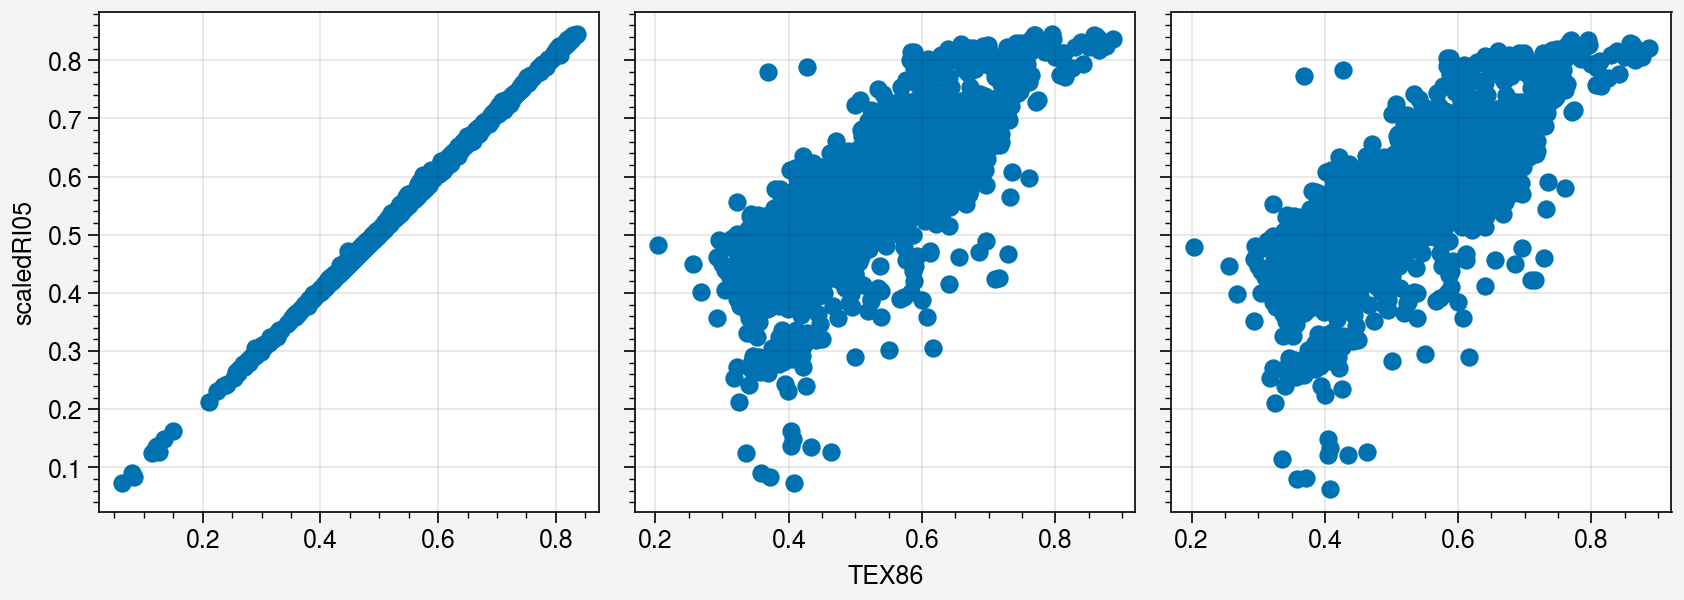

In [10]:
fig, axs = plot.subplots(ncols=3)

ax = axs[0]
plot_x = coretop_df['scaledRI05']
plot_y = coretop_df['scaledRI']
ax.scatter(plot_x, plot_y)

ax = axs[1]
plot_x = coretop_df['TEX86']
plot_y = coretop_df['scaledRI']
ax.scatter(plot_x, plot_y)

ax = axs[2]
plot_x = coretop_df['TEX86']
plot_y = coretop_df['scaledRI05']
ax.scatter(plot_x, plot_y)

## 2.2 Ocean products

### 2.2.1 WOA23 - Temperature

WOA = World Ocean Atlas
Details:
- Temperature - Statistical mean on 1/4° grid for 1991-2020 climate normal
- Unit: Degree Celcius
- Link to download data: https://www.ncei.noaa.gov/thredds-ocean/fileServer/woa23/DATA/temperature/netcdf/decav91C0/0.25/woa23_decav91C0_t00_04.nc

In [11]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).t_an.load()
T_da

<xarray.DataArray 't_an' (depth: 102, lat: 720, lon: 1440)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6605101, -1.66081  , -1.65491  , ..., -1.6598101,
         -1.66031  , -1.66041  ],
        [-1.66861  , -1.66521  , -1.66721  , ..., -1.66961  ,
         -1.6665   , -1.66871  ],
        [-1.44921  , -1.44921  , -1.44921  , ..., -1.44921  ,
         -1.44921  , -1.44921  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

In [12]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_01.nc'),decode_times=False).drop('time')

T_1deg_da = ts.isel(time=0).t_an.load()
T_1deg_da

<xarray.DataArray 't_an' (depth: 102, lat: 180, lon: 360)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6392   , -1.64001  , -1.64101  , ..., -1.63711  ,
         -1.6377   , -1.63831  ],
        [-1.6605101, -1.66081  , -1.66111  , ..., -1.6593   ,
         -1.65961  , -1.6601   ],
        [-1.67591  , -1.67591  , -1.67591  , ..., -1.67591  ,
         -1.67591  , -1.67591  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

In [13]:
### calculate thermocline along depth dimension of T_1deg_da using min T gradient approach (depth with the fastest drop in T)
### calculate using diff method from xarray and divide by the diff of depth
sliced_T_1deg_da = T_1deg_da.sel(depth=slice(0,1100))
gradient = sliced_T_1deg_da.diff('depth')/sliced_T_1deg_da.depth.diff('depth')

### mask NaN values
gradient = abs(gradient.where(~np.isnan(T_1deg_da)))

### fill NaN values with infinity to avoid error in argmin
gradient_filled = gradient.fillna(-np.inf)
maxabs_gradient_idx = gradient_filled.argmax('depth',skipna=True).astype(int)+1

### mask locations where all depth values are NaN
all_nan_mask = np.isnan(sliced_T_1deg_da).all('depth')

### mask maxabs_gradient_idx where all depth values are NaN
maxabs_gradient_idx = maxabs_gradient_idx.where(~all_nan_mask, drop=False)

# Flatten the lat-lon grid for advanced indexing
stacked = sliced_T_1deg_da.stack(grid=["lat", "lon"])

# Ensure maxabs_gradient_idx is an integer, replacing NaN with a valid placeholder index (e.g., 0)
valid_idx = maxabs_gradient_idx.fillna(0).astype(int)

# Use isel to index the depth dimension with the flattened indices
thermoT_depth_values = stacked["depth"].isel(depth=valid_idx.stack(grid=["lat", "lon"]))
thermoT_values = stacked.isel(depth=valid_idx.stack(grid=["lat", "lon"]))
# Mask locations where maxabs_gradient_idx was NaN
nan_mask = maxabs_gradient_idx.isnull()
thermoT_depth_values = thermoT_depth_values.where(~nan_mask.stack(grid=["lat", "lon"]))
thermoT_values = thermoT_values.where(~nan_mask.stack(grid=["lat", "lon"]))
# Unstack to return to the original lat-lon dimensions
thermoT_depth_1deg_da = thermoT_depth_values.unstack("grid")
thermoT_1deg_da = thermoT_values.unstack("grid")


###################################################
masked_T_1deg_da = T_1deg_da.where(T_1deg_da["depth"]<=thermoT_depth_1deg_da)
len_notnull_values_along_depth = np.unique(masked_T_1deg_da.notnull().sum('depth').values)
sel_masked_1deg_da = masked_T_1deg_da
tmp_1deg_da = xr.DataArray(np.zeros_like(sel_masked_1deg_da.isel(depth=0).values),
                      dims=sel_masked_1deg_da.isel(depth=0).dims,
                      coords=sel_masked_1deg_da.isel(depth=0).coords
                      )
tmp_1deg_da
# Loop through the unique counts of non-NaN values along depth
for i in len_notnull_values_along_depth:
    if i == 0:
        continue  # Skip cases where no valid data is available
    # Select grid points where the non-NaN count equals `i`
    mask = sel_masked_1deg_da.notnull().sum('depth') == i
    
    if i == 1:
        # if only one valid depth slice, use the first depth slice
        cal_values = (
            sel_masked_1deg_da.where(sel_masked_1deg_da.notnull().sum('depth') == i)
            .isel(depth=0)
        )
    else:
        # Calculate the integrated values for the valid depth slices
        cal_values = (
            sel_masked_1deg_da.where(sel_masked_1deg_da.notnull().sum('depth') == i)
            .isel(depth=slice(0, i))
            .integrate('depth')
        )
        
        # Update tmp_1deg_da with the calculated values at the same grid points
    tmp_1deg_da = tmp_1deg_da.where(~mask, other=cal_values)
tmp_1deg_da2 = tmp_1deg_da
#### mask locations where there are more than 1 valid depth values
mask_below_SST = sel_masked_1deg_da.notnull().sum('depth') > 1
cal_values = tmp_1deg_da2.where(mask_below_SST)/thermoT_depth_1deg_da.where(mask_below_SST)
# apply mask where all depth values are NaN
all_nan_mask = np.isnan(sel_masked_1deg_da).all('depth')
tmp_1deg_da2 = tmp_1deg_da2.where(~all_nan_mask)

thermocline_depthIntegral_T_1deg_da = tmp_1deg_da2.where(~mask_below_SST, other=cal_values)
thermocline_depthIntegral_T_1deg_da


<xarray.DataArray (lat: 180, lon: 360)>
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [-1.2768773, -1.2799466, -1.2829043, ..., -1.4295026, -1.271273 ,
        -1.2740542],
       [-1.2734717, -1.274759 , -1.2760662, ..., -1.2691069, -1.2707332,
        -1.2721268],
       [-1.2634081, -1.2634081, -1.2634081, ..., -1.2634081, -1.2634081,
        -1.2634081]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
    depth    float32 0.0

### 2.2.2 CMEMS Nitrate

CMEMS = Copernicus Marine Environmental Monitoring Service

- Nitrate - Mole concentration of nitrate in sea water 0.25deg x 0.25deg
- Unit: mmol/m3
- Link to data product website: https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_BGC_001_029/description

- Raw data: monthly climatology hindcasts from 1993-2022 (30 years)
- Processing: The climatology mean field of annual average were generated from 30-year montly climatologies using ncclimo function (https://nco.sourceforge.net/nco.html)

In [14]:
fpath = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/nitrate'
fname = 'woa23_all_n00_01.nc'

woa23_nitrate = xr.open_dataset(os.path.join(fpath,fname),decode_times=False).drop('time')
woa23_nitrate = woa23_nitrate.isel(time=0).n_an.load()
woa23_nitrate

<xarray.DataArray 'n_an' (depth: 102, lat: 180, lon: 360)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [0.5065072 , 0.5077519 , 0.50824255, ..., 0.49354407,
         0.49962154, 0.50394267],
        [0.5509077 , 0.552426  , 0.55362046, ..., 0.53350955,
         0.5418536 , 0.54766   ],
        [0.5734835 , 0.5734835 , 0.5734835 , ..., 0.5734835 ,
         0.5734835 , 0.5734835 ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  moles_of_nitrate_per_unit_mass_in_sea_water
    long_name:      Objectively analyzed mean fields for moles_of_nitrate_per...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          micromoles_per_kilogram

In [15]:
### NEMO nitrate data
fpath = fr'{local_onedrive_path}/Postdoc/Project/TEXAS/netcdf/Copernicus Marine Service/processed-files/Global-Biogeochemistry/climo-monthly/no3'
fname = r'mercatorfreebiorys2v4_global_mean_ANN_199301_202212_climo.nc'

nitrate_CMEMS_ds = xr.open_dataset(os.path.join(fpath,fname))
nitrate_CMEMS_ds = nitrate_CMEMS_ds.isel(time=0).drop('time')
nitrate_CMEMS_ds = nitrate_CMEMS_ds.rename({'latitude':'lat','longitude':'lon'})
nitrate_CMEMS_da = nitrate_CMEMS_ds.no3.load() ### convert mmol/L to umol/L to make it comparable to WOA data
nitrate_CMEMS_da

depth_coord = nitrate_CMEMS_da.depth
depth_coord = depth_coord - depth_coord[0]
nitrate_CMEMS_da = nitrate_CMEMS_da.assign_coords(depth=depth_coord)
nitrate_CMEMS_da

getfattr: /mnt/onedrive/Postdoc/Project/TEXAS/netcdf/Copernicus: No such file or directory
getfattr: Marine: No such file or directory
getfattr: Service/processed-files/Global-Biogeochemistry/climo-monthly/no3/mercatorfreebiorys2v4_global_mean_ANN_199301_202212_climo.nc: No such file or directory


<xarray.DataArray 'no3' (depth: 75, lat: 681, lon: 1440)>
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [5.7781367, 5.779535 , 5.7808266, ..., 5.7733583, 5.775043 ,
         5.7766376],
        [5.720044 , 5.7206492, 5.721291 , ..., 5.718462 , 5.7189493,
         5.719477 ],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
...
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * lon      (lon) float32 -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
  * lat      (lat) float32 -80.0 -79.75 -79.5 -79.25 ... 89.25 89.5 89.75 90.0
  * depth    (depth) float32 0.0 1.05 2.162 ... 5.494e+03 5.698e+03 5.902e+03
Attributes:
    long_name:      Nitrate
    standard_name:  mole_concentration_of_nitrate_in_sea_water
    units:          mmol m-3
    unit_long:      millimoles of Nitrate per cubic meter
    valid_min:      0.0
    valid_max:      59.31268
    cell_methods:   time: mean

In [16]:
### regrid nitrate_CMESM to T_an grid
nitrate_CMEMS_da_regrid_lld = nitrate_CMEMS_da.interp(lat=T_da.lat,lon=T_da.lon,depth=T_da.depth,method='linear')
nitrate_CMEMS_da_regrid_lld 

<xarray.DataArray 'no3' (depth: 102, lat: 720, lon: 1440)>
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [5.7811136, 5.7841377, 5.7870884, ..., 5.771783 , 5.774918 ,
               nan],
        [5.749591 , 5.750575 , 5.751523 , ..., 5.7464533, 5.7475266,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
...
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    long_name:      Nitrate
    standard_name:  mole_concentration_of_nitrate_in_sea_water
    units:          mmol m-3
    unit_long:      millimoles of Nitrate per cubic meter
    valid_min:      0.0
    valid_max:      59.31268
    cell_methods:   time: mean

### 2.2.3 Processed ocean properties --- Rattanasriampaipong et al. 2025

In [17]:
fpath = f'{local_github_path}/data/external/ncfiles'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_prop_ds = xr.open_dataset(os.path.join(fpath,fname))
ocean_prop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

### 2.2.4 Nitrification rate -- Zakem et al. 2022 Biogeosciences

In [18]:
fpath = f'{local_onedrive_path}/Postdoc/Project/TEXAS/netcdf/Zakem2022_Biogeosciences'
subfolder = f'DEFAULT_runNitrifyModel_NatComm_newyields_eqaff_withnitrtemp-20250925T232044Z-1-001/DEFAULT_runNitrifyModel_NatComm_newyields_eqaff_withnitrtemp'
fname = 'ptr_tave.0000720000.nc'
nitrif_ds = xr.open_dataset(os.path.join(fpath,subfolder,fname)).squeeze('T')

X_values = nitrif_ds['X'].values
X_converted = np.where(X_values > 180, X_values - 360, X_values)
nitrif_ds = nitrif_ds.assign_coords(X=X_converted)


# Find where longitude jumps from positive to negative
lon_diff = np.diff(nitrif_ds['X'])
wrap_index = np.where(lon_diff < -180)[0][0] + 1

# Roll the dataset to put negative longitudes first
nitrif_ds = nitrif_ds.roll(X=len(nitrif_ds['X']) - wrap_index, roll_coords=True)

# Verify it's monotonic
print(f"Longitude range: {nitrif_ds['X'].min().values:.1f} to {nitrif_ds['X'].max().values:.1f}")
print(f"Is monotonic: {np.all(np.diff(nitrif_ds['X']) > 0)}")

nitrif_ds = nitrif_ds.rename({'X':'lon','Y':'lat','Z':'depth'})
nitrif_ds['depth'] = -nitrif_ds['depth']
nitrif_ds

Longitude range: -179.5 to 179.5
Is monotonic: True


<xarray.Dataset>
Dimensions:  (lon: 360, lat: 160, depth: 23)
Coordinates:
  * lon      (lon) float64 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 -79.5 -78.5 -77.5 -76.5 -75.5 ... 76.5 77.5 78.5 79.5
  * depth    (depth) float64 5.0 15.0 27.5 45.0 ... 4.45e+03 4.95e+03 5.45e+03
    T        datetime64[ns] 2247-05-26
Data variables: (12/48)
    iter     int32 ...
    DIC      (depth, lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
    NH4      (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    NO2      (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    NO3      (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    PO4      (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ...       ...
    Chl07    (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    Chl08    (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    Chl09    (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    Chl10    (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    Chl11    (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    Chl12    (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes: (12/18)
    MITgcm_version:  checkpoint65g
    build_user:      ezakem
    build_host:      eofe7.cm.cluster
    build_date:      Tue Dec 14 14:23:47 EST 2021
    MITgcm_URL:      http://mitgcm.org
    MITgcm_tag_id:   
    ...              ...
    nSy:             1
    nPx:             8
    nPy:             4
    Nx:              360
    Ny:              160
    Nr:              23

In [19]:
NH4_1deg_da = nitrif_ds['NH4']
NH4_1deg_da

<xarray.DataArray 'NH4' (depth: 23, lat: 160, lon: 360)>
array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.01528865, 0.01606634, 0.01696815, ..., 0.01492257,
         0.01489445, 0.01504667],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.01600114, 0.01682316, 0.01751128, ..., 0.01566478,
         0.01554885, 0.01555807],
...
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]]])
Coordinates:
  * lon      (lon) float64 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 -79.5 -78.5 -77.5 -76.5 -75.5 ... 76.5 77.5 78.5 79.5
  * depth    (depth) float64 5.0 15.0 27.5 45.0 ... 4.45e+03 4.95e+03 5.45e+03
    T        datetime64[ns] 2247-05-26
Attributes:
    units:    mmol N/m^3

In [20]:
NO2_1deg_da = nitrif_ds['NO2']
NO2_1deg_da

<xarray.DataArray 'NO2' (depth: 23, lat: 160, lon: 360)>
array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.07183202, 0.0809185 , 0.08638105, ..., 0.0648703 ,
         0.0626628 , 0.06599369],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.07220627, 0.08172339, 0.08738279, ..., 0.06478784,
         0.06267669, 0.06602308],
...
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]]])
Coordinates:
  * lon      (lon) float64 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 -79.5 -78.5 -77.5 -76.5 -75.5 ... 76.5 77.5 78.5 79.5
  * depth    (depth) float64 5.0 15.0 27.5 45.0 ... 4.45e+03 4.95e+03 5.45e+03
    T        datetime64[ns] 2247-05-26
Attributes:
    units:    mmol N/m^3

In [21]:
masked_NH4_1deg_da = NH4_1deg_da.where(NH4_1deg_da["depth"]<=thermoT_depth_1deg_da)
len_notnull_values_along_depth = np.unique(masked_NH4_1deg_da.notnull().sum('depth').values)
sel_masked_1deg_da = masked_NH4_1deg_da
tmp_1deg_da = xr.DataArray(np.zeros_like(sel_masked_1deg_da.isel(depth=0).values),
                      dims=sel_masked_1deg_da.isel(depth=0).dims,
                      coords=sel_masked_1deg_da.isel(depth=0).coords
                      )
tmp_1deg_da
# Loop through the unique counts of non-NaN values along depth
for i in len_notnull_values_along_depth:
    if i == 0:
        continue  # Skip cases where no valid data is available
    # Select grid points where the non-NaN count equals `i`
    mask = sel_masked_1deg_da.notnull().sum('depth') == i
    
    if i == 1:
        # if only one valid depth slice, use the first depth slice
        cal_values = (
            sel_masked_1deg_da.where(sel_masked_1deg_da.notnull().sum('depth') == i)
            .isel(depth=0)
        )
    else:
        # Calculate the integrated values for the valid depth slices
        cal_values = (
            sel_masked_1deg_da.where(sel_masked_1deg_da.notnull().sum('depth') == i)
            .isel(depth=slice(0, i))
            .integrate('depth')
        )
        
        # Update tmp_1deg_da with the calculated values at the same grid points
    tmp_1deg_da = tmp_1deg_da.where(~mask, other=cal_values)
tmp_1deg_da2 = tmp_1deg_da
#### mask locations where there are more than 1 valid depth values
mask_below_SST = sel_masked_1deg_da.notnull().sum('depth') > 1
cal_values = tmp_1deg_da2.where(mask_below_SST)/thermoT_depth_1deg_da.where(mask_below_SST)
# apply mask where all depth values are NaN
all_nan_mask = np.isnan(sel_masked_1deg_da).all('depth')
tmp_1deg_da2 = tmp_1deg_da2.where(~all_nan_mask)

thermocline_depthIntegral_NH4_1deg_da = tmp_1deg_da2.where(~mask_below_SST, other=cal_values)
thermocline_depthIntegral_NH4_1deg_da


<xarray.DataArray (lat: 160, lon: 360)>
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan, 0.01606634, 0.01145129, ...,        nan,        nan,
               nan],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])
Coordinates:
  * lon      (lon) float64 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 -79.5 -78.5 -77.5 -76.5 -75.5 ... 76.5 77.5 78.5 79.5
    depth    float64 5.0
    T        datetime64[ns] 2247-05-26

In [22]:
masked_NO2_1deg_da = NO2_1deg_da.where(NO2_1deg_da["depth"]<=thermoT_depth_1deg_da)
len_notnull_values_along_depth = np.unique(masked_NO2_1deg_da.notnull().sum('depth').values)
sel_masked_1deg_da = masked_NO2_1deg_da
tmp_1deg_da = xr.DataArray(np.zeros_like(sel_masked_1deg_da.isel(depth=0).values),
                      dims=sel_masked_1deg_da.isel(depth=0).dims,
                      coords=sel_masked_1deg_da.isel(depth=0).coords
                      )
tmp_1deg_da
# Loop through the unique counts of non-NaN values along depth
for i in len_notnull_values_along_depth:
    if i == 0:
        continue  # Skip cases where no valid data is available
    # Select grid points where the non-NaN count equals `i`
    mask = sel_masked_1deg_da.notnull().sum('depth') == i
    
    if i == 1:
        # if only one valid depth slice, use the first depth slice
        cal_values = (
            sel_masked_1deg_da.where(sel_masked_1deg_da.notnull().sum('depth') == i)
            .isel(depth=0)
        )
    else:
        # Calculate the integrated values for the valid depth slices
        cal_values = (
            sel_masked_1deg_da.where(sel_masked_1deg_da.notnull().sum('depth') == i)
            .isel(depth=slice(0, i))
            .integrate('depth')
        )
        
        # Update tmp_1deg_da with the calculated values at the same grid points
    tmp_1deg_da = tmp_1deg_da.where(~mask, other=cal_values)
tmp_1deg_da2 = tmp_1deg_da
#### mask locations where there are more than 1 valid depth values
mask_below_SST = sel_masked_1deg_da.notnull().sum('depth') > 1
cal_values = tmp_1deg_da2.where(mask_below_SST)/thermoT_depth_1deg_da.where(mask_below_SST)
# apply mask where all depth values are NaN
all_nan_mask = np.isnan(sel_masked_1deg_da).all('depth')
tmp_1deg_da2 = tmp_1deg_da2.where(~all_nan_mask)

thermocline_depthIntegral_NO2_1deg_da = tmp_1deg_da2.where(~mask_below_SST, other=cal_values)
thermocline_depthIntegral_NO2_1deg_da


<xarray.DataArray (lat: 160, lon: 360)>
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan, 0.0809185 , 0.05830038, ...,        nan,        nan,
               nan],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])
Coordinates:
  * lon      (lon) float64 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 -79.5 -78.5 -77.5 -76.5 -75.5 ... 76.5 77.5 78.5 79.5
    depth    float64 5.0
    T        datetime64[ns] 2247-05-26

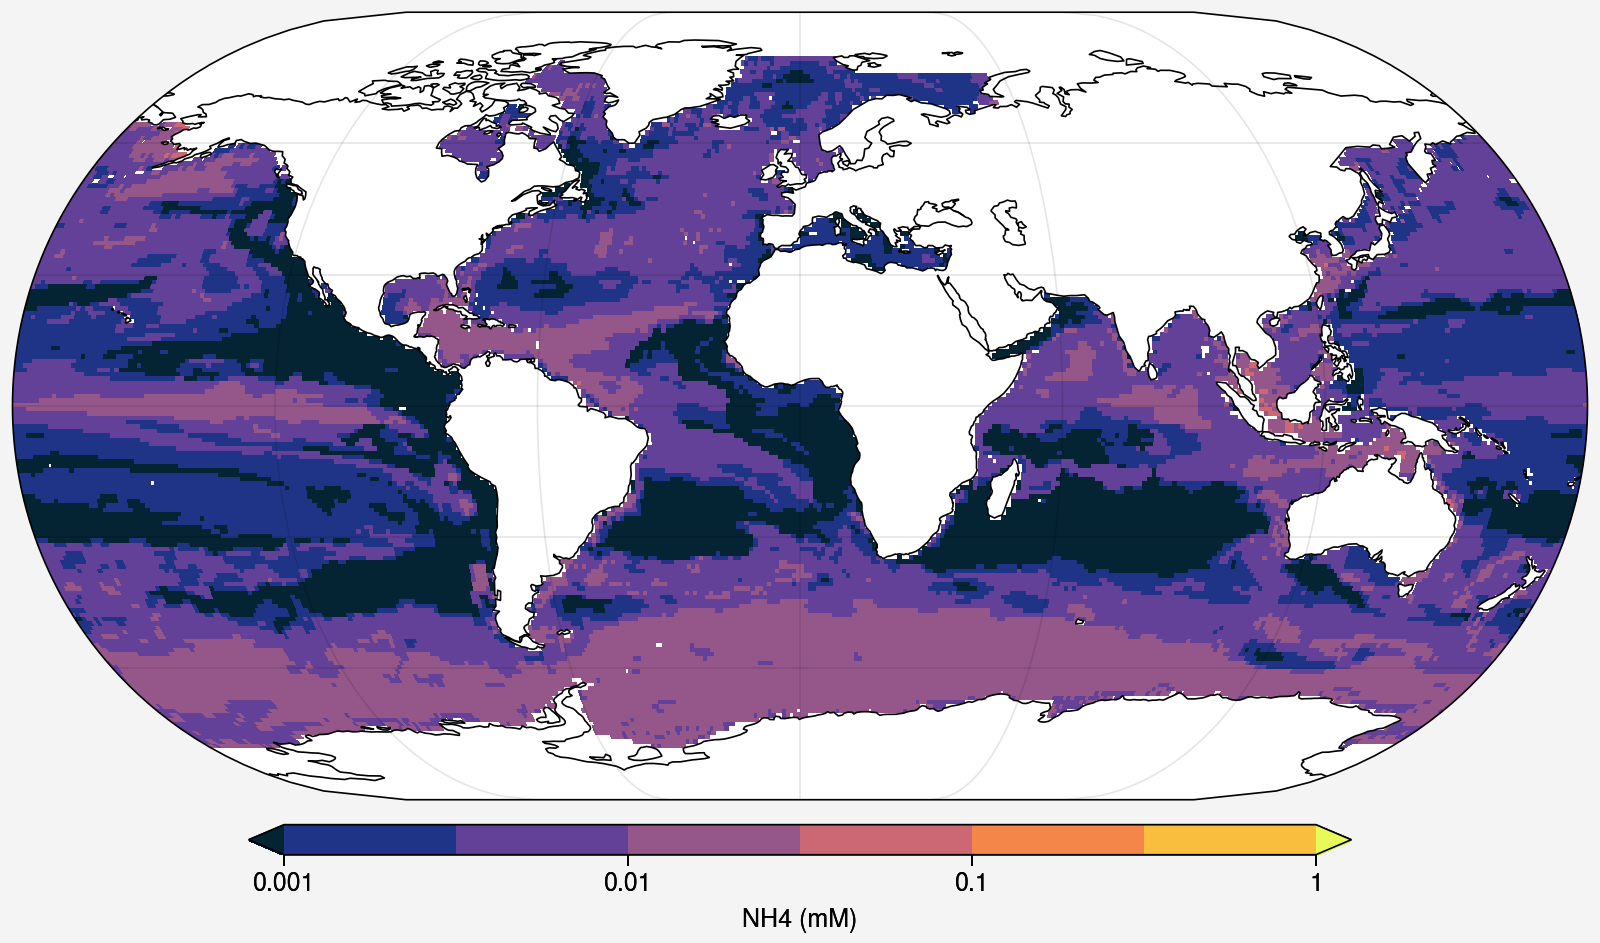

In [23]:

fig, axs = plot.subplots(proj='eck3',width=8,ncols=1)

ax = axs[0]

plot_values = thermocline_depthIntegral_NH4_1deg_da
plot_log10_values = np.log10(plot_values)
plot_lat = thermocline_depthIntegral_NH4_1deg_da['lat']
plot_lon = thermocline_depthIntegral_NH4_1deg_da['lon']
pc = ax.pcolormesh(plot_lon, plot_lat, plot_log10_values, cmap=cmo.thermal, levels=np.arange(-3,0.1,0.5), extend='both')
ax.coastlines()
ax.format(land=True, landcolor='w')
fig.colorbar(pc, loc='b', label='NH4 (mM)', width=0.15, shrink=0.7, ticks=[-3,-2,-1,0], ticklabels=['0.001','0.01','0.1','1'])

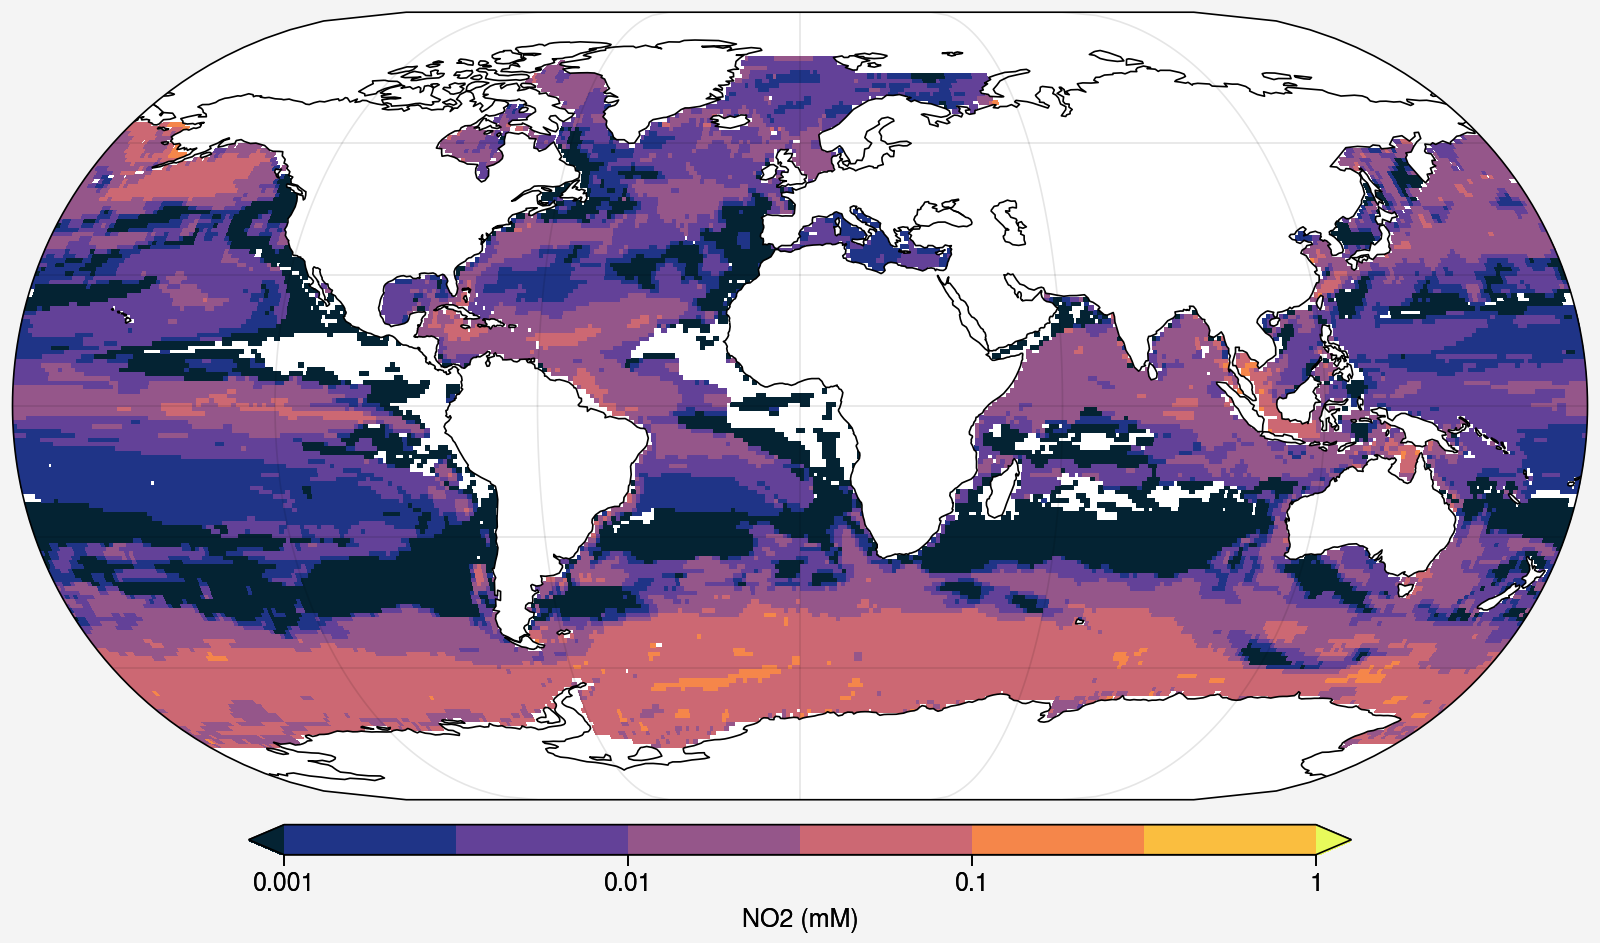

In [24]:

fig, axs = plot.subplots(proj='eck3',width=8,ncols=1)

ax = axs[0]

plot_values = thermocline_depthIntegral_NO2_1deg_da
plot_log10_values = np.log10(plot_values)
plot_lat = thermocline_depthIntegral_NO2_1deg_da['lat']
plot_lon = thermocline_depthIntegral_NO2_1deg_da['lon']
pc = ax.pcolormesh(plot_lon, plot_lat, plot_log10_values, cmap=cmo.thermal, levels=np.arange(-3,0.1,0.5), extend='both')
ax.coastlines()
ax.format(land=True, landcolor='w')
fig.colorbar(pc, loc='b', label='NO2 (mM)', width=0.15, shrink=0.7, ticks=[-3,-2,-1,0], ticklabels=['0.001','0.01','0.1','1'])

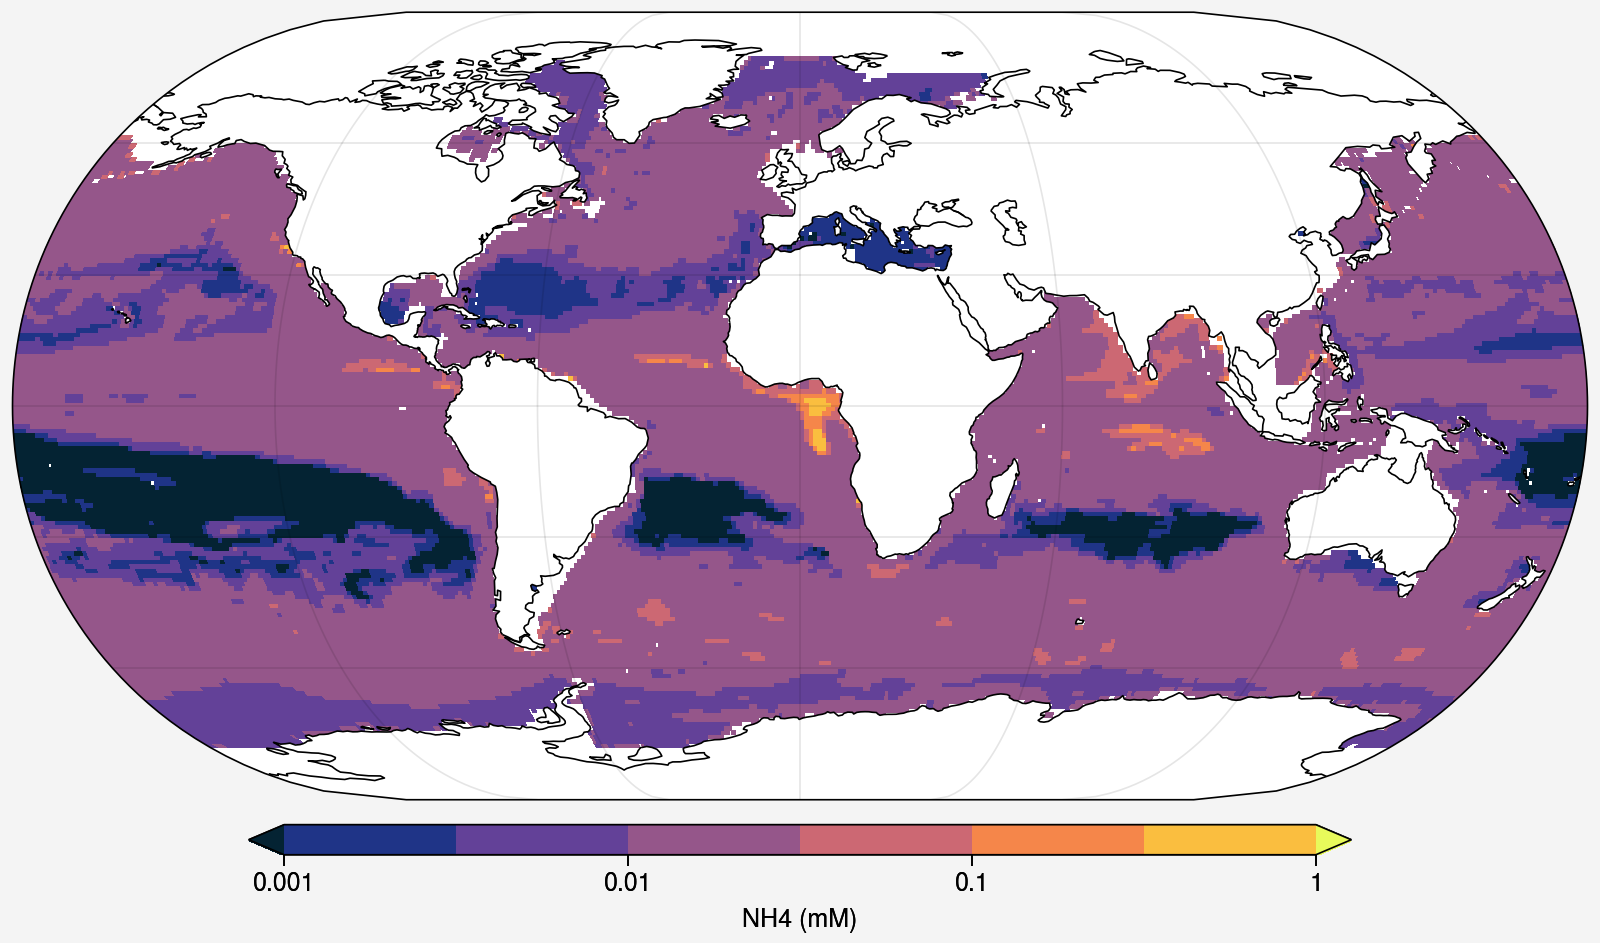

In [25]:

fig, axs = plot.subplots(proj='eck3',width=8,ncols=1)

ax = axs[0]

plot_values = nitrif_ds['NH4'].isel(depth=6)
plot_log10_values = np.log10(plot_values)
plot_lat = nitrif_ds['lat']
plot_lon = nitrif_ds['lon']
pc = ax.pcolormesh(plot_lon, plot_lat, plot_log10_values, cmap=cmo.thermal, levels=np.arange(-3,0.1,0.5), extend='both')
ax.coastlines()
ax.format(land=True, landcolor='w')
fig.colorbar(pc, loc='b', label='NH4 (mM)', width=0.15, shrink=0.7, ticks=[-3,-2,-1,0], ticklabels=['0.001','0.01','0.1','1'])

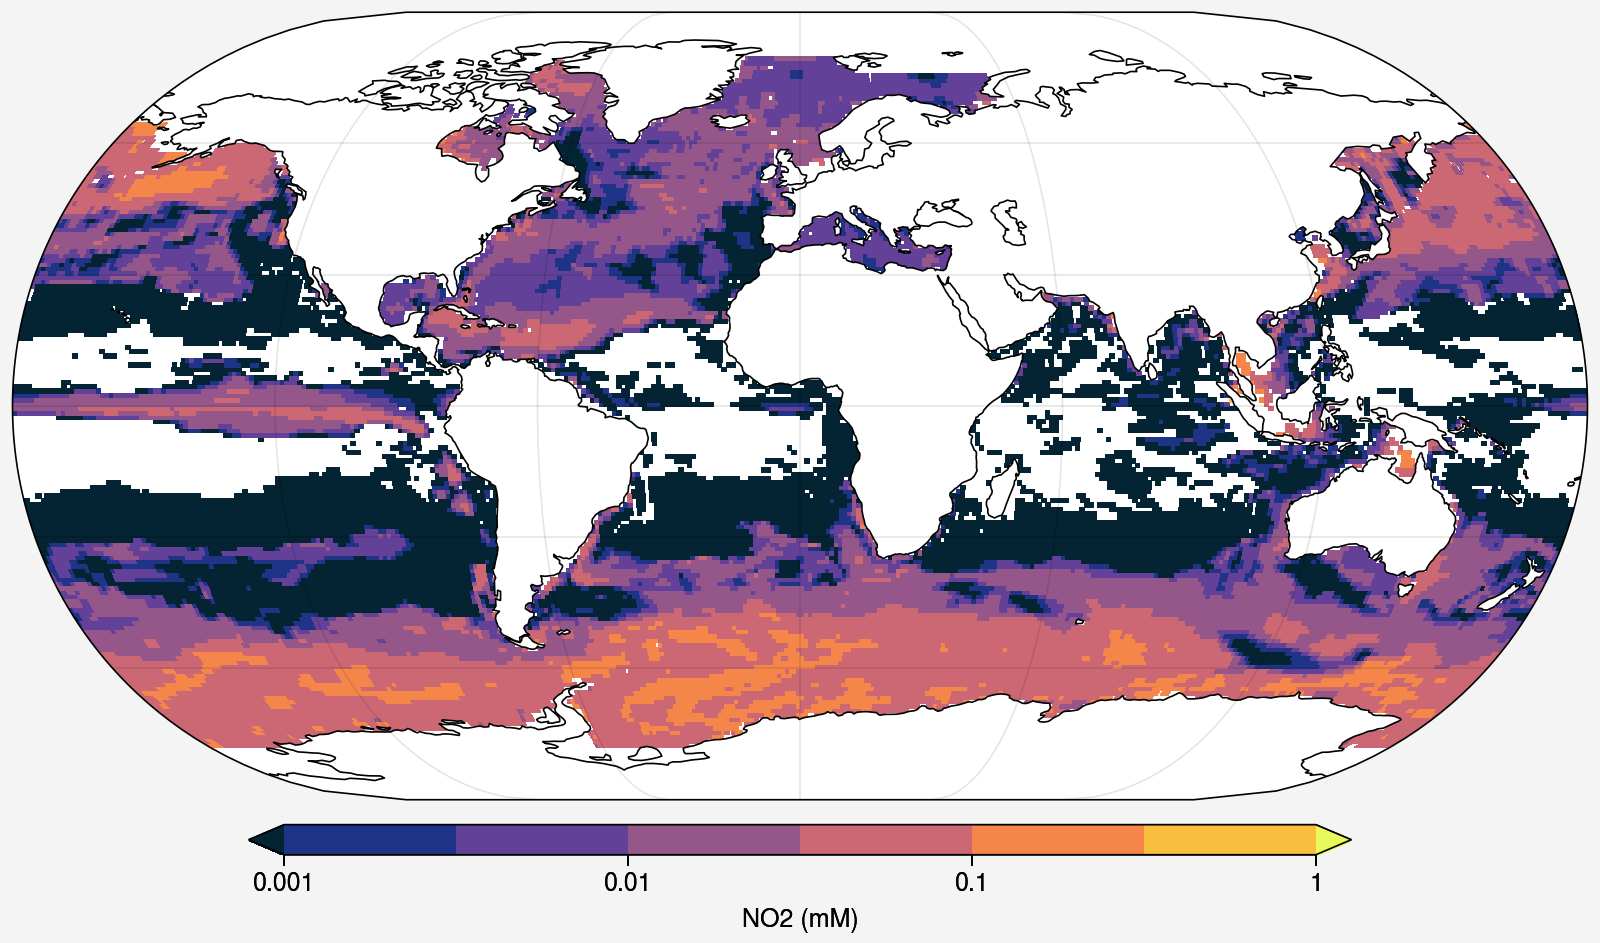

In [26]:

fig, axs = plot.subplots(proj='eck3',width=8,ncols=1)

ax = axs[0]

plot_values = nitrif_ds['NO2'].isel(depth=3)
plot_log10_values = np.log10(plot_values)
plot_lat = nitrif_ds['lat']
plot_lon = nitrif_ds['lon']
pc = ax.pcolormesh(plot_lon, plot_lat, plot_log10_values, cmap=cmo.thermal, levels=np.arange(-3,0.1,0.5), extend='both')
ax.coastlines()
ax.format(land=True, landcolor='w')
fig.colorbar(pc, loc='b', label='NO2 (mM)', width=0.15, shrink=0.7, ticks=[-3,-2,-1,0], ticklabels=['0.001','0.01','0.1','1'])

## 2.3 Culture-Mesocosm Data

In [27]:
### Regression dataset compilation
fpath = fr'{local_github_path}/data/spreadsheets'
fname = r'culture_mesocosm_combined_rev_092325.xlsx'

culture_meso_df = pd.read_excel(os.path.join(fpath, fname))
culture_meso_df

,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_1,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.58,2.79,0.70,0.48,13.00,p__Thermoproteota,...,0.20,0.06,0.13,0.44,0.08,culture,0.42,0.17,0,Culture-temperature_Terrestrial thermophile
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.81,3.73,0.93,0.48,13.00,p__Thermoproteota,...,0.05,0.02,0.04,0.71,0.17,culture,0.12,0.01,0,Culture-temperature_Terrestrial thermophile
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.76,3.73,0.93,0.65,13.00,p__Thermoproteota,...,0.06,0.02,0.03,0.75,0.14,culture,0.11,0.01,0,Culture-temperature_Terrestrial thermophile
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NAOA2_18,Elling et al. (2015) GCA,18,0.86,2.44,0.61,0.40,5.20,p__Thermoproteota,...,0.10,0.17,0.43,0.16,0.02,culture,0.80,0.43,0,Culture-temperature_Marine mesophile
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NAOA2_22,Elling et al. (2015) GCA,22,0.83,2.24,0.56,1.09,5.20,p__Thermoproteota,...,0.11,0.27,0.24,0.20,0.01,culture,0.74,0.45,0,Culture-temperature_Marine mesophile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.45,2.77,0.69,2.63,0.00,mesocosm,...,0.07,0.04,0.01,0.64,0.01,mesocosm,0.16,0.27,0,NaN
173,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.68,2.63,0.66,3.55,0.00,mesocosm,...,0.05,0.06,0.02,0.56,0.04,mesocosm,0.17,0.33,0,NaN
174,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.61,3.24,0.81,2.32,0.00,mesocosm,...,0.05,0.05,0.02,0.75,0.01,mesocosm,0.13,0.14,0,NaN
175,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.81,3.60,0.90,2.40,0.00,mesocosm,...,0.02,0.05,0.02,0.82,0.03,mesocosm,0.11,0.06,0,NaN


## 2.4 Combined dataset --- Coretop, Mesocosm, Culture

In [28]:
coretop_df['lowAbundanceFlag'] = False
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']

## if any of the GDGTs is below 0.001, flag as low abundance
for feature in features:
    coretop_df['lowAbundanceFlag'] = coretop_df['lowAbundanceFlag'] | (coretop_df[feature]<0.001)

coretop_df.loc[coretop_df['lowAbundanceFlag']==True]


coretop_df['inv_fGDGT0'] = 1-coretop_df['fGDGT_0']
culture_meso_df['inv_fGDGT0'] = 1-culture_meso_df['fGDGT_0']

In [29]:
culture_meso_df.columns

Index(['sampleID', 'sampleName', 'Source', 'Temperature', 'TEX86', 'ringIndex',
       'scaledRI', 'gdgt23ratio', 'phyloT_order', 'GTDB_phylum', 'NCBI_phylum',
       'GTDB_class', 'NCBI_class', 'GTDB_order', 'NCBI_order', 'GTDB_family',
       'NCBI_family', 'GTDB_genus', 'NCBI_genus', 'GTDB_species',
       'NCBI_species', 'Strains', 'experiment_setup', 'organism_commonName',
       'organism_broadClass', 'organism_broadClass2', 'organism_broadClass3',
       'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren',
       'fGDGT_cren_prime', 'datatype', 'methaneIndex', 'gdgtZeroOverZeroCren',
       'BIT', 'violin_bins', 'inv_fGDGT0'],
      dtype='object')

In [101]:
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
temp_df1 = coretop_df[['Latitude','Longitude','modernWaterDepth',
                       'thermocline_T_depthIntegral',
                       'TEX86','ringIndex','scaledRI','inv_fGDGT0',
                       'BIT','methaneIndex',
                       'reference_name']+features].copy().rename(columns={'thermocline_T_depthIntegral':'Temperature'})
temp_df1['datatype'] = 'coretop'
temp_df1['Stains'] = 'coretop'
temp_df1['organism_commonName'] = 'coretop'


temp_df2 = culture_meso_df[culture_meso_df['Temperature']<50][
    culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])][
        ['Temperature','TEX86','ringIndex',
         'scaledRI','inv_fGDGT0','BIT','methaneIndex',
         'datatype','Source',
         'Strains','organism_commonName']+features].copy().rename(columns={'Source':'reference_name'})
temp_df2['Latitude'] = np.nan
temp_df2['Longitude'] = np.nan
temp_df2['modernWaterDepth'] = np.nan
combined_df_raw = pd.concat([temp_df1, temp_df2], ignore_index=True)
combined_df_raw['TEXRI_Zhang16'] = -0.77*combined_df_raw['TEX86'] + (3.32*np.power(combined_df_raw['TEX86'],2)) + 1.59
combined_df_raw['deltaRI'] = combined_df_raw['TEXRI_Zhang16'] - combined_df_raw['ringIndex']
combined_df_raw['ZeroOverZeroCren'] = combined_df_raw['fGDGT_0'] / (combined_df_raw['fGDGT_0'] + combined_df_raw['fGDGT_cren'])
combined_df_raw['CrenOverZeroCren'] = combined_df_raw['fGDGT_cren'] / (combined_df_raw['fGDGT_0'] + combined_df_raw['fGDGT_cren'])
combined_df_raw['inv_fGDGT0'] = 1 - combined_df_raw['fGDGT_0']

combined_df_raw['lowAbundanceFlag'] = False
## if any of the GDGTs is below 0.001, flag as low abundance
for feature in features:
    combined_df_raw['lowAbundanceFlag'] = combined_df_raw['lowAbundanceFlag'] | (combined_df_raw[feature]<0.001)
combined_df_raw

,Latitude,Longitude,modernWaterDepth,Temperature,TEX86,ringIndex,scaledRI,inv_fGDGT0,BIT,methaneIndex,...,fGDGT_cren_prime,datatype,Stains,organism_commonName,Strains,TEXRI_Zhang16,deltaRI,ZeroOverZeroCren,CrenOverZeroCren,lowAbundanceFlag
0,31.65,34.07,562.00,21.59,0.66,NaN,NaN,NaN,0.26,-999.00,...,NaN,coretop,coretop,coretop,NaN,2.54,NaN,NaN,NaN,False
1,-1.53,-86.79,2288.00,22.52,0.60,2.34,0.59,0.67,0.03,0.20,...,0.03,coretop,coretop,coretop,NaN,2.33,-0.01,0.40,0.60,False
2,-3.71,-81.12,378.00,22.09,0.57,NaN,NaN,NaN,-999.00,-999.00,...,NaN,coretop,coretop,coretop,NaN,2.23,NaN,NaN,NaN,False
3,-3.75,-81.14,379.00,22.04,0.57,NaN,NaN,NaN,-999.00,-999.00,...,NaN,coretop,coretop,coretop,NaN,2.24,NaN,NaN,NaN,False
4,-3.97,-81.31,1024.00,21.32,0.60,2.57,0.64,0.72,0.03,0.18,...,0.03,coretop,coretop,coretop,NaN,2.32,-0.25,0.33,0.67,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2190,NaN,NaN,NaN,25.00,0.45,2.77,0.69,0.77,0.00,0.16,...,0.01,mesocosm,NaN,Seychelles_mesocosm,mesocosm,1.92,-0.86,0.27,0.73,False
2191,NaN,NaN,NaN,32.00,0.68,2.63,0.66,0.73,0.00,0.17,...,0.04,mesocosm,NaN,Seychelles_mesocosm,mesocosm,2.61,-0.01,0.33,0.67,False
2192,NaN,NaN,NaN,34.00,0.61,3.24,0.81,0.87,0.00,0.13,...,0.01,mesocosm,NaN,Seychelles_mesocosm,mesocosm,2.35,-0.89,0.14,0.86,False
2193,NaN,NaN,NaN,36.00,0.81,3.60,0.90,0.95,0.00,0.11,...,0.03,mesocosm,NaN,Seychelles_mesocosm,mesocosm,3.16,-0.44,0.06,0.94,False


## 2.5 PhanTEX

In [102]:
fpath = fr'{local_github_path}/data/spreadsheets/published_data'
fname = 'PhanSST_v001.csv'

PhanSST_df = pd.read_csv(os.path.join(fpath,fname))
PhanTEX_df = PhanSST_df[PhanSST_df['ProxyType']=='tex'].reset_index(drop=True)
PhanTEX_df

,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,GDGT3,Cren,Crenisomer,BIT,dRI,MI,LeadAuthor,Year,PublicationDOI,DataDOI
0,NaN,A39,NaN,NaN,94.40,NaN,NaN,Germany,eu,52.23,...,NaN,NaN,NaN,NaN,NaN,NaN,Mutterlose,2010,https://doi.org/10.1016/j.epsl.2010.07.043,NaN
1,NaN,A39,NaN,NaN,94.30,NaN,NaN,Germany,eu,52.23,...,NaN,NaN,NaN,NaN,NaN,NaN,Mutterlose,2010,https://doi.org/10.1016/j.epsl.2010.07.043,NaN
2,NaN,A39,NaN,NaN,94.20,NaN,NaN,Germany,eu,52.23,...,NaN,NaN,NaN,NaN,NaN,NaN,Mutterlose,2010,https://doi.org/10.1016/j.epsl.2010.07.043,NaN
3,NaN,A39,NaN,NaN,94.00,NaN,NaN,Germany,eu,52.23,...,NaN,NaN,NaN,NaN,NaN,NaN,Mutterlose,2010,https://doi.org/10.1016/j.epsl.2010.07.043,NaN
4,NaN,A39,NaN,NaN,91.60,NaN,NaN,Germany,eu,52.23,...,NaN,NaN,NaN,NaN,NaN,NaN,Mutterlose,2010,https://doi.org/10.1016/j.epsl.2010.07.043,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14086,NaN,Mid-Waipara River,NaN,NaN,NaN,70.42,NaN,New Zealand,au,-43.06,...,NaN,NaN,NaN,0.06,NaN,NaN,Hollis,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN
14087,NaN,Mid-Waipara River,NaN,NaN,NaN,64.81,NaN,New Zealand,au,-43.06,...,NaN,NaN,NaN,0.07,NaN,NaN,Hollis,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN
14088,NaN,Mid-Waipara River,NaN,NaN,NaN,62.23,NaN,New Zealand,au,-43.06,...,NaN,NaN,NaN,0.06,NaN,NaN,Hollis,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN
14089,NaN,Mid-Waipara River,NaN,NaN,NaN,58.31,NaN,New Zealand,au,-43.06,...,NaN,NaN,NaN,0.07,NaN,NaN,Hollis,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN


# 3. Data screening

## 3.1 Low abundance screening

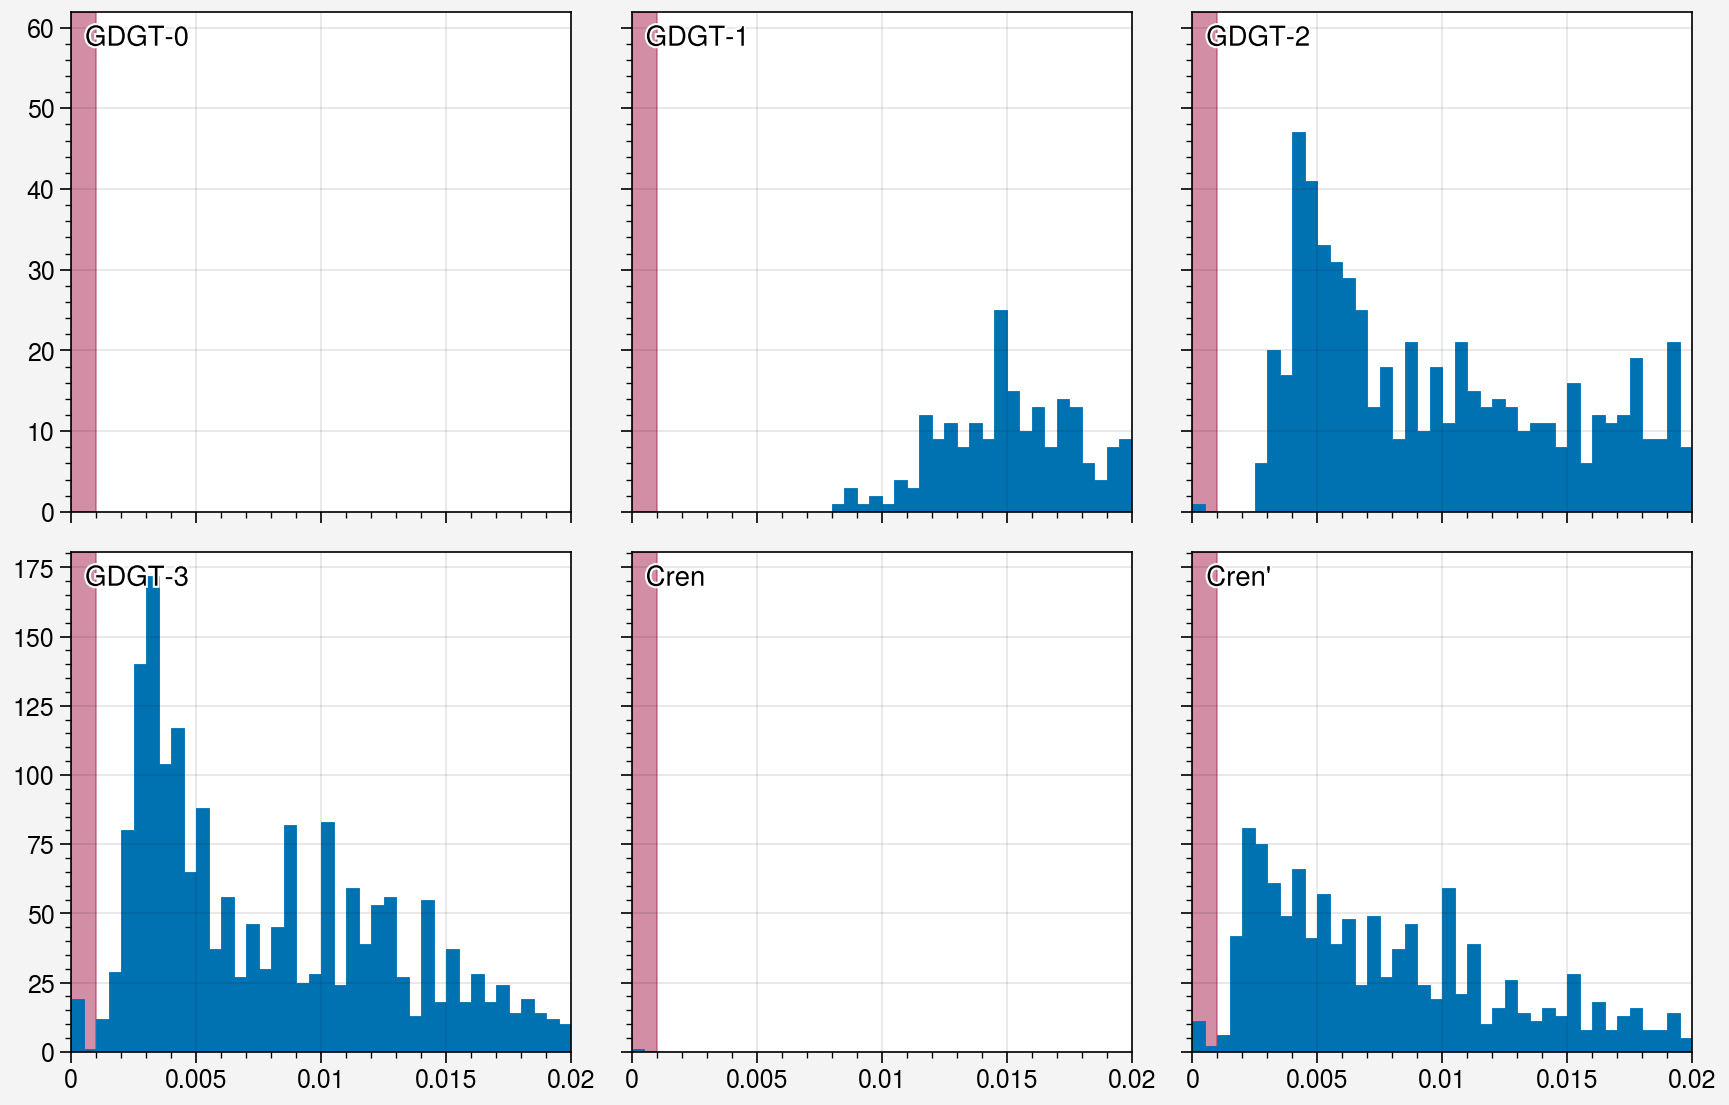

In [103]:
fig, axs = plot.subplots(ncols=3,nrows=2)

features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
feature_labels = ['GDGT-0', 'GDGT-1', 'GDGT-2', 'GDGT-3', 'Cren', "Cren'"]
plot_data = coretop_df.dropna(how='any',subset=features)

for i, (feature, label) in enumerate(zip(features, feature_labels)):
    ax = axs[i]
    ax.format(ultitle=f'{label}',fontweight='bold')
    XX = plot_data[feature].values
    ax.hist(XX,bins=np.arange(XX.min(),XX.max(),0.0005))
    
axs.format(xlim=(0,0.02))
axs.axvspan(0,0.001, color='pink9', alpha=0.5, edgecolor='none', zorder=0)

plt.show()

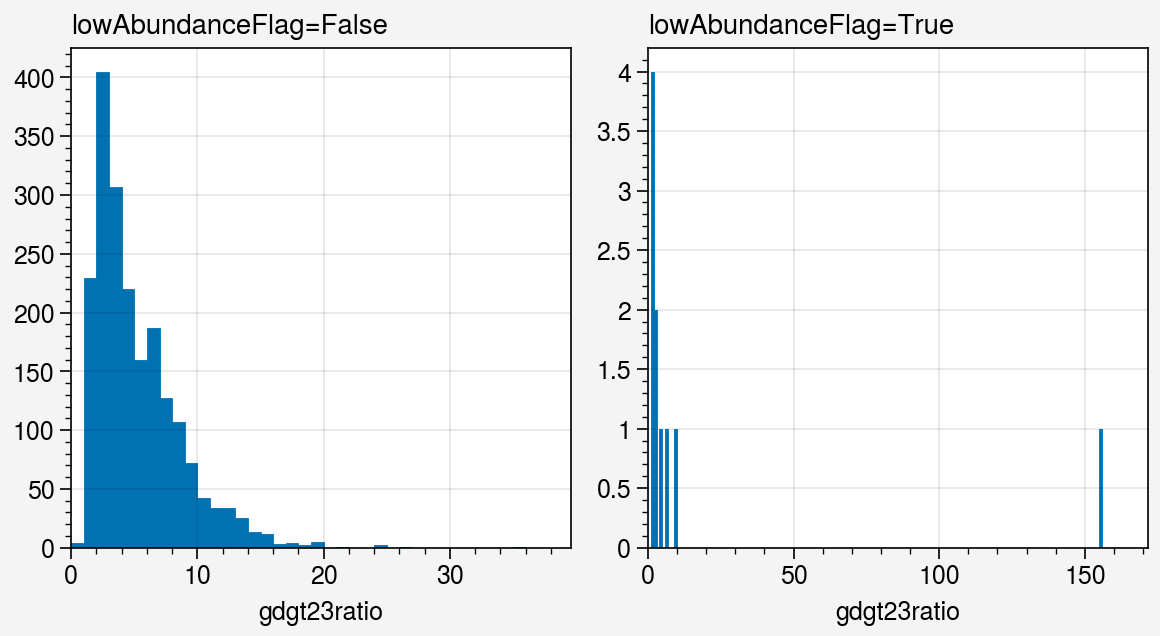

In [104]:
fig, axs = plot.subplots(ncols=2,share=0)
plot_data = coretop_df.replace([np.inf, -np.inf], np.nan).dropna(how='any',subset=['gdgt23ratio'])
grouped = plot_data.groupby('lowAbundanceFlag')
for i, (name, group) in enumerate(grouped):
    axs[i].hist(group['gdgt23ratio'], bins=np.arange(0,161,1))
    axs[i].format(xlim=(0,np.ceil(group['gdgt23ratio'].max())*1.1), ltitle=f'lowAbundanceFlag={name}', fontweight='bold')

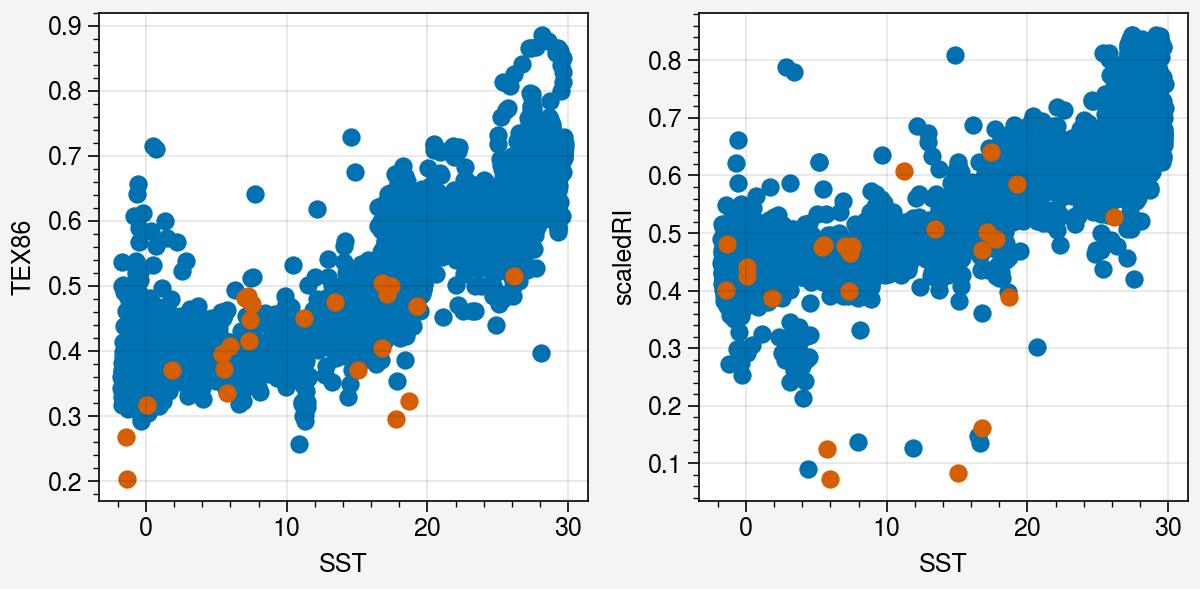

In [105]:
fig, axs = plot.subplots(width=6,ncols=2,share=False)

ax = axs[0]

grouped = coretop_df.groupby('lowAbundanceFlag')
for i, (name, group) in enumerate(grouped):
    axs[0].scatter(group['SST'], group['TEX86'], label=f'Low Abundance: {name}')
    axs[1].scatter(group['SST'], group['scaledRI'], label=f'Low Abundance: {name}')

## 3.2 TEX-RI mahalanobis distance

In [76]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
from numpy.linalg import inv, LinAlgError, pinv

def compute_mahalanobis(
    df: pd.DataFrame,
    features: list[str],
    new_col: str = "mahal_dist",
    use_pinv_if_singular: bool = True,
) -> pd.Series:
    """
    Compute Mahalanobis distances for rows with valid feature values.
    Returns a Series aligned to df (NaN where features are invalid).
    """
    # clean & get valid rows
    X = df[features].replace([np.inf, -np.inf], np.nan)
    valid_idx = X.dropna().index
    X_valid = X.loc[valid_idx].to_numpy(dtype=float)

    # mean and (pseudo)inverse covariance
    mean_vec = np.mean(X_valid, axis=0)
    cov = np.cov(X_valid, rowvar=False)
    try:
        inv_cov = inv(cov)
    except LinAlgError:
        if not use_pinv_if_singular:
            raise
        inv_cov = pinv(cov)

    # distances for valid rows
    dists = [mahalanobis(x, mean_vec, inv_cov) for x in X_valid]

    # aligned output
    out = pd.Series(np.nan, index=df.index, dtype=float)
    out.loc[valid_idx] = dists

    if new_col:
        df[new_col] = out  # optional: attach to df
    return out


def detect_mahalanobis_outliers(
    distances: pd.Series | np.ndarray,
    features: list[str] | int,
    confidence: float = 0.995,
    return_threshold: bool = False,
) -> (pd.Series | tuple[pd.Series, float]):
    """
    Flag outliers using squared Mahalanobis distances vs χ² threshold.
    distances: Series (aligned to df) or 1D array; NaNs are treated as invalid.
    features: list of feature names OR integer degrees of freedom.
    """
    dof = len(features) if not isinstance(features, int) else int(features)
    thr = chi2.ppf(confidence, df=dof)

    dist_series = pd.Series(distances)  # ensures index if ndarray
    flags = pd.Series(np.nan, index=dist_series.index, dtype="float")  # keep NaN where invalid
    valid = dist_series.notna()
    flags.loc[valid] = (dist_series.loc[valid] ** 2) > thr

    # Cast to boolean where valid; keep NaN for invalid
    flags = flags.astype("boolean")

    if return_threshold:
        return flags, np.round(np.sqrt(thr), 4)
    
    return flags

features = ['TEX86','ringIndex']
coretop_df['TEXRI_mahalDist'] = compute_mahalanobis(coretop_df,features=features,new_col='TEXRI_mahalDist')
coretop_df['TEXRI_mahalDist_outliers'] = detect_mahalanobis_outliers(coretop_df['TEXRI_mahalDist'],features=features)

In [77]:
combined_df_raw.columns

Index(['Latitude', 'Longitude', 'modernWaterDepth', 'Temperature', 'TEX86',
       'ringIndex', 'scaledRI', 'inv_fGDGT0', 'BIT', 'methaneIndex',
       'reference_name', 'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3',
       'fGDGT_cren', 'fGDGT_cren_prime', 'datatype', 'Stains',
       'organism_commonName', 'Strains', 'TEXRI_Zhang16', 'deltaRI',
       'ZeroOverZeroCren', 'CrenOverZeroCren', 'lowAbundanceFlag',
       'allGDGTs_mahalDist', 'allGDGTs_mahalDist_outliers',
       'allGDGTs_mahalDist_outliers_manual', 'TEXRI_mahalDist',
       'TEXRI_mahalDist_outliers', 'TEXRI_mahalDist_outliers_manual',
       'TEXfG0_mahalDist', 'TEXfG0_mahalDist_outliers',
       'TEXfG0_mahalDist_outliers_manual', 'TEXfCren_mahalDist',
       'TEXfCren_mahalDist_outliers', 'TEXfCren_mahalDist_outliers_manual',
       'TEXRIfG0Cren_combined_outliers',
       'TEXRIfG0Cren_combined_outliers_manual', 'TEXRIfG0_mahalDist',
       'TEXRIfG0_mahalDist_outliers', 'TEXRIfG0_mahalDist_outliers_manual',
       'T

In [78]:
### mahalanobis distance and outlier detection
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
combined_df_raw['allGDGTs_mahalDist'] = compute_mahalanobis(combined_df_raw,features=features,new_col='allGDGTs_mahalDist')
combined_df_raw['allGDGTs_mahalDist_outliers'], allGDGTs_mahalDist_thr = detect_mahalanobis_outliers(combined_df_raw['allGDGTs_mahalDist'],features=features, return_threshold=True)
print("allGDGTs_mahalDist_thr: ",allGDGTs_mahalDist_thr)
combined_df_raw['allGDGTs_mahalDist_outliers_manual'] = [True if ((combined_df_raw['allGDGTs_mahalDist'].iloc[i]>allGDGTs_mahalDist_thr) & \
                                                                (combined_df_raw['ringIndex'].iloc[i]<=3.5) )
                                                       else False for i in range(len(combined_df_raw))]


features = ['TEX86','ringIndex']
combined_df_raw['TEXRI_mahalDist'] = compute_mahalanobis(combined_df_raw,features=features,new_col='TEXRI_mahalDist')
combined_df_raw['TEXRI_mahalDist_outliers'], TEXRI_mahalDist_thr = detect_mahalanobis_outliers(combined_df_raw['TEXRI_mahalDist'],features=features, return_threshold=True)
print("TEXRI_mahalDist_thr: ",TEXRI_mahalDist_thr)
combined_df_raw['TEXRI_mahalDist_outliers_manual'] = [True if ((combined_df_raw['TEXRI_mahalDist'].iloc[i]>TEXRI_mahalDist_thr) & \
                                                                (combined_df_raw['ringIndex'].iloc[i]<=3.5) )
                                                       else False for i in range(len(combined_df_raw))]

features = ['TEX86','fGDGT_0']
combined_df_raw['TEXfG0_mahalDist'] = compute_mahalanobis(combined_df_raw,features=features,new_col='TEXfG0_mahalDist')
combined_df_raw['TEXfG0_mahalDist_outliers'], TEXfG0_mahalDist_thr = detect_mahalanobis_outliers(combined_df_raw['TEXfG0_mahalDist'],features=features, return_threshold=True)
print("TEXfG0_mahalDist_thr: ",TEXfG0_mahalDist_thr)
combined_df_raw['TEXfG0_mahalDist_outliers_manual'] = [True if ((combined_df_raw['TEXfG0_mahalDist'].iloc[i]>TEXfG0_mahalDist_thr) & \
                                                                (combined_df_raw['ringIndex'].iloc[i]<=3.5) )
                                                       else False for i in range(len(combined_df_raw))]

features = ['TEX86','fGDGT_cren']
combined_df_raw['TEXfCren_mahalDist'] = compute_mahalanobis(combined_df_raw,features=features,new_col='TEXfCren_mahalDist')
combined_df_raw['TEXfCren_mahalDist_outliers'], TEXfCren_mahalDist_thr = detect_mahalanobis_outliers(combined_df_raw['TEXfCren_mahalDist'],features=features, return_threshold=True)
print("TEXfCren_mahalDist_thr: ",TEXfCren_mahalDist_thr)
combined_df_raw['TEXfCren_mahalDist_outliers_manual'] = [True if ((combined_df_raw['TEXfCren_mahalDist'].iloc[i]>TEXfCren_mahalDist_thr) & \
                                                                (combined_df_raw['ringIndex'].iloc[i]<=3.5) )
                                                       else False for i in range(len(combined_df_raw))]

features = ['fGDGT_0','fGDGT_cren']
combined_df_raw['fG0Cren_mahalDist'] = compute_mahalanobis(combined_df_raw,features=features,new_col='fG0Cren_mahalDist')
combined_df_raw['fG0Cren_mahalDist_outliers'], fG0Cren_mahalDist_thr = detect_mahalanobis_outliers(combined_df_raw['fG0Cren_mahalDist'],features=features, return_threshold=True)
print("fG0Cren_mahalDist_thr: ",fG0Cren_mahalDist_thr)
combined_df_raw['fG0Cren_mahalDist_outliers_manual'] = [True if ((combined_df_raw['fG0Cren_mahalDist'].iloc[i]>fG0Cren_mahalDist_thr) & \
                                                                (combined_df_raw['ringIndex'].iloc[i]<=3.5) )
                                                       else False for i in range(len(combined_df_raw))]

### combined outliers
combined_df_raw['TEXRIfG0Cren_combined_outliers'] = combined_df_raw[['TEXRI_mahalDist_outliers',
                                                                     'TEXfG0_mahalDist_outliers',
                                                                     'TEXfCren_mahalDist_outliers']].any(axis=1)
combined_df_raw['TEXRIfG0Cren_combined_outliers_manual'] = combined_df_raw[['TEXRI_mahalDist_outliers_manual',
                                                                            'TEXfG0_mahalDist_outliers_manual',
                                                                            'TEXfCren_mahalDist_outliers_manual']].any(axis=1)

combined_df_raw['TEXRIfG0Cren_fG0Cren_combined_outliers'] = combined_df_raw[['TEXRIfG0Cren_combined_outliers',
                                                                             'fG0Cren_mahalDist_outliers']].any(axis=1)
combined_df_raw['TEXRIfG0Cren_fG0Cren_combined_outliers_manual'] = combined_df_raw[['TEXRIfG0Cren_combined_outliers_manual',
                                                                                    'fG0Cren_mahalDist_outliers_manual']].any(axis=1)

### mahalanobis distance and outlier detection
features = ['TEX86','ringIndex','fGDGT_0']
combined_df_raw['TEXRIfG0_mahalDist'] = compute_mahalanobis(combined_df_raw,features=features,new_col='TEXRIfG0_mahalDist')
combined_df_raw['TEXRIfG0_mahalDist_outliers'], TEXRIfG0_mahalDist_thr = detect_mahalanobis_outliers(combined_df_raw['TEXRIfG0_mahalDist'],features=features, return_threshold=True)
print("TEXRIfG0_mahalDist_thr: ",TEXRIfG0_mahalDist_thr)
combined_df_raw['TEXRIfG0_mahalDist_outliers_manual'] = [True if ((combined_df_raw['TEXRIfG0_mahalDist'].iloc[i]>TEXRIfG0_mahalDist_thr) & \
                                                                (combined_df_raw['ringIndex'].iloc[i]<=3.5) )
                                                       else False for i in range(len(combined_df_raw))]
### mahalanobis distance and outlier detection
features = ['TEX86','ringIndex','fGDGT_0','fGDGT_cren']
combined_df_raw['TEXRIfG0Cren_mahalDist'] = compute_mahalanobis(combined_df_raw,features=features,new_col='TEXRIfG0Cren_mahalDist')
combined_df_raw['TEXRIfG0Cren_mahalDist_outliers'], TEXRIfG0Cren_mahalDist_thr = detect_mahalanobis_outliers(combined_df_raw['TEXRIfG0Cren_mahalDist'],features=features, return_threshold=True)
print("TEXRIfG0Cren_mahalDist_thr: ",TEXRIfG0Cren_mahalDist_thr)
combined_df_raw['TEXRIfG0Cren_mahalDist_outliers_manual'] = [True if ((combined_df_raw['TEXRIfG0Cren_mahalDist'].iloc[i]>TEXRIfG0Cren_mahalDist_thr) & \
                                                                (combined_df_raw['ringIndex'].iloc[i]<=3.5) )
                                                       else False for i in range(len(combined_df_raw))]


allGDGTs_mahalDist_thr:  4.3067
TEXRI_mahalDist_thr:  3.2552
TEXfG0_mahalDist_thr:  3.2552
TEXfCren_mahalDist_thr:  3.2552
fG0Cren_mahalDist_thr:  3.2552
TEXRIfG0_mahalDist_thr:  3.583
TEXRIfG0Cren_mahalDist_thr:  3.8549


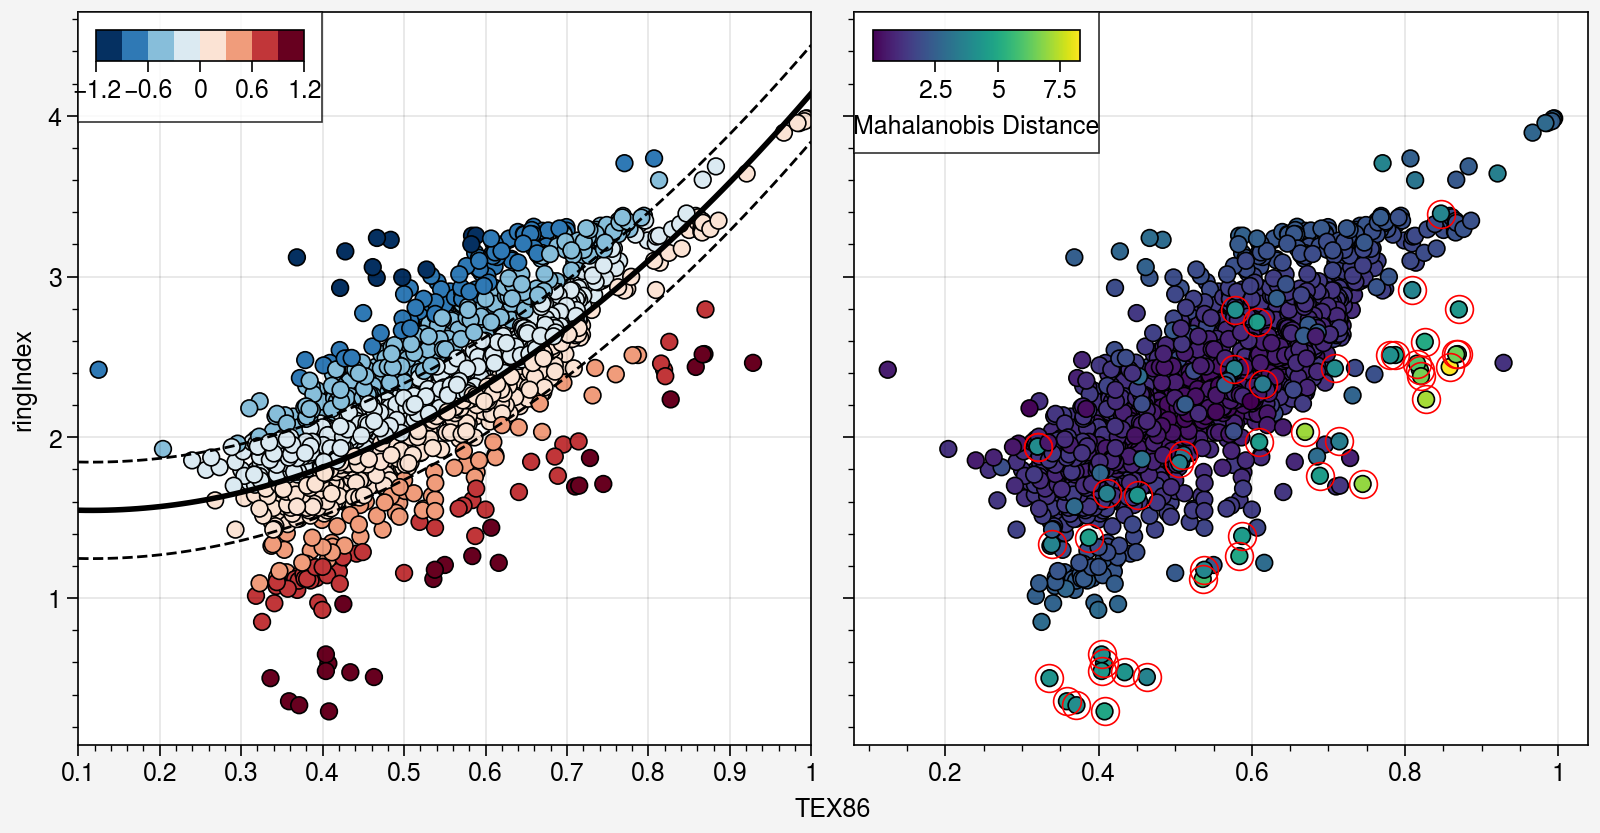

In [79]:
fig, axs = plot.subplots(width=8 , ncols=2)

ax = axs[0,0]
plot_x = combined_df_raw['TEX86']
plot_y = combined_df_raw['ringIndex']
plot_c = combined_df_raw['deltaRI']
m = ax.scatter(plot_x, plot_y, c=plot_c, levels=np.arange(-1.2,1.3,0.3), zorder=1, mec='k')
ax.colorbar(m, loc='ul')
### plot TEX-RI trend from Zhang et al., 2016
tex86_vals = np.linspace(0.1,1,100)
ri_vals = -0.77*tex86_vals + (3.32*np.power(tex86_vals,2)) + 1.59
ax.plot(tex86_vals, ri_vals, color='k', lw=2, label='Zhang et al., 2016', zorder=2)
### plot +/- 0.3 RI deviation lines
ax.plot(tex86_vals, ri_vals+0.3, color='k', lw=1, ls='--', label='+/- 0.3 RI deviation', zorder=2)
ax.plot(tex86_vals, ri_vals-0.3, color='k', lw=1, ls='--', zorder=2)

ax = axs[0,1]
plot_x = combined_df_raw['TEX86']
plot_y = combined_df_raw['ringIndex']
plot_c = combined_df_raw['fG0Cren_mahalDist']
m = ax.scatter(plot_x, plot_y, c=plot_c, cmap='viridis', zorder=1, mec='k')
ax.colorbar(m, loc='ul', label='Mahalanobis Distance')
### plot outliers
outlier_mask = combined_df_raw['fG0Cren_mahalDist_outliers_manual']==True
ax.scatter(plot_x[outlier_mask], plot_y[outlier_mask], facecolors='none', edgecolors='r', s=100, label='Outliers', zorder=2)

(<matplotlib.collections.PathCollection at 0x7fe7f270f700>,
 <matplotlib.collections.PathCollection at 0x7fe7f3737b80>)

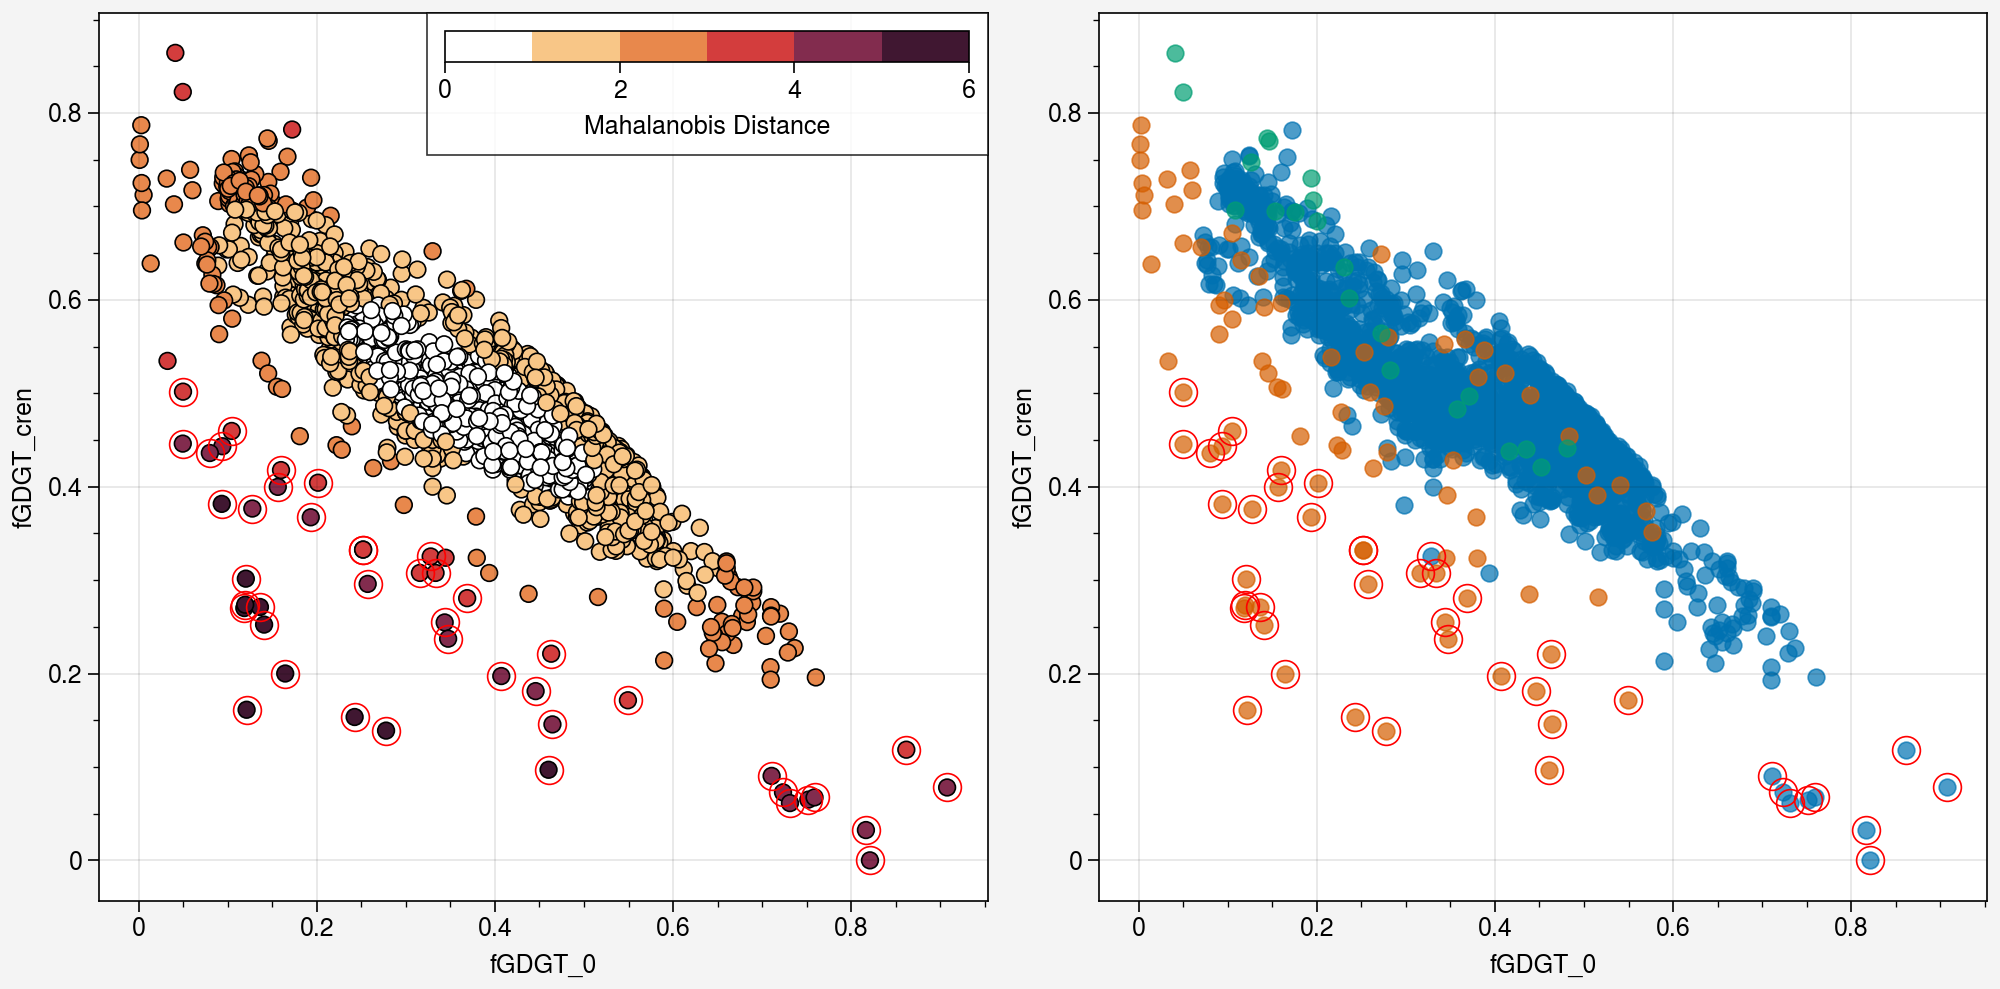

In [80]:
fig, axs = plot.subplots(width=10 , ncols=2, share=0)

ax = axs[0,0]
plot_x = combined_df_raw['fGDGT_0']
plot_y = combined_df_raw['fGDGT_cren']
plot_c = combined_df_raw['fG0Cren_mahalDist']
m = ax.scatter(plot_x, plot_y, mec='k',
               c=plot_c, levels=np.arange(0,7,1))
ax.colorbar(m, loc='ur', label='Mahalanobis Distance',shrink=20)

grouped = combined_df_raw.groupby('datatype')
for name, group in grouped:
    axs[0,1].scatter(group['fGDGT_0'], group['fGDGT_cren'], label=name, alpha=0.7)
### plot outliers
outlier_mask = combined_df_raw['fG0Cren_mahalDist_outliers_manual']==True
axs[0,:].scatter(plot_x[outlier_mask], plot_y[outlier_mask], facecolors='none', edgecolors='r', s=100, label='Outliers', zorder=2)


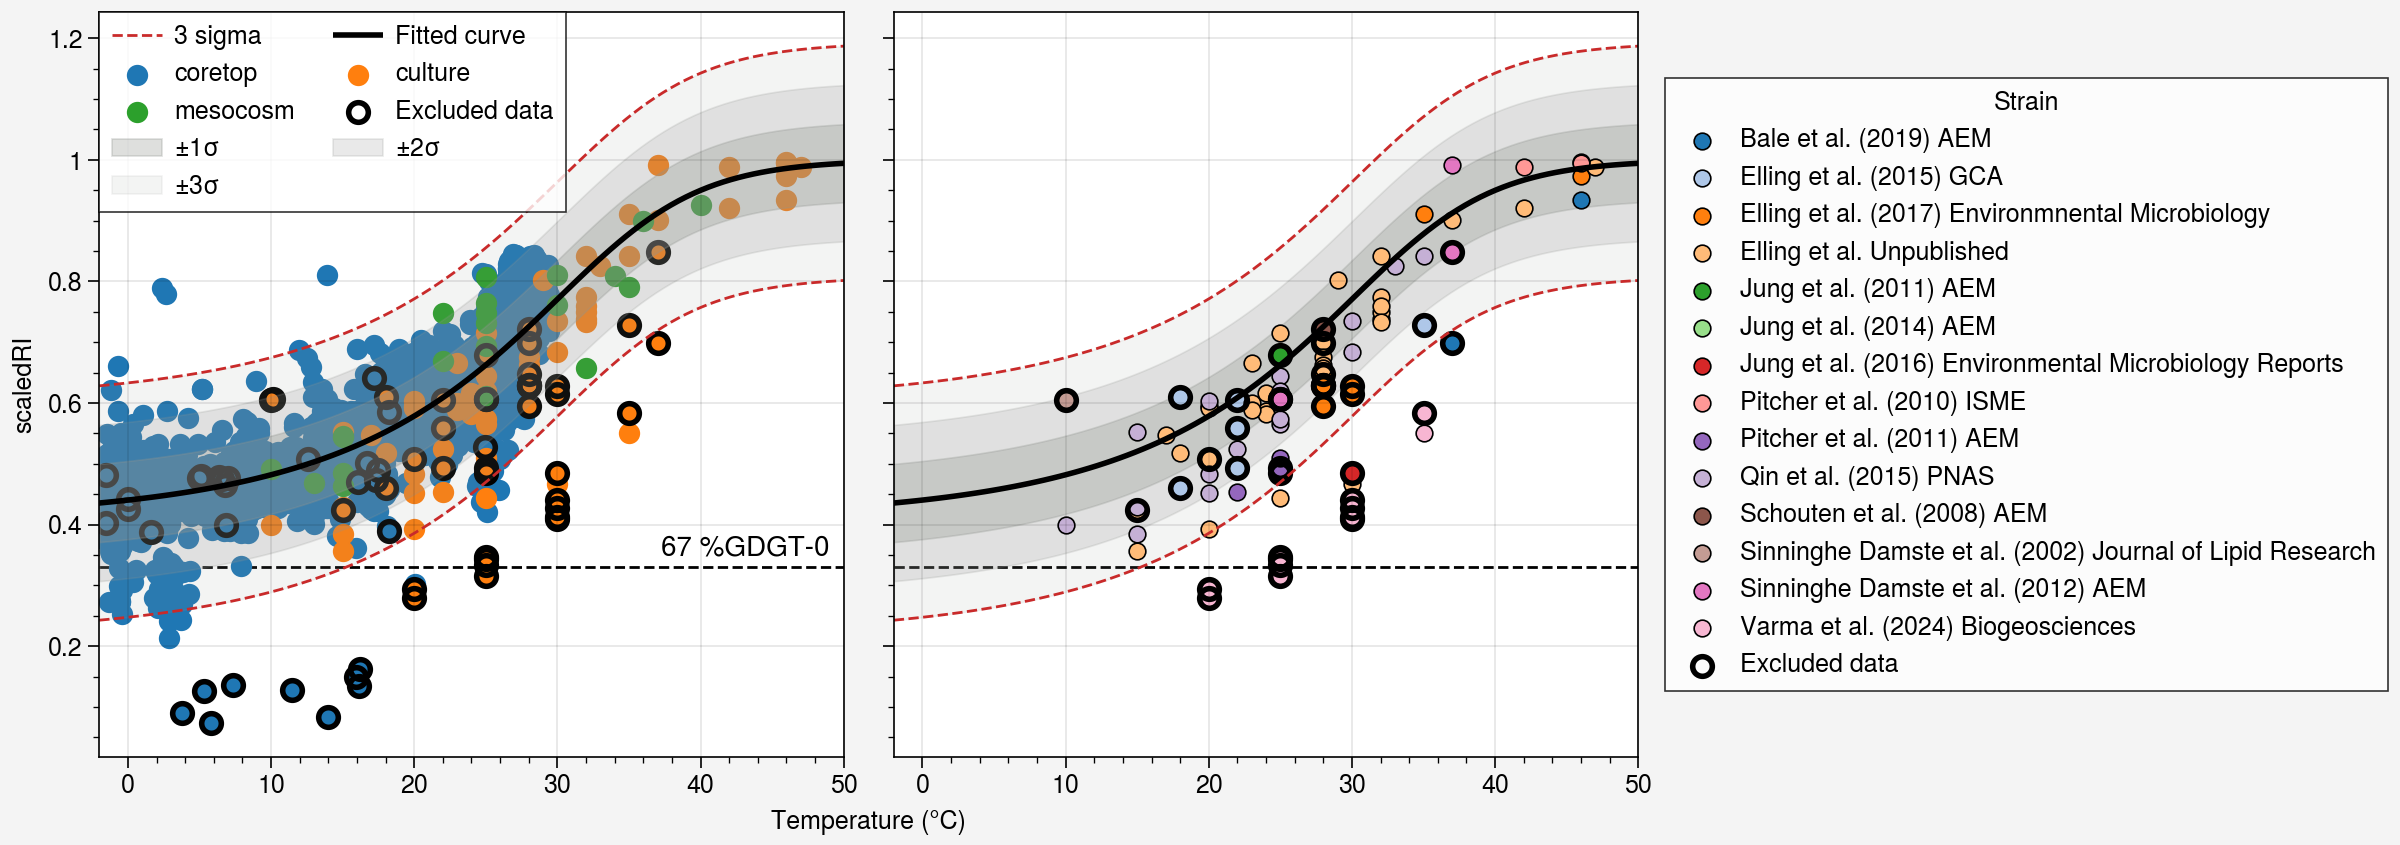

In [81]:
from scipy.optimize import curve_fit
from scipy.stats import t
import numpy as np

sel_yparam = 'scaledRI'
outlier_colname = 'fG0Cren_mahalDist_outliers_manual'
fig, axs = plot.subplots(width=12,ncols=2)
ax = axs[0]

# Plot raw data
grouped = combined_df_raw.groupby('datatype')
for name, group in grouped:
    ax.scatter(group['Temperature'], group[sel_yparam], 
               label=name, s=50, cycle='tab10')


# Fit the model
model = generalized_logistic_model_fixed_upper



nonnan_idx = ~np.isnan(combined_df_raw[sel_yparam].values) & \
             ~np.isnan(combined_df_raw['Temperature'].values)
qc_idx = nonnan_idx \
    & (combined_df_raw['lowAbundanceFlag']==False) \
    & (combined_df_raw[outlier_colname]==False) 
            
nonqc_nonnan_idx = nonnan_idx & ((combined_df_raw[outlier_colname]==True)
                                 | (combined_df_raw['lowAbundanceFlag']==True))

ax.scatter(combined_df_raw['Temperature'][nonqc_nonnan_idx], 
           combined_df_raw[sel_yparam][nonqc_nonnan_idx], 
           facecolors='none', mec='k', lw=2, s=50, label='Excluded data')
            

xdata = combined_df_raw['Temperature'][qc_idx].values
ydata = combined_df_raw[sel_yparam][qc_idx].values

popt, pcov = curve_fit(model, xdata, ydata, 
                       p0=[20, 0.1, 0.2, 1, 1], 
                       bounds=([0, 0, 0, 0.1, 0], [50, 0.5, 5, 5, 5]))

# Calculate residuals and standard error
y_pred = model(xdata, *popt)
residuals = ydata - y_pred
n = len(ydata)
p = len(popt)  # number of parameters
dof = n - p  # degrees of freedom
s_res = np.sqrt(np.sum(residuals**2) / dof)  # residual standard error

# Generate fitted curve
x_fit = np.linspace(-2, 50, 100)
y_fit = model(x_fit, *popt)


## calculate 3 sigmas from the trendline fit
sigma_1 = 1 * s_res
sigma_2 = 2 * s_res
sigma_3 = 3 * s_res

axs.plot(x_fit, y_fit + sigma_3, color='red9', lw=1, ls='--', label='3 sigma')
axs.plot(x_fit, y_fit - sigma_3, color='red9', lw=1, ls='--', label='')


# Plot fitted curve and confidence intervals
axs.plot(x_fit, y_fit, color='k', lw=2, label='Fitted curve')
axs.fill_between(x_fit, y_fit - sigma_1, y_fit + sigma_1, 
                alpha=0.3, color='gray', label=r'$\pm 1 \sigma$')
axs.fill_between(x_fit, y_fit - sigma_2, y_fit + sigma_2, 
                alpha=0.2, color='gray', label=r'$\pm 2 \sigma$')
axs.fill_between(x_fit, y_fit - sigma_3, y_fit + sigma_3, 
                alpha=0.1, color='gray', label=r'$\pm 3 \sigma$')

axs[0].legend(loc='ul',ncols=2)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel(sel_yparam)

axs.axhline((1-0.67), color='k', lw=1, ls='--',zorder=0)
axs[0].text(50-1, (1-0.67)+0.02, '67 %GDGT-0', fontsize=10, color='k', ha='right')


### plot only culture data by strains
plot_data = combined_df_raw[combined_df_raw['datatype']=='culture'].copy()

grouped = plot_data.groupby('reference_name')
ax = axs[1]
for name, group in grouped:
    plot_x = group['Temperature']
    plot_y = group[sel_yparam]
    ax.scatter(plot_x, plot_y, label=name, m='o', mec='k', cycle='tab20')
    
ax.scatter(combined_df_raw['Temperature'][nonqc_nonnan_idx][combined_df_raw['datatype']=='culture'], 
           combined_df_raw[sel_yparam][nonqc_nonnan_idx][combined_df_raw['datatype']=='culture'], 
           facecolors='none', mec='k', lw=2, s=50, label='Excluded data')
    
h, l = ax.get_legend_handles_labels()
ax.legend(h[5:], l[5:], title='Strain', loc='r',ncols=1)

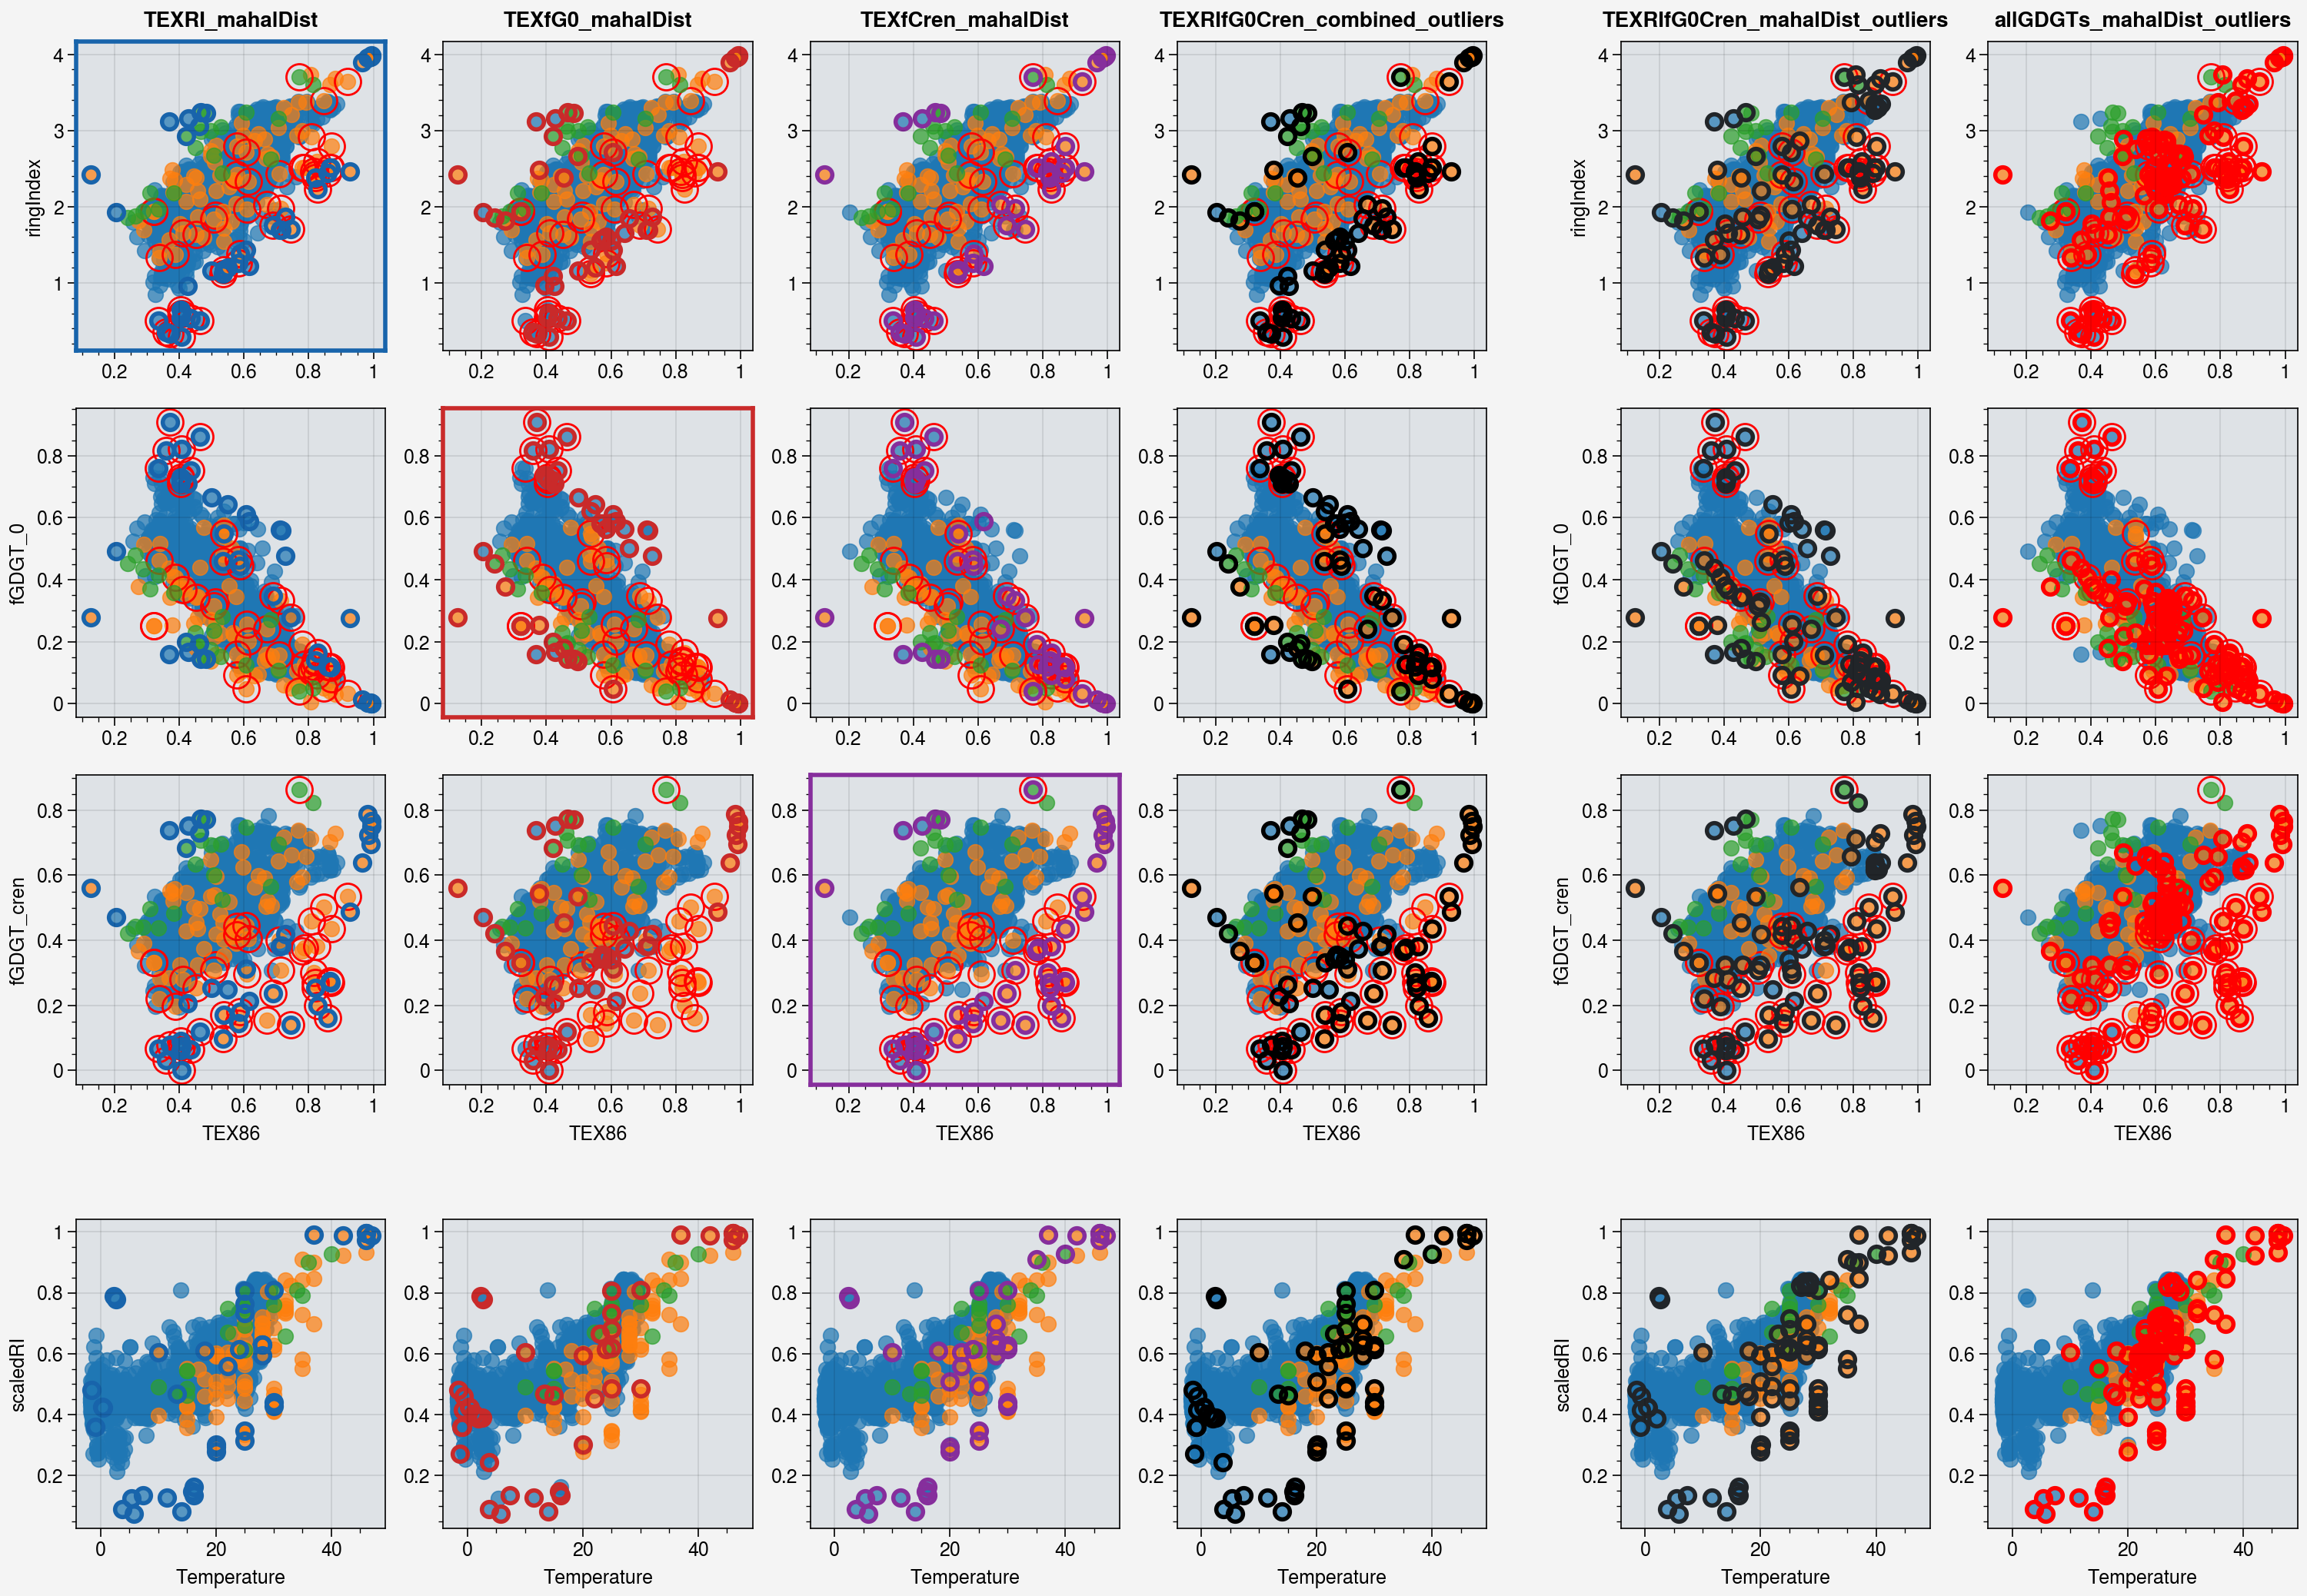

In [82]:
outlier_extension = ''
outlier_data_TEXfG0 = combined_df_raw[combined_df_raw['TEXfG0_mahalDist_outliers'+outlier_extension]==True]
outlier_data_TEXRI = combined_df_raw[combined_df_raw['TEXRI_mahalDist_outliers'+outlier_extension]==True]
outlier_data_TEXfCren = combined_df_raw[combined_df_raw['TEXfCren_mahalDist_outliers'+outlier_extension]==True]
outlier_data_combined_TEXRIfG0Cren = combined_df_raw[(
    (combined_df_raw['TEXRI_mahalDist_outliers'+outlier_extension]==True) |
    (combined_df_raw['TEXfG0_mahalDist_outliers'+outlier_extension]==True) |
    (combined_df_raw['TEXfCren_mahalDist_outliers'+outlier_extension]==True)
    )]  
outlier_data_TEXRIfG0Cren = combined_df_raw[combined_df_raw['TEXRIfG0Cren_mahalDist_outliers'+outlier_extension]==True]
outlier_data_allGDGTs = combined_df_raw[combined_df_raw['allGDGTs_mahalDist_outliers'+outlier_extension]==True]



fig, axs = plot.subplots(width=15, nrows=4, ncols=6, share=0,
                         wspace=[3,3,3,7,3],
                         hspace=[3,3,7])

y_params = ['ringIndex','fGDGT_0','fGDGT_cren']
outlier_colnames = [
    'TEXRI_mahalDist_outliers'+outlier_extension,
    'TEXfG0_mahalDist_outliers'+outlier_extension,
    'TEXfCren_mahalDist_outliers'+outlier_extension,
    'TEXRIfG0Cren_combined_outliers'+outlier_extension,
    'TEXRIfG0Cren_mahalDist_outliers'+outlier_extension,
    'allGDGTs_mahalDist_outliers'+outlier_extension
]
outlier_lists = [
    outlier_data_TEXRI,
    outlier_data_TEXfG0,
    outlier_data_TEXfCren,
    outlier_data_combined_TEXRIfG0Cren,
    outlier_data_TEXRIfG0Cren,
    outlier_data_allGDGTs
]
grouped = combined_df_raw.groupby('datatype')
for name, group in grouped:
    for i, y_param in enumerate(y_params):
        ax = axs[i,:]
        ax.scatter(group['TEX86'], group[y_param], label=name, s=50, cycle='tab10',alpha=0.7)
        
        ## plot fG0Crea outliers
        fG0Cren_mahal_outlier_idx = group['fG0Cren_mahalDist_outliers'+outlier_extension]==True
        ax.scatter(group['TEX86'][fG0Cren_mahal_outlier_idx], 
                   group[y_param][fG0Cren_mahal_outlier_idx], facecolors='none', 
                   mec='r', lw=1, s=150, label='fG0Cren Mahalanobis outliers')
        
    ################# T-scaledRI plots #####################
    axs[-1,:].scatter(group['Temperature'], group['scaledRI'], label=name, s=50, cycle='tab10',alpha=0.7)
        
for j, outlier_data in enumerate(outlier_lists):
    for i, y_param in enumerate(y_params):
        ax = axs[i,j]
        ax.scatter(outlier_data['TEX86'], outlier_data[y_param], facecolors='none', 
                   mec=['blue9','red9','grape9','k','gray9','r'][j], lw=2, s=50, label='Mahalanobis outliers')
        
    axs[-1,j].scatter(outlier_data['Temperature'], outlier_data['scaledRI'], facecolors='none', 
                   mec=['blue9','red9','grape9','k','gray9','r'][j], lw=2, s=50, label='Mahalanobis outliers')

axs.format(
    collabels=['TEXRI_mahalDist','TEXfG0_mahalDist','TEXfCren_mahalDist',
                'TEXRIfG0Cren_combined_outliers','TEXRIfG0Cren_mahalDist_outliers',
                'allGDGTs_mahalDist_outliers'],
)

axs[:,1:-2].format(ylabel='')
axs[:,-1].format(ylabel='')
axs[:-2,:].format(xlabel='')

axs[0,0].spines[:].set_linewidth(2)
axs[0,0].spines[:].set_edgecolor('blue9')
axs[1,1].spines[:].set_linewidth(2)
axs[1,1].spines[:].set_edgecolor('red9')
axs[2,2].spines[:].set_linewidth(2)
axs[2,2].spines[:].set_edgecolor('grape9')




axs.format(facecolor='gray3')
axs.format(facecolor='gray3')

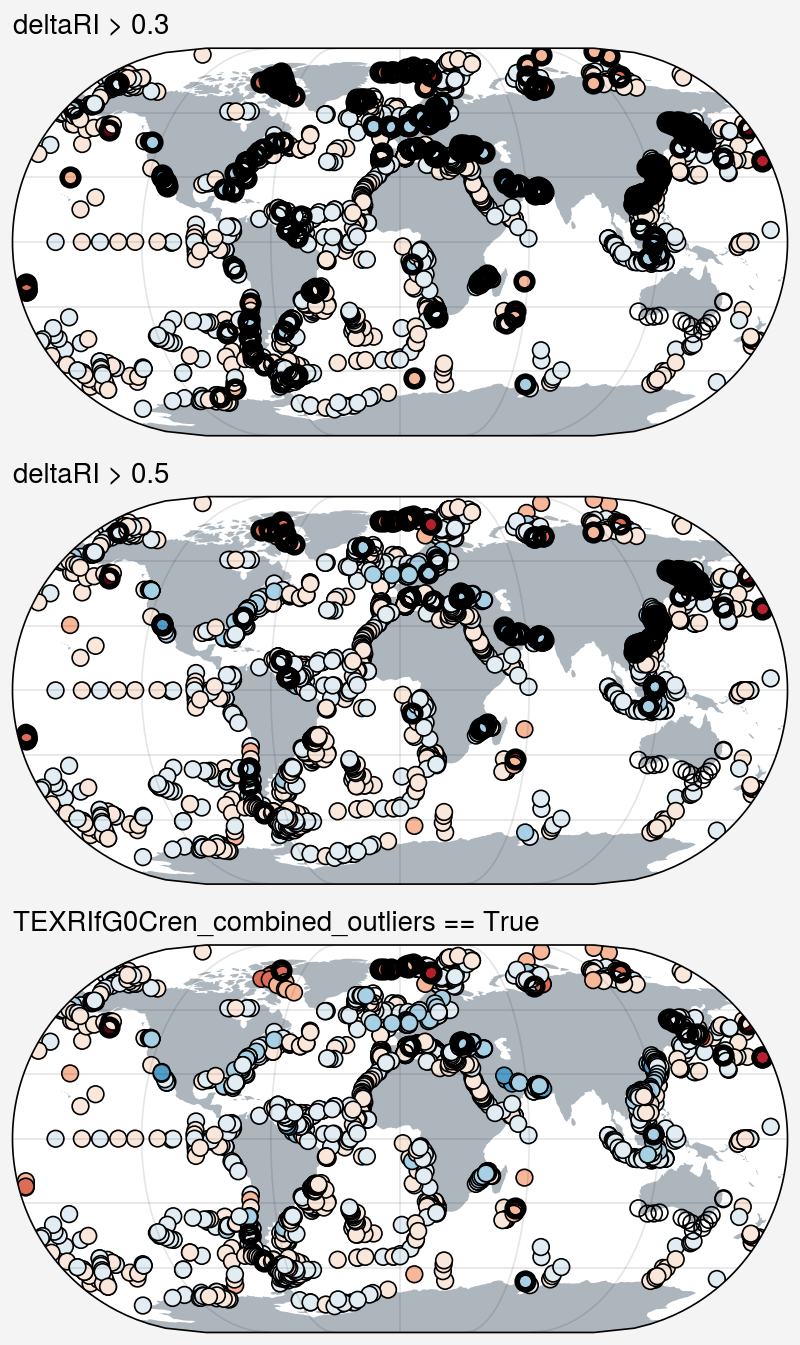

In [83]:
fig, axs = plot.subplots(proj='eck3',width=4,nrows=3)

axs.format(land=True, landcolor='gray5',landzorder=0)

plot_data = combined_df_raw[combined_df_raw['datatype']=='coretop']
plot_x = plot_data['Longitude']
plot_y = plot_data['Latitude']
plot_c = plot_data['deltaRI']

axs.scatter(plot_x, plot_y, c=plot_c, 
            cmap='RdBu_r', levels=np.arange(-1.2,1.3,0.3), 
            mec='k',
            extend='both')

plot_data = combined_df_raw[combined_df_raw['datatype']=='coretop'][abs(combined_df_raw['deltaRI'])>0.3]
plot_x = plot_data['Longitude']
plot_y = plot_data['Latitude']
axs[0].scatter(plot_x, plot_y, facecolors='none', 
            mec='k', lw=2,zorder=3)
axs[0].format(ltitle='deltaRI > 0.3', fontweight='bold')

plot_data = combined_df_raw[combined_df_raw['datatype']=='coretop'][abs(combined_df_raw['deltaRI'])>0.5]
plot_x = plot_data['Longitude']
plot_y = plot_data['Latitude']
axs[1].scatter(plot_x, plot_y, facecolors='none', 
            mec='k', lw=2,zorder=3)
axs[1].format(ltitle='deltaRI > 0.5', fontweight='bold')


plot_data = combined_df_raw[combined_df_raw['datatype']=='coretop'][combined_df_raw['TEXRIfG0Cren_combined_outliers']==True]
plot_x = plot_data['Longitude']
plot_y = plot_data['Latitude']
axs[2].scatter(plot_x, plot_y, facecolors='none', 
            mec='k', lw=2,zorder=3)
axs[2].format(ltitle='TEXRIfG0Cren_combined_outliers == True', fontweight='bold')


## 3.3 Determine QC flags

### 3.3.1 First - GDGT0 screening

In [84]:
def generalized_logistic_model_fixed_upper(x, x0, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((1 - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

<a list of 1 Line2D objects>

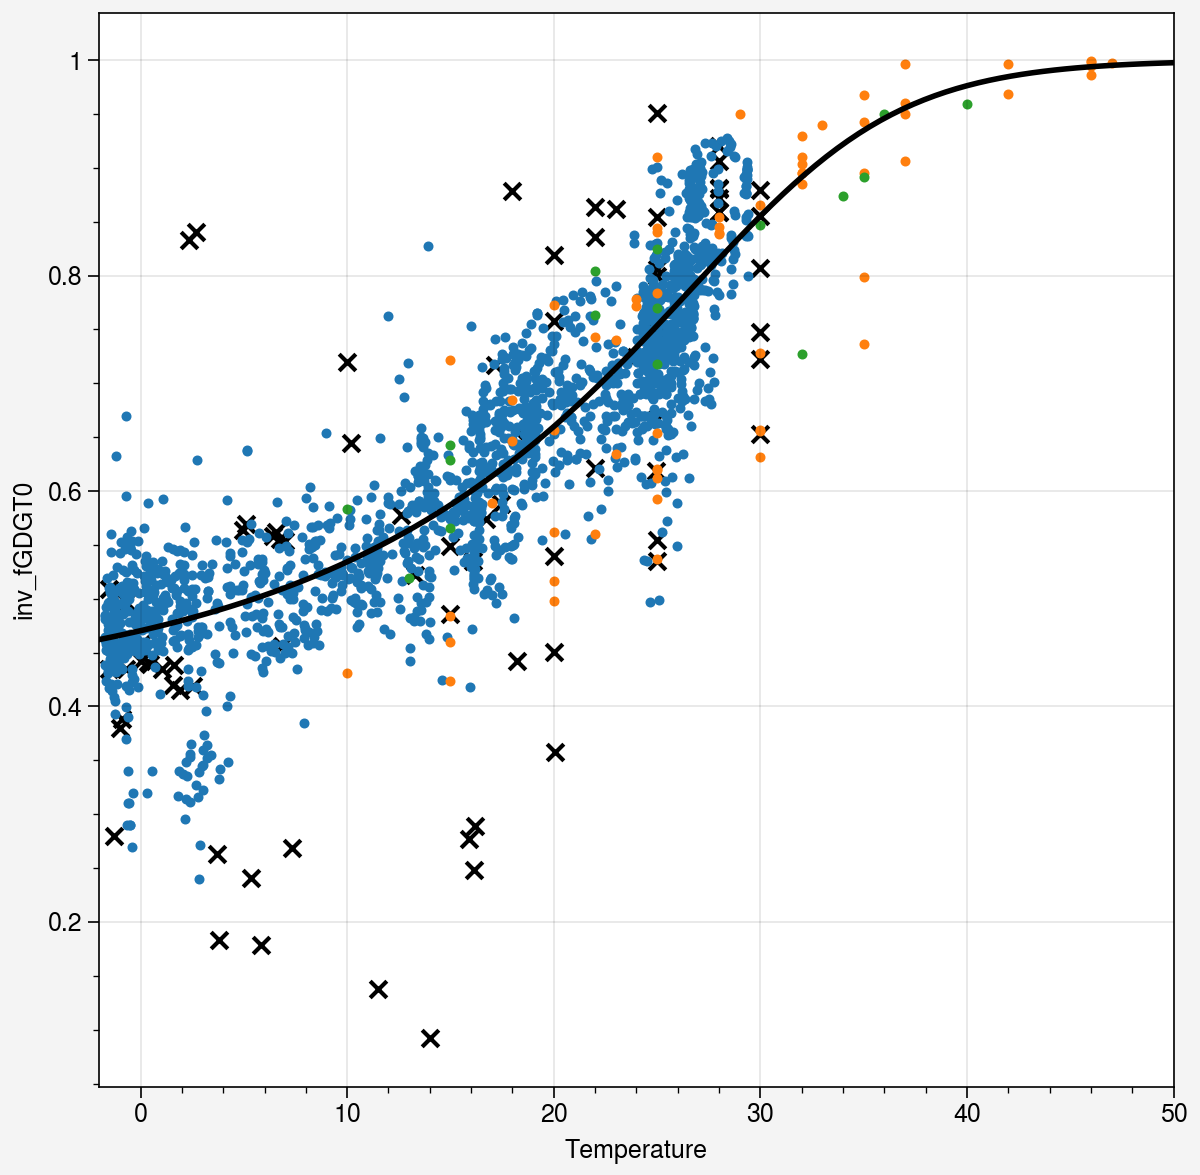

In [85]:
from scipy.optimize import curve_fit

fig, axs = plot.subplots(width=6)

ax = axs[0]

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False][
     combined_df_raw['TEXRIfG0Cren_combined_outliers_manual']==False].copy()

exclude_data = combined_df_raw[
    (combined_df_raw['lowAbundanceFlag']==True) |
    (combined_df_raw['TEXRIfG0Cren_combined_outliers_manual']==True)
]

ax.scatter(exclude_data['Temperature'], exclude_data['inv_fGDGT0'], 
           label='Excluded data', m='x', c='k')

grouped = plot_data.groupby('datatype')
for name, group in grouped:
     ax.scatter(group['Temperature'], group['inv_fGDGT0'], 
                label=name, m='.', cycle='tab10')

model = generalized_logistic_model_fixed_upper
nonnan_idx = ~np.isnan(plot_data['inv_fGDGT0'].values) & ~np.isnan(plot_data['Temperature'].values)
xdata = plot_data['Temperature'][nonnan_idx].values
ydata = plot_data['inv_fGDGT0'][nonnan_idx].values
popt, pcov = curve_fit(model, xdata, ydata, p0=[20, 0.1, 0.2, 1, 1], bounds=([0, 0, 0, 0.1, 0],[50, 0.5, 5, 5, 5]))
x_fit = np.linspace(-2,50,100)
y_fit = model(x_fit, *popt)
ax.plot(x_fit, y_fit, color='k', lw=2, label='Fitted curve')

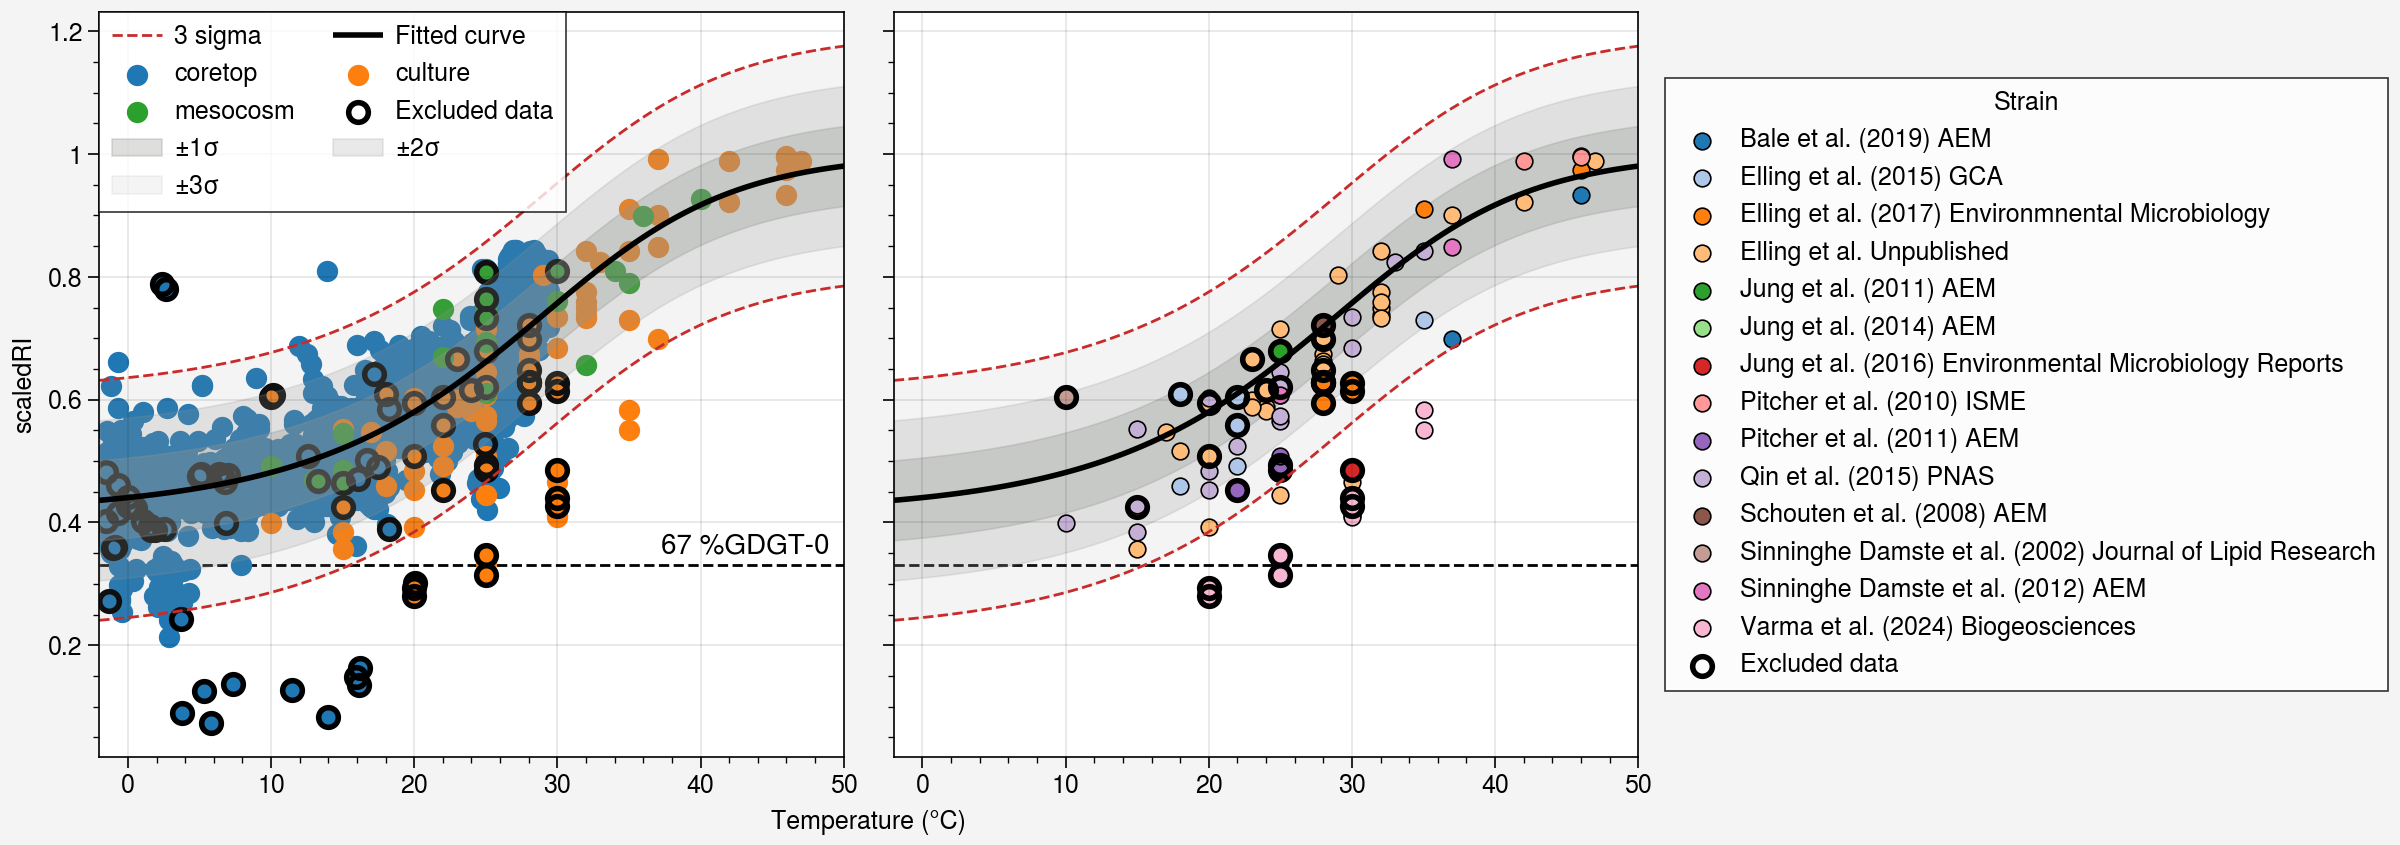

In [86]:
from scipy.optimize import curve_fit
from scipy.stats import t
import numpy as np

sel_yparam = 'scaledRI'

fig, axs = plot.subplots(width=12,ncols=2)
ax = axs[0]

# Plot raw data
grouped = combined_df_raw.groupby('datatype')
for name, group in grouped:
    ax.scatter(group['Temperature'], group[sel_yparam], 
               label=name, s=50, cycle='tab10')


# Fit the model
model = generalized_logistic_model_fixed_upper



nonnan_idx = ~np.isnan(combined_df_raw[sel_yparam].values) & \
             ~np.isnan(combined_df_raw['Temperature'].values)
qc_idx = nonnan_idx \
    & (combined_df_raw['lowAbundanceFlag']==False) \
    & (combined_df_raw['TEXRIfG0Cren_combined_outliers_manual']==False) 
            
nonqc_nonnan_idx = nonnan_idx & ((combined_df_raw['TEXRIfG0Cren_combined_outliers_manual']==True)
                                 | (combined_df_raw['lowAbundanceFlag']==True))

ax.scatter(combined_df_raw['Temperature'][nonqc_nonnan_idx], 
           combined_df_raw[sel_yparam][nonqc_nonnan_idx], 
           facecolors='none', mec='k', lw=2, s=50, label='Excluded data')
            

xdata = combined_df_raw['Temperature'][qc_idx].values
ydata = combined_df_raw[sel_yparam][qc_idx].values

popt, pcov = curve_fit(model, xdata, ydata, 
                       p0=[20, 0.1, 0.2, 1, 1], 
                       bounds=([0, 0, 0, 0.1, 0], [50, 0.5, 5, 5, 5]))

# Calculate residuals and standard error
y_pred = model(xdata, *popt)
residuals = ydata - y_pred
n = len(ydata)
p = len(popt)  # number of parameters
dof = n - p  # degrees of freedom
s_res = np.sqrt(np.sum(residuals**2) / dof)  # residual standard error

# Generate fitted curve
x_fit = np.linspace(-2, 50, 100)
y_fit = model(x_fit, *popt)


## calculate 3 sigmas from the trendline fit
sigma_1 = 1 * s_res
sigma_2 = 2 * s_res
sigma_3 = 3 * s_res

axs.plot(x_fit, y_fit + sigma_3, color='red9', lw=1, ls='--', label='3 sigma')
axs.plot(x_fit, y_fit - sigma_3, color='red9', lw=1, ls='--', label='')


# Plot fitted curve and confidence intervals
axs.plot(x_fit, y_fit, color='k', lw=2, label='Fitted curve')
axs.fill_between(x_fit, y_fit - sigma_1, y_fit + sigma_1, 
                alpha=0.3, color='gray', label=r'$\pm 1 \sigma$')
axs.fill_between(x_fit, y_fit - sigma_2, y_fit + sigma_2, 
                alpha=0.2, color='gray', label=r'$\pm 2 \sigma$')
axs.fill_between(x_fit, y_fit - sigma_3, y_fit + sigma_3, 
                alpha=0.1, color='gray', label=r'$\pm 3 \sigma$')

axs[0].legend(loc='ul',ncols=2)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel(sel_yparam)

axs.axhline((1-0.67), color='k', lw=1, ls='--',zorder=0)
axs[0].text(50-1, (1-0.67)+0.02, '67 %GDGT-0', fontsize=10, color='k', ha='right')


### plot only culture data by strains
plot_data = combined_df_raw[combined_df_raw['datatype']=='culture'].copy()

grouped = plot_data.groupby('reference_name')
ax = axs[1]
for name, group in grouped:
    plot_x = group['Temperature']
    plot_y = group[sel_yparam]
    ax.scatter(plot_x, plot_y, label=name, m='o', mec='k', cycle='tab20')
    
ax.scatter(combined_df_raw['Temperature'][nonqc_nonnan_idx][combined_df_raw['datatype']=='culture'], 
           combined_df_raw[sel_yparam][nonqc_nonnan_idx][combined_df_raw['datatype']=='culture'], 
           facecolors='none', mec='k', lw=2, s=50, label='Excluded data')
    
h, l = ax.get_legend_handles_labels()
ax.legend(h[5:], l[5:], title='Strain', loc='r',ncols=1)

In [87]:
coretop_df[coretop_df['scaledRI']>0.8][coretop_df['SST'].between(10,20)]

,sampleID,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,TEX86,...,mahalanobis_distance,mahalanobis_distance_weights,mahalanobis_outlier,TEX86L,ringIndex05,scaledRI05,lowAbundanceFlag,inv_fGDGT0,TEXRI_mahalDist,TEXRI_mahalDist_outliers
1387,RR01388,JET_RR_01388,POS363_110-2,MC,0.00,1.00,43.71,29.86,82.00,0.68,...,4.14,0.72,False,0.23,4.03,0.81,False,0.83,2.23,False


In [88]:
combined_df_raw[combined_df_raw['datatype']=='coretop'][combined_df_raw['scaledRI']>0.8][combined_df_raw['Temperature'].between(10,20)]

,Latitude,Longitude,modernWaterDepth,Temperature,TEX86,ringIndex,scaledRI,inv_fGDGT0,BIT,methaneIndex,...,TEXRIfG0_mahalDist_outliers,TEXRIfG0_mahalDist_outliers_manual,TEXRIfG0Cren_mahalDist,TEXRIfG0Cren_mahalDist_outliers,TEXRIfG0Cren_mahalDist_outliers_manual,fG0Cren_mahalDist,fG0Cren_mahalDist_outliers,fG0Cren_mahalDist_outliers_manual,TEXRIfG0Cren_fG0Cren_combined_outliers,TEXRIfG0Cren_fG0Cren_combined_outliers_manual
1387,43.71,29.86,82.00,13.90,0.68,3.24,0.81,0.83,0.07,0.04,...,False,False,3.78,False,False,3.23,False,False,False,False


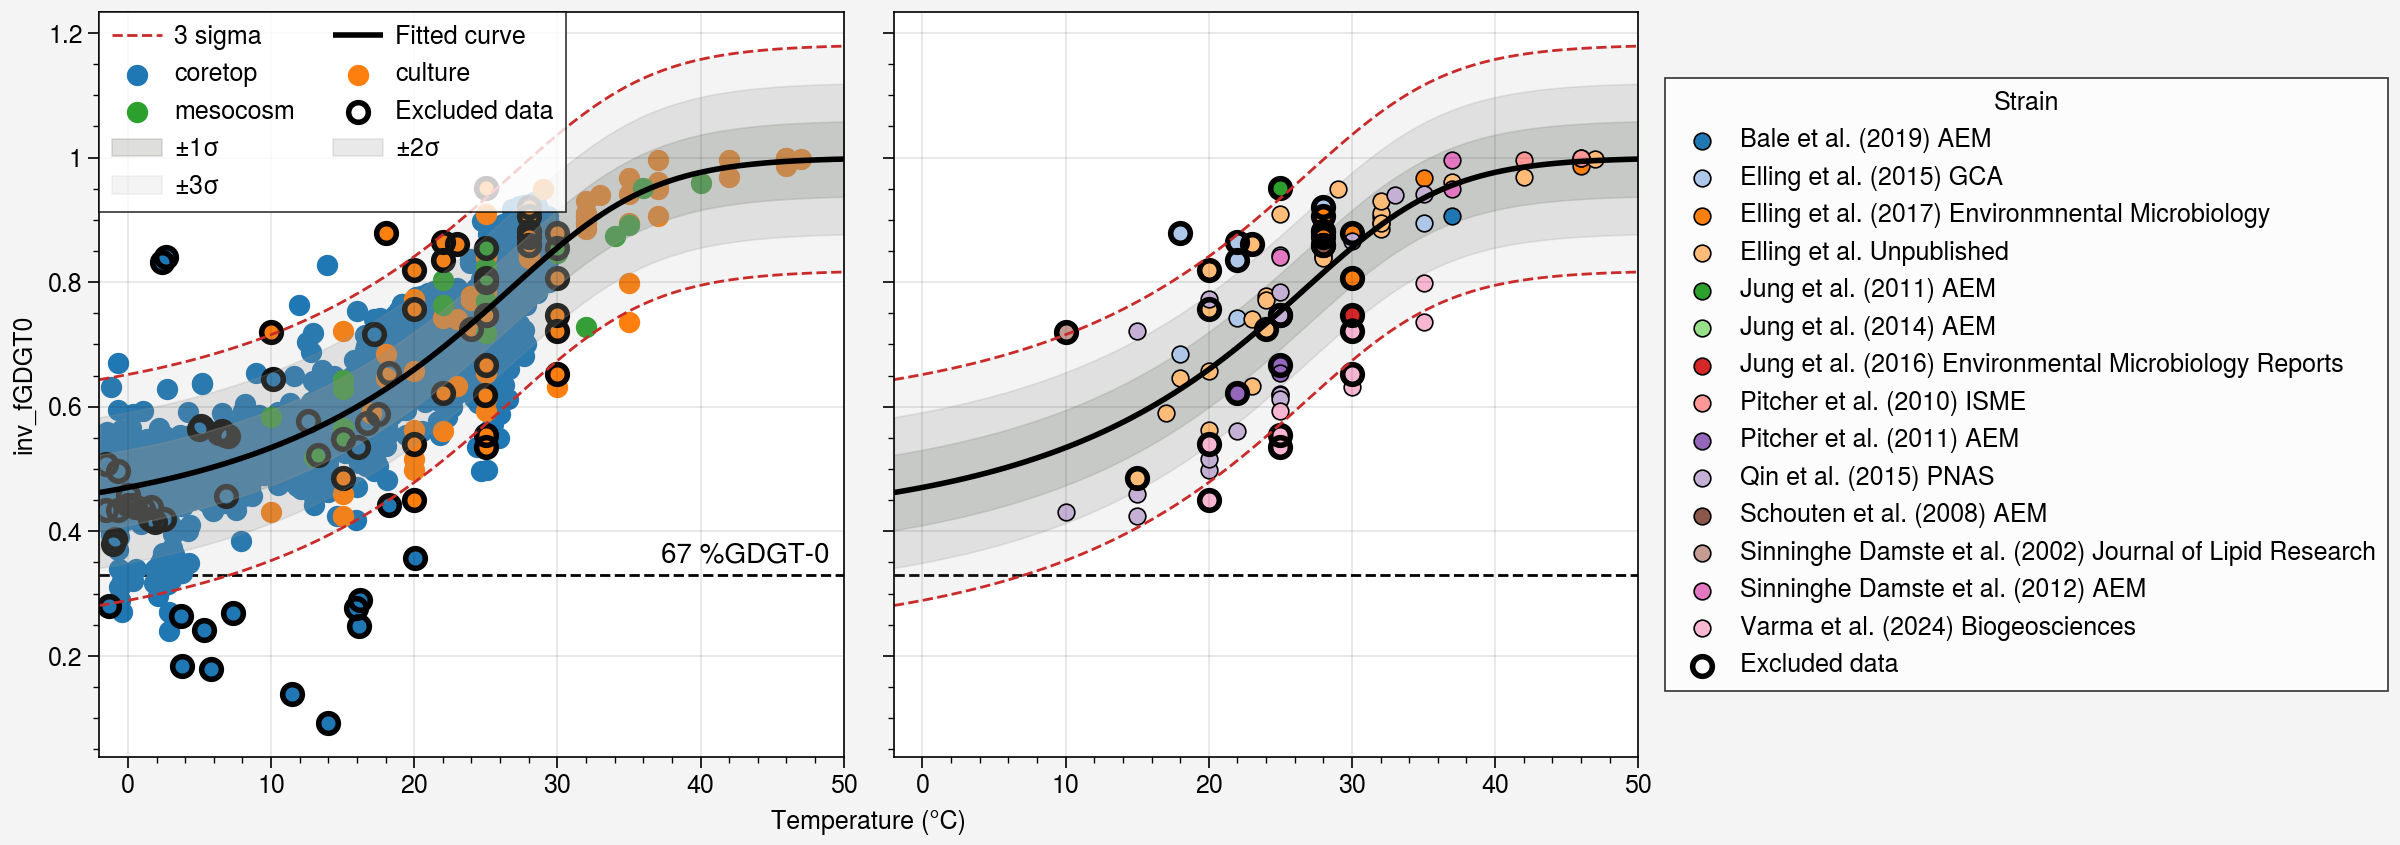

In [89]:
from scipy.optimize import curve_fit
from scipy.stats import t
import numpy as np

sel_yparam = 'inv_fGDGT0'

fig, axs = plot.subplots(width=12,ncols=2)
ax = axs[0]

# Plot raw data
grouped = combined_df_raw.groupby('datatype')
for name, group in grouped:
    ax.scatter(group['Temperature'], group[sel_yparam], 
               label=name, s=50, cycle='tab10')


# Fit the model
model = generalized_logistic_model_fixed_upper



nonnan_idx = ~np.isnan(combined_df_raw[sel_yparam].values) & \
             ~np.isnan(combined_df_raw['Temperature'].values)
qc_idx = nonnan_idx \
    & (combined_df_raw['lowAbundanceFlag']==False) \
    & (combined_df_raw['TEXRIfG0Cren_combined_outliers_manual']==False) 
            
nonqc_nonnan_idx = nonnan_idx & ((combined_df_raw['TEXRIfG0Cren_combined_outliers_manual']==True)
                                 | (combined_df_raw['lowAbundanceFlag']==True))

ax.scatter(combined_df_raw['Temperature'][nonqc_nonnan_idx], 
           combined_df_raw[sel_yparam][nonqc_nonnan_idx], 
           facecolors='none', mec='k', lw=2, s=50, label='Excluded data')
            

xdata = combined_df_raw['Temperature'][qc_idx].values
ydata = combined_df_raw[sel_yparam][qc_idx].values

popt, pcov = curve_fit(model, xdata, ydata, 
                       p0=[20, 0.1, 0.2, 1, 1], 
                       bounds=([0, 0, 0, 0.1, 0], [50, 0.5, 5, 5, 5]))

# Calculate residuals and standard error
y_pred = model(xdata, *popt)
residuals = ydata - y_pred
n = len(ydata)
p = len(popt)  # number of parameters
dof = n - p  # degrees of freedom
s_res = np.sqrt(np.sum(residuals**2) / dof)  # residual standard error

# Generate fitted curve
x_fit = np.linspace(-2, 50, 100)
y_fit = model(x_fit, *popt)


## calculate 3 sigmas from the trendline fit
sigma_1 = 1 * s_res
sigma_2 = 2 * s_res
sigma_3 = 3 * s_res

axs.plot(x_fit, y_fit + sigma_3, color='red9', lw=1, ls='--', label='3 sigma')
axs.plot(x_fit, y_fit - sigma_3, color='red9', lw=1, ls='--', label='')


# Plot fitted curve and confidence intervals
axs.plot(x_fit, y_fit, color='k', lw=2, label='Fitted curve')
axs.fill_between(x_fit, y_fit - sigma_1, y_fit + sigma_1, 
                alpha=0.3, color='gray', label=r'$\pm 1 \sigma$')
axs.fill_between(x_fit, y_fit - sigma_2, y_fit + sigma_2, 
                alpha=0.2, color='gray', label=r'$\pm 2 \sigma$')
axs.fill_between(x_fit, y_fit - sigma_3, y_fit + sigma_3, 
                alpha=0.1, color='gray', label=r'$\pm 3 \sigma$')

axs[0].legend(loc='ul',ncols=2)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel(sel_yparam)

axs.axhline((1-0.67), color='k', lw=1, ls='--',zorder=0)
axs[0].text(50-1, (1-0.67)+0.02, '67 %GDGT-0', fontsize=10, color='k', ha='right')


### plot only culture data by strains
plot_data = combined_df_raw[combined_df_raw['datatype']=='culture'].copy()

grouped = plot_data.groupby('reference_name')
ax = axs[1]
for name, group in grouped:
    plot_x = group['Temperature']
    plot_y = group[sel_yparam]
    ax.scatter(plot_x, plot_y, label=name, m='o', mec='k', cycle='tab20')
    
ax.scatter(combined_df_raw['Temperature'][nonqc_nonnan_idx][combined_df_raw['datatype']=='culture'], 
           combined_df_raw[sel_yparam][nonqc_nonnan_idx][combined_df_raw['datatype']=='culture'], 
           facecolors='none', mec='k', lw=2, s=50, label='Excluded data')
    
h, l = ax.get_legend_handles_labels()
ax.legend(h[5:], l[5:], title='Strain', loc='r',ncols=1)

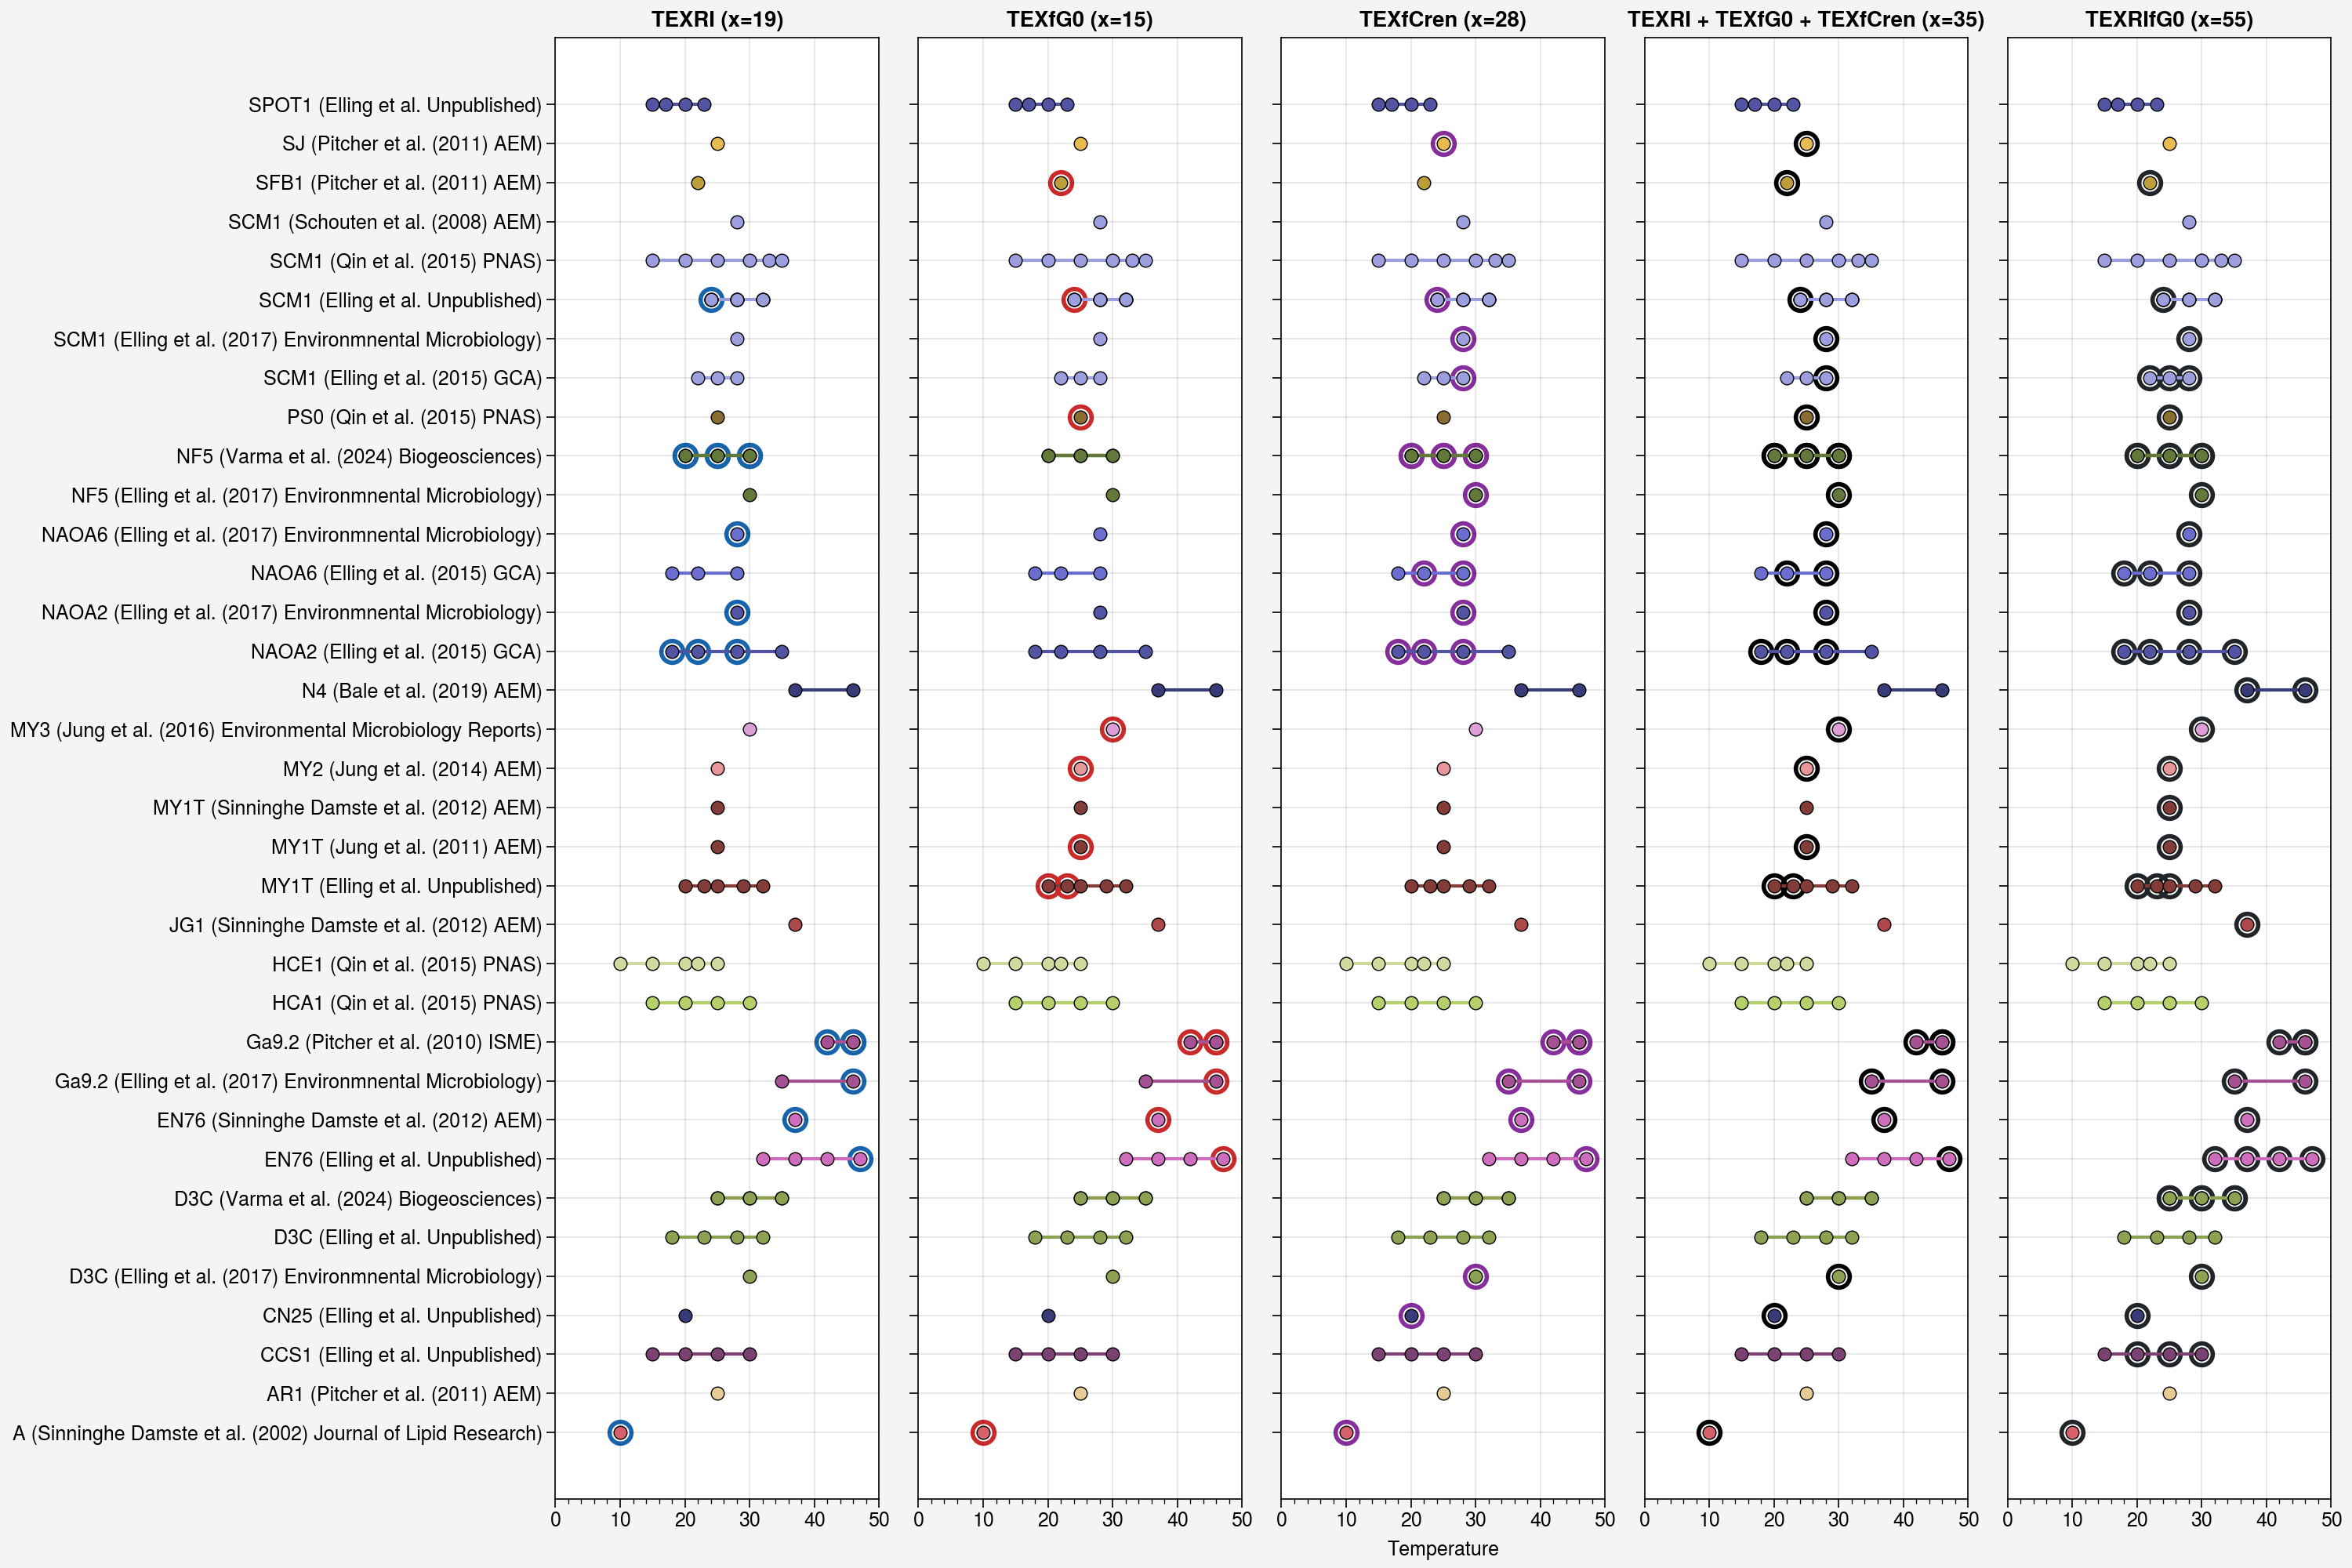

In [90]:
outlier_extension = ''

fig, axs = plot.subplots(width=15,height=10,ncols=5)

culture_df = combined_df_raw[combined_df_raw['datatype']=='culture']

### strains color dict
strain_names = culture_df['Strains'].unique()
colors = plot.get_colors('tab20b', len(strain_names))
strain_color_dict = dict(zip(strain_names, colors))

kk = 0
y_tick_labels = []
for i, (name, group) in enumerate(culture_df.groupby('Strains')):
    for j, (ref_name, ref_group) in enumerate(group.groupby('reference_name')):
        plot_x = ref_group['Temperature'].values
        plot_y = np.full(len(ref_group), kk)
        axs.plot(plot_x, plot_y, m='o', label=name, 
                mec='k', mew=0.5,
                c=strain_color_dict.get(name,'gray'))
        kk += 1
        
        exclude_data = ref_group[ref_group['TEXRI_mahalDist_outliers'+outlier_extension]==True]
        axs[0].scatter(exclude_data['Temperature'], np.full(len(exclude_data), kk-1), 
                   facecolors='none', mec='blue9', lw=2, s=100, label='Excluded data')
        
        exclude_data = ref_group[ref_group['TEXfG0_mahalDist_outliers'+outlier_extension]==True]
        axs[1].scatter(exclude_data['Temperature'], np.full(len(exclude_data), kk-1), 
                   facecolors='none', mec='red9', lw=2, s=100, label='Excluded data')
        
        exclude_data = ref_group[ref_group['TEXfCren_mahalDist_outliers'+outlier_extension]==True]
        axs[2].scatter(exclude_data['Temperature'], np.full(len(exclude_data), kk-1), 
                   facecolors='none', mec='grape9', lw=2, s=100, label='Excluded data')
        
        exclude_data = ref_group[(ref_group['TEXRIfG0Cren_combined_outliers'+outlier_extension]==True)]
        axs[3].scatter(exclude_data['Temperature'], np.full(len(exclude_data), kk-1), 
                   facecolors='none', mec='k', lw=2, s=100, label='Excluded data')
        
        exclude_data = ref_group[ref_group['TEXRIfG0Cren_mahalDist_outliers'+outlier_extension]==True]
        axs[4].scatter(exclude_data['Temperature'], np.full(len(exclude_data), kk-1), 
                   facecolors='none', mec='gray9', lw=2, s=100, label='Excluded data')
        
        y_tick_labels.append(f'{name} ({ref_name})')
        
axs.format(
    yticklabels=y_tick_labels,
    yticks=np.arange(0,kk,1),
    ytickminor=False,
    xreverse=False,
    xlim=(0,50),
)

title_list = [f"TEXRI (x={len(culture_df[culture_df['TEXRI_mahalDist_outliers'+outlier_extension]==True])})", 
              f"TEXfG0 (x={len(culture_df[culture_df['TEXfG0_mahalDist_outliers'+outlier_extension]==True])})", 
              f"TEXfCren (x={len(culture_df[culture_df['TEXfCren_mahalDist_outliers'+outlier_extension]==True])})", 
              f"TEXRI + TEXfG0 + TEXfCren (x={len(culture_df[culture_df['TEXRIfG0Cren_combined_outliers'+outlier_extension]==True])})", 
              f"TEXRIfG0 (x={len(culture_df[(culture_df['TEXRIfG0Cren_mahalDist_outliers'+outlier_extension]==True)])})"]

for i in range(5):
    axs[i].set_title(title_list[i], fontweight='bold')

In [91]:
len(culture_df[((culture_df['TEXRI_mahalDist_outliers_manual']==True)
              | (culture_df['TEXfG0_mahalDist_outliers_manual']==True)
              | (culture_df['TEXfCren_mahalDist_outliers_manual']==True))])

28

In [ ]:
from scipy.optimize import curve_fit
from scipy.stats import t
import numpy as np

fig, axs = plot.subplots(width=10,ncols=2)
ax = axs[0]

# Plot raw data
grouped = combined_df_raw.groupby('datatype')
for name, group in grouped:
    ax.scatter(group['Temperature'], group['CrenOverZeroCren'], 
               label=name, s=50, cycle='tab10')


# Fit the model
model = generalized_logistic_model_fixed_upper



nonnan_idx = ~np.isnan(combined_df_raw['CrenOverZeroCren'].values) & \
             ~np.isnan(combined_df_raw['Temperature'].values)
qc_idx = nonnan_idx & (combined_df_raw['TEXRI_mahalDist_outliers_manual']==False) & \
            (combined_df_raw['lowAbundanceFlag']==False)
            
nonqc_nonnan_idx = nonnan_idx & ((combined_df_raw['TEXRI_mahalDist_outliers_manual']==True) | \
                                 (combined_df_raw['lowAbundanceFlag']==True))

ax.scatter(combined_df_raw['Temperature'][nonqc_nonnan_idx], 
           combined_df_raw['CrenOverZeroCren'][nonqc_nonnan_idx], 
           facecolors='none', mec='k', lw=2, s=50, label='Excluded data')
            

xdata = combined_df_raw['Temperature'][qc_idx].values
ydata = combined_df_raw['CrenOverZeroCren'][qc_idx].values

popt, pcov = curve_fit(model, xdata, ydata, 
                       p0=[20, 0.1, 0.2, 1, 1], 
                       bounds=([0, 0, 0, 0.1, 0], [50, 0.5, 5, 5, 5]))

# Calculate residuals and standard error
y_pred = model(xdata, *popt)
residuals = ydata - y_pred
n = len(ydata)
p = len(popt)  # number of parameters
dof = n - p  # degrees of freedom
s_res = np.sqrt(np.sum(residuals**2) / dof)  # residual standard error

# Generate fitted curve
x_fit = np.linspace(-2, 50, 100)
y_fit = model(x_fit, *popt)

# Calculate prediction intervals
# For new observations (prediction interval)
def prediction_interval(x, popt, pcov, x_fit, s_res, confidence=0.95):
    """
    Calculate prediction interval for new observations
    """
    alpha = 1 - confidence
    t_val = t.ppf(1 - alpha/2, dof)
    
    # Jacobian at prediction points
    delta = 1e-8
    jacobian = np.zeros((len(x_fit), len(popt)))
    for i in range(len(popt)):
        popt_plus = popt.copy()
        popt_plus[i] += delta
        jacobian[:, i] = (model(x_fit, *popt_plus) - model(x_fit, *popt)) / delta
    
    # Variance of predictions
    var_pred = s_res**2 * (1 + np.sum((jacobian @ pcov) * jacobian, axis=1))
    se_pred = np.sqrt(var_pred)
    
    margin = t_val * se_pred
    return margin

# Calculate intervals for plotting
margin_90 = prediction_interval(xdata, popt, pcov, x_fit, s_res, confidence=0.90)
margin_95 = prediction_interval(xdata, popt, pcov, x_fit, s_res, confidence=0.95)
margin_99 = prediction_interval(xdata, popt, pcov, x_fit, s_res, confidence=0.99)

# Plot fitted curve and confidence intervals
axs.plot(x_fit, y_fit, color='k', lw=2, label='Fitted curve')
axs.plot(x_fit, y_fit+0.15, color='k', lw=1, ls=':', label='Fitted curve +/- 0.15')
axs.plot(x_fit, y_fit-0.15, color='k', lw=1, ls=':', label='')
axs.fill_between(x_fit, y_fit - margin_90, y_fit + margin_90, 
                alpha=0.3, color='gray', label='90% PI')
axs.fill_between(x_fit, y_fit - margin_95, y_fit + margin_95, 
                alpha=0.2, color='gray', label='95% PI')
axs.fill_between(x_fit, y_fit - margin_99, y_fit + margin_99, 
                alpha=0.1, color='gray', label='99% PI')

axs[0].legend(loc='ul',ncols=2)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('CrenOverZeroCren')

axs.axhline((1-0.67), color='k', lw=1, ls='--',zorder=0)
axs[0].text(50-1, (1-0.67)+0.02, '67 %GDGT-0', fontsize=10, color='k', ha='right')


### plot only culture data by strains
plot_data = combined_df_raw[
    (combined_df_raw['datatype']=='culture') &
    (combined_df_raw['lowAbundanceFlag']==False) &
    (combined_df_raw['TEXRI_mahalDist_outliers_manual']==False)
].copy()

grouped = plot_data.groupby('organism_commonName')
ax = axs[1]
for name, group in grouped:
    plot_x = group['Temperature']
    plot_y = group['CrenOverZeroCren']
    ax.scatter(plot_x, plot_y, label=name, m='o', mec='k', cycle='tab20')
    
h, l = ax.get_legend_handles_labels()
ax.legend(h[5:], l[5:], title='Strain', loc='r',ncols=1)

# ### plot s-curve from .3f values 'y = 0.407 + ((1 - 0.407) / (1 + 2.107 * exp(-0.253 * (x - 29.891)))^(1/2.891))'
# x_scurve = np.linspace(-2,50,100)
# y_scurve = generalized_logistic_model_fixed_upper(x_scurve, 29.891, 0.407, 0.253, 2.891, 2.107)
# axs[0].plot(x_scurve, y_scurve, color='red', lw=2, ls='--', label='Schouten et al. (2007) s-curve')
# axs[1].plot(x_scurve, y_scurve, color='red', lw=2, ls='--', label='Schouten et al. (2007) s-curve')

In [ ]:
#### write an S-curve equation fitting function based on popt

def s_curve_equation(x, popt):
    """
    Generate S-curve equation string from fitted parameters.
    """
    x0, b, k, v, Q = popt
    equation = f"y = {b:.3f} + ((1 - {b:.3f}) / (1 + {Q:.3f} * exp(-{k:.3f} * (x - {x0:.3f})))^(1/{v:.3f}))"
    return equation
s_curve_eq_invGDGT0 = s_curve_equation(x=None, popt=popt)
s_curve_eq_invGDGT0

In [ ]:
popt_CrenOverZeroCren = popt
combined_df_raw['predCrenOverZeroCren'] = generalized_logistic_model_fixed_upper(
    combined_df_raw['Temperature'], *popt_CrenOverZeroCren
)

combined_df_raw['deltaCrenOverZeroCren'] = combined_df_raw['CrenOverZeroCren'] - combined_df_raw['predCrenOverZeroCren']
combined_df_raw

In [ ]:
fig, axs = plot.subplots(width=8, ncols=2, proj=('eck3',None), wratios=(2,1))
axs.format(land=True, landcolor='gray5',landzorder=0)

ax = axs[0]

plot_data = combined_df_raw[combined_df_raw['datatype']=='coretop'][
    (combined_df_raw['lowAbundanceFlag']==False) &
    (combined_df_raw['TEXRI_mahalDist_outliers_manual']==False)
]
plot_x = plot_data['Longitude']
plot_y = plot_data['Latitude']
plot_c = plot_data['deltaCrenOverZeroCren']
m = ax.scatter(plot_x, plot_y, c=plot_c,
            cmap='RdBu_r', levels=np.arange(-0.15,0.16,0.05), 
            mec='k',
            extend='both')

plot_excludeCOZC_data = plot_data[abs(plot_data['deltaCrenOverZeroCren'])>0.15]
plot_x = plot_excludeCOZC_data['Longitude']
plot_y = plot_excludeCOZC_data['Latitude']
ax.scatter(plot_x, plot_y, facecolors='none', 
            mec='k', lw=2,zorder=3)
ax.colorbar(m, loc='b',title=r'deltaCrenOverZeroCren ($\Delta$%Cren)')

ax = axs[1]
plot_x = plot_data['Temperature']
plot_y = plot_data['scaledRI']
plot_c = plot_data['deltaCrenOverZeroCren']
m = ax.scatter(plot_x, plot_y, c=plot_c,
            cmap='RdBu_r', levels=np.arange(-0.15,0.16,0.05), 
            mec='k',
            extend='both')

plot_x = plot_excludeCOZC_data['Temperature']
plot_y = plot_excludeCOZC_data['scaledRI']
ax.scatter(plot_x, plot_y, facecolors='none', 
            mec='k', lw=2,zorder=3)



axs.format(suptitle=r'Fitering with $\delta$%Cren > 0.15')

In [ ]:
fig, axs = plot.subplots(width=12,ncols=4)

ax = axs[0]

plot_data = culture_meso_df[
    culture_meso_df['Temperature']<=50][
        culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])][
            culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences'
        ]
grouped = plot_data.groupby('organism_broadClass3')
for name, group in grouped:
    ax.scatter(group['Temperature'], group['scaledRI'], label=name, cycle='tab10')

h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='b', ncols=1)

ax = axs[1]
grouped = plot_data.groupby('GTDB_species')
for name, group in grouped:
    ax.scatter(group['Temperature'], group['scaledRI'], label=name, cycle='tab10')
h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='b', ncols=1)

ax = axs[2]
grouped = plot_data.groupby('Strains')
for name, group in grouped:
    ax.scatter(group['Temperature'], group['scaledRI'], label=name, cycle='tab20')
h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='b', ncols=2)

ax = axs[3]
grouped = plot_data.groupby('Source')
for name, group in grouped:
    ax.scatter(group['Temperature'], group['scaledRI'], label=name, cycle='tab20')
h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='b', ncols=1)

plot_x = coretop_df['SST']
plot_y = coretop_df['scaledRI']
axs.scatter(plot_x, plot_y, color='gray5', marker='.', s=50, label='coretop', zorder=0)

In [ ]:
fig, axs = plot.subplots(width=12, ncols=3, nrows=4, share=0)
plot_data = combined_df_raw[
        combined_df_raw['lowAbundanceFlag']==False][combined_df_raw['datatype']!='coretop'].copy()

QC_indices = ['BIT','methaneIndex','ZeroOverZeroCren','TEXRI_mahalDist']
temp_param = 'Temperature'
for i, qc_idx in enumerate(QC_indices):
    features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
    plot_coretop = combined_df_raw[
        combined_df_raw['lowAbundanceFlag']==False][combined_df_raw['datatype']=='coretop'].copy()
            
    ax = axs[i,0]
    XX_culmeso = plot_data['Temperature']
    YY_culmeso = plot_data['scaledRI']
    QC_culmeso = plot_data[qc_idx]
    
    XX_coretop = plot_coretop[temp_param]
    YY_coretop = plot_coretop['scaledRI']
    QC_coretop = plot_coretop[qc_idx].replace(-999, 0)

    XXX = pd.concat([XX_culmeso,XX_coretop])
    YYY = pd.concat([YY_culmeso,YY_coretop])
    QC_ALL = pd.concat([QC_culmeso,QC_coretop])

    m1 = ax.scatter(XXX, YYY, s=10, c=QC_ALL, 
            levels=np.arange(0, 1.01, 0.05) if qc_idx!='TEXRI_mahalDist' else np.arange(0, 5.1, 0.25),
            cmap='tab20',
            marker='o', zorder=2)
    ax.colorbar(m1, label=qc_idx, loc='ul', shrink=15,
                ticks=[0, 0.2, 0.4, 0.6, 0.8, 1] if qc_idx!='TEXRI_mahalDist' else [0, 1, 2, 3, 4, 5])

    ### generalized logistic function
    model = generalized_logistic_model_fixed_upper
    from scipy.optimize import curve_fit
    p0 = [20, 0.1, 0.2, 1, 1]  # Initial guess for parameters
    bounds = ([0, 0, 0, 0.01, 0.01], [50, 0.5, 1, 10, 10])

    nonnan_idx = ~np.isnan(XXX) & ~np.isnan(YYY)
    popt, pcov = curve_fit(model, XXX[nonnan_idx], YYY[nonnan_idx], p0=p0, bounds=bounds)
    x_fit = np.linspace(-5, 50, 100)
    y_fit = model(x_fit, *popt)
    ax.plot(x_fit, y_fit, color='red', linewidth=2, zorder=1)
    
    ax.format(ylim=(0,1.15))

    ax = axs[i,1]
    RI_residuals = YYY[nonnan_idx] - model(XXX[nonnan_idx], *popt)
    m = ax.scatter(QC_ALL[nonnan_idx], RI_residuals, s=10, c='gray5',
            marker='o', zorder=2)

    ### Sensitivity test by filtering BIT at different thresholds
    qc_thresholds = np.arange(0.1, 1.05, 0.05)[::-1] if qc_idx!='TEXRI_mahalDist' else np.arange(1, 5.1, 0.2)[::-1]
    rmse_score = []
    data_lens = []
    for qc_thr in qc_thresholds:
        bit_filter_idx = QC_coretop<=qc_thr
        XX_coretop_filt = plot_coretop.loc[bit_filter_idx,temp_param]
        YY_coretop_filt = plot_coretop.loc[bit_filter_idx,'scaledRI']
        
        XXX_filt = pd.concat([XX_culmeso,XX_coretop_filt])
        YYY_filt = pd.concat([YY_culmeso,YY_coretop_filt])
        QC_ALL_filt = pd.concat([QC_culmeso,QC_coretop.loc[bit_filter_idx]])
        
        nonnan_idx_filt = ~np.isnan(XXX_filt) & ~np.isnan(YYY_filt)
        popt_filt, pcov_filt = curve_fit(model, XXX_filt[nonnan_idx_filt], YYY_filt[nonnan_idx_filt], p0=p0, bounds=bounds)
        x_fit = np.linspace(-5, 50, 100)
        y_fit_filt = model(x_fit, *popt_filt)
        
        # Calculate RMSE
        residuals = YYY_filt[nonnan_idx_filt] - model(XXX_filt[nonnan_idx_filt], *popt_filt)
        rmse = np.sqrt(np.mean(residuals**2))
        rmse_score.append((qc_thr, rmse))
        data_lens.append((qc_thr, len(YYY_filt[nonnan_idx_filt])))
        # axs[i,0].plot(x_fit, y_fit_filt, linewidth=1, label=f'{qc_idx}<={qc_thr:.1f}', cycle='blues')
        
    ax = axs[i,2]
    rmse_score = pd.DataFrame(rmse_score, columns=['qc_threshold', 'RMSE'])
    ax.plot(rmse_score['qc_threshold'], rmse_score['RMSE'], marker='o')
    ax.set_xlabel('QC threshold')
    ax.set_ylabel('RMSE of RI residuals')
    ### label data_lens
    data_lens = pd.DataFrame(data_lens, columns=['qc_threshold', 'Data_length'])
    subset_data_lens = data_lens[data_lens['qc_threshold'].isin(qc_thresholds[::2])]
    data_lens = subset_data_lens.reset_index(drop=True)
    for _, row in data_lens.iterrows():
        ax.text(row['qc_threshold'], rmse_score.loc[rmse_score['qc_threshold']==row['qc_threshold'],'RMSE'].values[0],
                f'{int(row["Data_length"])}', fontsize=10, ha='left', va='bottom', rotation=45)
    # ax.format(ylim=(0.067,0.07))
    ax.format(xreverse=False)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats
import seaborn as sns

def evaluate_qc_filtering(XXX, YYY, QC_coretop, QC_culmeso, model, model_params, 
                         qc_idx='BIT', qc_config=None, cv_folds=5):
    """
    Comprehensive QC filtering evaluation for regression models
    
    Parameters:
    -----------
    XXX, YYY : pandas Series
        Combined predictor and response variables
    QC_coretop, QC_culmeso : pandas Series  
        QC index values for coretop and culture/mesocosm data
    model : function
        Regression model function (e.g., generalized_logistic_model_fixed_upper)
    model_params : dict
        Model parameters with 'p0' and 'bounds' keys
    qc_idx : str
        Name of the QC index being evaluated
    qc_config : dict, optional
        Configuration for QC thresholds and filtering:
        {
            'thresholds': array-like or None,  # Custom thresholds
            'filter_direction': 'low' or 'high',  # 'low' keeps values <= threshold, 'high' keeps >= threshold
            'auto_range': bool,  # If True, auto-generate thresholds based on data range
            'n_thresholds': int,  # Number of thresholds to test (for auto_range)
            'percentile_range': tuple,  # (min_pct, max_pct) for threshold range
        }
    cv_folds : int
        Number of cross-validation folds
        
    Returns:
    --------
    results_df : pandas DataFrame
        Comprehensive evaluation results
    """
    
    # Default QC configurations for common indices
    default_configs = {
        'BIT': {
            'filter_direction': 'low',  # Keep values <= threshold (lower BIT is better)
            'auto_range': True,
            'value_range': (0.1, 1),
            'n_thresholds': 19
        },
        'methaneIndex': {
            'filter_direction': 'low',  # Usually lower is better
            'auto_range': True, 
            'value_range': (0.1, 1),
            'n_thresholds': 19
        },
        'ZeroOverZeroCren': {
            'filter_direction': 'low',  # Usually higher ratios are better
            'auto_range': True,
            'value_range': (0.1, 1),
            'n_thresholds': 19
        },
        'TEXRI_mahalDist': {
            'filter_direction': 'low',  # Lower Mahalanobis distance is better
            'auto_range': True,
            'value_range': (1, 6),
            'n_thresholds': 11
        }
    }
    
    # Use provided config or default
    if qc_config is None:
        if qc_idx in default_configs:
            qc_config = default_configs[qc_idx]
        else:
            # Generic default
            qc_config = {
                'filter_direction': 'low',
                'auto_range': True,
                'value_range': (0.1, 1),
                'n_thresholds': 19
            }
    
    # Generate thresholds
    if qc_config.get('thresholds') is not None:
        qc_thresholds = np.array(qc_config['thresholds'])
    elif qc_config.get('auto_range', True):
        # Auto-generate thresholds based on specified value range
        min_val, max_val = qc_config.get('value_range', (0.1, 1))
        n_thresh = qc_config.get('n_thresholds', 19)
        qc_thresholds = np.linspace(min_val, max_val, n_thresh)
        
        # Reverse order if using 'low' filtering (strictest first)
        if qc_config.get('filter_direction') == 'low':
            qc_thresholds = qc_thresholds[::-1]
    else:
        # Default range if nothing specified
        qc_thresholds = np.arange(0.1, 1.05, 0.1)[::-1]
    
    print(f"Evaluating {qc_idx} with thresholds: {qc_thresholds}")
    print(f"Filter direction: {qc_config.get('filter_direction', 'low')}")
    print(f"Data structure check:")
    print(f"  XXX length: {len(XXX)}")
    print(f"  YYY length: {len(YYY)}")
    print(f"  QC_coretop length: {len(QC_coretop)}")
    print(f"  QC_culmeso length: {len(QC_culmeso)}")
    print(f"  Expected combined length: {len(QC_coretop) + len(QC_culmeso)}")
    print()
    def calculate_regression_metrics(y_true, y_pred):
        """Calculate comprehensive regression metrics"""
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        # Mean Absolute Percentage Error (MAPE) - handle division by zero
        mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true != 0, y_true, 1e-10))) * 100
        
        # Residual standard deviation
        residuals = y_true - y_pred
        residual_std = np.std(residuals)
        
        return {
            'RMSE': rmse,
            'MAE': mae, 
            'R2': r2,
            'MAPE': mape,
            'Residual_STD': residual_std,
            'N': len(y_true)
        }

    def residual_analysis(residuals, y_pred, title=""):
        """Perform residual analysis"""
        # Normality test (Shapiro-Wilk) - limit to 5000 samples for computational efficiency
        if len(residuals) > 5000:
            sample_idx = np.random.choice(len(residuals), 5000, replace=False)
            test_residuals = residuals[sample_idx]
        else:
            test_residuals = residuals
            
        shapiro_stat, shapiro_p = stats.shapiro(test_residuals)
        
        # Mean and std of residuals
        res_mean = np.mean(residuals)
        res_std = np.std(residuals)
        
        return {
            'Shapiro_stat': shapiro_stat,
            'Shapiro_p': shapiro_p,
            'Residual_mean': res_mean,
            'Residual_std': res_std,
            'Normal_residuals': shapiro_p > 0.05
        }

    # Cross-validation function
    def cross_validate_model(X, y, model_func, params, cv_folds=5):
        """Custom cross-validation for curve_fit models"""
        kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
        cv_scores = {'rmse': [], 'r2': [], 'mae': []}
        
        for train_idx, val_idx in kf.split(X):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx] 
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            try:
                # Fit model on training data
                from scipy.optimize import curve_fit
                popt_cv, _ = curve_fit(model_func, X_train, y_train, 
                                      p0=params['p0'], bounds=params['bounds'])
                
                # Predict on validation data
                y_pred_val = model_func(X_val, *popt_cv)
                
                # Calculate metrics
                cv_scores['rmse'].append(np.sqrt(mean_squared_error(y_val, y_pred_val)))
                cv_scores['r2'].append(r2_score(y_val, y_pred_val))
                cv_scores['mae'].append(mean_absolute_error(y_val, y_pred_val))
            except:
                # If fitting fails, append NaN
                cv_scores['rmse'].append(np.nan)
                cv_scores['r2'].append(np.nan)
                cv_scores['mae'].append(np.nan)
        
        return {f'CV_{k}': np.nanmean(v) for k, v in cv_scores.items()}

    # Main evaluation loop
    evaluation_results = []
    filter_direction = qc_config.get('filter_direction', 'low')
    
    # Combine QC indices (assuming XXX, YYY are already combined datasets)
    QC_ALL = pd.concat([QC_culmeso, QC_coretop])
    
    for ii, qc_thr in enumerate(qc_thresholds):
        print(f"Evaluating {qc_idx} threshold: {qc_thr:.4f}")
        
        # Create filter mask for the combined QC data
        if filter_direction == 'low':
            # For coretop data: apply threshold filter
            coretop_mask = QC_coretop <= qc_thr
            # For culture/mesocosm data: keep all (no filtering)
            culmeso_mask = pd.Series([True] * len(QC_culmeso), index=QC_culmeso.index)
            direction_symbol = '≤'
        else:  # 'high'
            coretop_mask = QC_coretop >= qc_thr
            culmeso_mask = pd.Series([True] * len(QC_culmeso), index=QC_culmeso.index)  
            direction_symbol = '≥'
        
        # Combine masks
        combined_mask = pd.concat([culmeso_mask, coretop_mask])
        
        # Apply filtering to the combined datasets
        XXX_filt = XXX[combined_mask]
        YYY_filt = YYY[combined_mask] 
        QC_ALL_filt = QC_ALL[combined_mask]
        
        nonnan_idx_filt = ~np.isnan(XXX_filt) & ~np.isnan(YYY_filt)
        X_clean = XXX_filt[nonnan_idx_filt]
        y_clean = YYY_filt[nonnan_idx_filt]
        
        if len(X_clean) < 10:  # Skip if too few points
            print(f"  Skipping - only {len(X_clean)} points remaining")
            continue
            
        # Fit the model
        try:
            from scipy.optimize import curve_fit
            popt_filt, pcov_filt = curve_fit(model, X_clean, y_clean, 
                                            p0=model_params['p0'], 
                                            bounds=model_params['bounds'])
            
            # Get predictions
            y_pred = model(X_clean, *popt_filt)
            residuals = y_clean - y_pred
            
            # Calculate basic metrics
            metrics = calculate_regression_metrics(y_clean, y_pred)
            
            # Residual analysis
            residual_stats = residual_analysis(residuals, y_pred)
            
            # Cross-validation (computationally intensive, optional)
            if len(X_clean) > 20:  # Only if enough data points
                cv_metrics = cross_validate_model(X_clean, y_clean, model, model_params, cv_folds)
            else:
                cv_metrics = {'CV_rmse': np.nan, 'CV_r2': np.nan, 'CV_mae': np.nan}
            
            # Model parameter uncertainty (from covariance matrix)
            param_errors = np.sqrt(np.diag(pcov_filt))
            
            # Combine all results
            result = {
                f'{qc_idx}_threshold': qc_thr,
                **metrics,
                **residual_stats,
                **cv_metrics,
                'Param_errors_mean': np.mean(param_errors),
                'Model_parameters': popt_filt,
                'Filter_direction': direction_symbol,
                'N_filtered_out': len(QC_coretop) - np.sum(coretop_mask),  # Only count filtered coretop samples
                'N_coretop_remaining': np.sum(coretop_mask),
                'N_culmeso_total': len(QC_culmeso)
            }
            
            evaluation_results.append(result)
            
        except Exception as e:
            print(f"  Failed to fit model for threshold {qc_thr}: {e}")
            continue

    # Convert to DataFrame for easy analysis
    results_df = pd.DataFrame(evaluation_results)
    
    if len(results_df) == 0:
        print("No successful model fits! Check your data and parameters.")
        return None
    
    # Display results
    print(f"\n{qc_idx} Evaluation Summary:")
    print("=" * 60)
    display_cols = [f'{qc_idx}_threshold', 'RMSE', 'MAE', 'R2', 'MAPE', 'N', 
                   'CV_rmse', 'CV_r2', 'Normal_residuals']
    available_cols = [col for col in display_cols if col in results_df.columns]
    print(results_df[available_cols].round(4))

    # Find optimal threshold based on different criteria
    optimal_rmse = results_df.loc[results_df['RMSE'].idxmin(), f'{qc_idx}_threshold']
    optimal_r2 = results_df.loc[results_df['R2'].idxmax(), f'{qc_idx}_threshold']
    if not results_df['CV_rmse'].isna().all():
        optimal_cv_rmse = results_df.loc[results_df['CV_rmse'].idxmin(), f'{qc_idx}_threshold']
    else:
        optimal_cv_rmse = "N/A"

    print(f"\nOptimal {qc_idx} thresholds:")
    print(f"Best RMSE: {optimal_rmse:.4f}")
    print(f"Best R²: {optimal_r2:.4f}")  
    print(f"Best CV RMSE: {optimal_cv_rmse}")

    # Plotting comprehensive results
    fig, axes = plot.subplots(nrows=2, ncols=3, figsize=(15, 10),share=0)
    
    threshold_col = f'{qc_idx}_threshold'

    # RMSE vs threshold
    axes[0,0].plot(results_df[threshold_col].values, results_df['RMSE'].values, 'o-', color='blue9', label='Training RMSE')
    if not results_df['CV_rmse'].isna().all():
        axes[0,0].plot(results_df[threshold_col].values, results_df['CV_rmse'].values, 'o--', color='blue7', label='CV RMSE')
    axes[0,0].set_xlabel(f'{qc_idx} Threshold')
    axes[0,0].set_ylabel('RMSE')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # R² vs threshold  
    axes[0,1].plot(results_df[threshold_col].values, results_df['R2'].values, 'o-', color='teal9', label='Training R²')
    if not results_df['CV_r2'].isna().all():
        axes[0,1].plot(results_df[threshold_col].values, results_df['CV_r2'].values, 'o--', color='teal7', label='CV R²')
    axes[0,1].set_xlabel(f'{qc_idx} Threshold')
    axes[0,1].set_ylabel('R²')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    # Sample size vs threshold
    axes[0,2].plot(results_df[threshold_col].values, results_df['N'].values, 'o-', color='grape9')
    
    axes[0,2].set_xlabel(f'{qc_idx} Threshold')
    axes[0,2].set_ylabel('Sample Size')
    axes[0,2].grid(True, alpha=0.3)

    # MAE vs RMSE
    scatter = axes[1,0].scatter(results_df['RMSE'].values, results_df['MAE'].values, 
                              c=results_df[threshold_col].values,
                              levels=np.arange(0, 1.05, 0.05) if qc_idx!='TEXRI_mahalDist' else np.arange(0, 6.1, 0.25),
                              cmap='tab20')
    axes[1,0].set_xlabel('RMSE')
    axes[1,0].set_ylabel('MAE')
    cbar = axes[1,0].colorbar(scatter, loc='ul',shrink=15,frameon=False,
                              ticks=[0, 0.2, 0.4, 0.6, 0.8, 1] if qc_idx!='TEXRI_mahalDist' else [0, 1, 2, 3, 4, 5, 6])
    cbar.set_label(f'{qc_idx} Threshold')

    # Residual normality
    normal_mask = results_df['Normal_residuals'].values
    axes[1,1].scatter(results_df.loc[normal_mask, threshold_col].values, 
                     results_df.loc[normal_mask, 'R2'].values, 
                     color='green', label='Normal residuals', alpha=0.7)
    if np.any(~normal_mask):
        axes[1,1].scatter(results_df.loc[~normal_mask, threshold_col].values, 
                         results_df.loc[~normal_mask, 'R2'].values, 
                         color='red', label='Non-normal residuals', alpha=0.7)
    axes[1,1].set_xlabel(f'{qc_idx} Threshold')
    axes[1,1].set_ylabel('R²')
    axes[1,1].legend()

    # Parameter uncertainty
    axes[1,2].plot(results_df[threshold_col].values, results_df['Param_errors_mean'].values, 'o-', color='brown')
    axes[1,2].set_xlabel(f'{qc_idx} Threshold')
    axes[1,2].set_ylabel('Mean Parameter Error')
    axes[1,2].grid(True, alpha=0.3)
    
    axes.format(xreverse=False)

    plt.suptitle(f'{qc_idx} Filtering Analysis', fontsize=16)
    plt.tight_layout()
    plt.show()

    return results_df

# Simplified wrapper function that matches your original code structure exactly
def evaluate_qc_filtering_simple(XXX, YYY, QC_coretop, QC_culmeso, model, model_params, qc_idx='BIT'):
    """
    Simplified wrapper that matches your original code structure
    
    Parameters:
    -----------
    XXX, YYY : pandas Series (already combined coretop + mesocosm data)
    QC_coretop, QC_culmeso : pandas Series (separate QC values)
    model : function (e.g., generalized_logistic_model_fixed_upper)
    model_params : dict with 'p0' and 'bounds'
    qc_idx : str (name of QC index)
    """
    return evaluate_qc_filtering(
        XXX=XXX, 
        YYY=YYY, 
        QC_coretop=QC_coretop, 
        QC_culmeso=QC_culmeso,
        model=model, 
        model_params=model_params, 
        qc_idx=qc_idx
    )

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def plot_qc_scatter_comparison(XXX, YYY, QC_coretop, QC_culmeso, model, model_params, 
                              qc_idx='BIT', qc_config=None, max_plots=8):
    """
    Create scatter plots showing XXX vs YYY for different QC thresholds
    
    Parameters:
    -----------
    XXX, YYY : pandas Series (combined data)
    QC_coretop, QC_culmeso : pandas Series (QC values)
    model : function (regression model)
    model_params : dict (model parameters)
    qc_idx : str (QC index name)
    qc_config : dict (QC configuration, same as main function)
    max_plots : int (maximum number of subplots to show)
    """
    
    # Use same configuration logic as main function
    default_configs = {
        'BIT': {'filter_direction': 'low', 'auto_range': True, 'value_range': (0.1, 1), 'n_thresholds': 10},
        'methaneIndex': {'filter_direction': 'low', 'auto_range': True, 'value_range': (0.1, 1), 'n_thresholds': 10},
        'ZeroOverZeroCren': {'filter_direction': 'low', 'auto_range': True, 'value_range': (0.1, 1), 'n_thresholds': 10},
        'TEXRI_mahalDist': {'filter_direction': 'low', 'auto_range': True, 'value_range': (1, 6), 'n_thresholds': 11}
    }
    
    if qc_config is None:
        qc_config = default_configs.get(qc_idx, {'filter_direction': 'low', 'auto_range': True, 'value_range': (0.1, 1), 'n_thresholds': 10})
    
    # Generate thresholds
    if qc_config.get('thresholds') is not None:
        qc_thresholds = np.array(qc_config['thresholds'])
    elif qc_config.get('auto_range', True):
        min_val, max_val = qc_config.get('value_range', (0.1, 1))
        n_thresh = qc_config.get('n_thresholds', 10)
        qc_thresholds = np.linspace(min_val, max_val, n_thresh)
        if qc_config.get('filter_direction') == 'low':
            qc_thresholds = qc_thresholds[::-1]
    else:
        qc_thresholds = np.arange(0.1, 1.05, 0.1)[::-1]
    
    # Limit number of plots
    if len(qc_thresholds) > max_plots:
        # Select evenly spaced thresholds
        indices = np.linspace(0, len(qc_thresholds)-1, max_plots, dtype=int)
        qc_thresholds = qc_thresholds[indices]
    
    # Setup subplot grid
    n_cols = 4
    n_rows = int(np.ceil(len(qc_thresholds) / n_cols))
    fig, axes = plot.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, 3.5*n_rows))
    
    
    # Combined QC data (assuming same order as XXX/YYY)
    QC_ALL = pd.concat([QC_culmeso, QC_coretop])
    
    # # Debug prints
    # print(f"Data structure check for {qc_idx}:")
    # print(f"  XXX length: {len(XXX)}")
    # print(f"  YYY length: {len(YYY)}")
    # print(f"  QC_culmeso length: {len(QC_culmeso)}")
    # print(f"  QC_coretop length: {len(QC_coretop)}")
    # print(f"  Expected combined QC length: {len(QC_culmeso) + len(QC_coretop)}")
    # print(f"  Actual QC_ALL length: {len(QC_ALL)}")
    # print()
    
    filter_direction = qc_config.get('filter_direction', 'low')
    direction_symbol = '≤' if filter_direction == 'low' else '≥'
    
    # Create x values for fitted curves
    x_fit = np.linspace(XXX.min() - 5, XXX.max() + 5, 200)
    
    for i, qc_thr in enumerate(qc_thresholds):
        ax = axes[i]
        
        # Create filter masks for coretop data only
        if filter_direction == 'low':
            coretop_mask = QC_coretop <= qc_thr
        else:
            coretop_mask = QC_coretop >= qc_thr
            
        # Debug: Check for NaN values in QC_coretop
        nan_count = QC_coretop.isna().sum()
        valid_count = (~QC_coretop.isna()).sum()
        passed_filter = coretop_mask.sum()  # This will be NaN if any NaN values present
        
        print(f"  Threshold {qc_thr:.2f}: QC_coretop NaNs={nan_count}, Valid={valid_count}, Passed filter={passed_filter}")
        
        # Handle NaN values properly - treat NaN as "pass through" for now
        coretop_mask_clean = coretop_mask.fillna(True)  # Let NaN values pass through
        
        # Apply filtering: keep all mesocosm/culture data + filtered coretop data
        n_culmeso = len(QC_culmeso)
        n_coretop = len(QC_coretop)
        
        # Create combined mask: all True for mesocosm + filtered mask for coretop
        combined_mask = pd.Series([True] * n_culmeso + coretop_mask_clean.tolist(), 
                                 index=XXX.index)
        
        print(f"  Combined mask length: {len(combined_mask)}, True count: {combined_mask.sum()}")
        
        # Apply filtering
        XXX_filt = XXX[combined_mask]
        YYY_filt = YYY[combined_mask] 
        QC_ALL_filt = QC_ALL[combined_mask]
        
        print(f"  After QC filtering: XXX_filt length: {len(XXX_filt)}")
        
        # Remove NaN values
        nonnan_idx = ~np.isnan(XXX_filt) & ~np.isnan(YYY_filt)
        X_clean = XXX_filt[nonnan_idx]
        y_clean = YYY_filt[nonnan_idx]
        QC_clean = QC_ALL_filt[nonnan_idx]
        
        print(f"  After NaN removal: X_clean length: {len(X_clean)}")
        print(f"  Lost {len(XXX_filt) - len(X_clean)} samples due to NaN in XXX/YYY")
        print()
        
        # Remove NaN values
        nonnan_idx = ~np.isnan(XXX_filt) & ~np.isnan(YYY_filt)
        X_clean = XXX_filt[nonnan_idx]
        y_clean = YYY_filt[nonnan_idx]
        QC_clean = QC_ALL_filt[nonnan_idx]
        
        # Scatter plot colored by QC values
        scatter = ax.scatter(X_clean, y_clean, c=QC_clean, cmap='tab20', 
                             levels=np.arange(0,1.01,0.05) if qc_idx != 'TEXRI_mahalDist' else np.arange(0,6.1,0.5),
                             m='.')
        
        # Fit model and plot curve
        if len(X_clean) >= 5:
            try:
                popt, pcov = curve_fit(model, X_clean, y_clean, 
                                     p0=model_params['p0'], bounds=model_params['bounds'])
                y_fit = model(x_fit, *popt)
                ax.plot(x_fit, y_fit, 'r-', linewidth=2, label='Fitted curve')
                
                # Calculate R² for title
                y_pred = model(X_clean, *popt)
                r2 = 1 - np.sum((y_clean - y_pred)**2) / np.sum((y_clean - np.mean(y_clean))**2)
                
                # calculate rmse for title
                rmse = np.sqrt(np.mean((y_clean - y_pred)**2))

                ax.set_title(f'{qc_idx} {direction_symbol} {qc_thr:.2f}\n(n={len(X_clean)}, R²={r2:.3f}, RMSE={rmse:.3f})', fontsize=10)
            except:
                ax.set_title(f'{qc_idx} {direction_symbol} {qc_thr:.2f}\n(n={len(X_clean)}, Fit failed)', fontsize=10)
        else:
            ax.set_title(f'{qc_idx} {direction_symbol} {qc_thr:.2f}\n(n={len(X_clean)}, Too few points)', fontsize=10)
        
        ax.set_xlabel('Temperature')
        ax.set_ylabel('Scaled RI')
        ax.grid(True, alpha=0.3)
        
        # Add colorbar to first plot
        if i == 0:
            cbar = fig.colorbar(scatter, loc='b', shrink=0.6)
            cbar.set_label(qc_idx)
    
    # Hide empty subplots
    for j in range(len(qc_thresholds), len(axes)):
        axes[j].axis('off')
    
    plt.suptitle(f'Data Distribution by {qc_idx} Filtering Threshold')
    plt.tight_layout()
    plt.show()


def plot_qc_residuals_comparison(XXX, YYY, QC_coretop, QC_culmeso, model, model_params, 
                                qc_idx='BIT', qc_config=None, max_plots=8):
    """
    Create residual plots for different QC thresholds
    
    Parameters:
    -----------
    XXX, YYY : pandas Series (combined data)
    QC_coretop, QC_culmeso : pandas Series (QC values)
    model : function (regression model)
    model_params : dict (model parameters)
    qc_idx : str (QC index name)
    qc_config : dict (QC configuration, same as main function)
    max_plots : int (maximum number of subplots to show)
    """
    
    # Use same configuration logic as main function
    default_configs = {
        'BIT': {'filter_direction': 'low', 'auto_range': True, 'value_range': (0.1, 1), 'n_thresholds': 10},
        'methaneIndex': {'filter_direction': 'low', 'auto_range': True, 'value_range': (0.1, 1), 'n_thresholds': 10},
        'ZeroOverZeroCren': {'filter_direction': 'low', 'auto_range': True, 'value_range': (0.1, 1), 'n_thresholds': 10},
        'TEXRI_mahalDist': {'filter_direction': 'low', 'auto_range': True, 'value_range': (1, 6), 'n_thresholds': 11}
    }
    
    if qc_config is None:
        qc_config = default_configs.get(qc_idx, {'filter_direction': 'low', 'auto_range': True, 'value_range': (0.1, 1), 'n_thresholds': 10})
    
    # Generate thresholds
    if qc_config.get('thresholds') is not None:
        qc_thresholds = np.array(qc_config['thresholds'])
    elif qc_config.get('auto_range', True):
        min_val, max_val = qc_config.get('value_range', (0.1, 1))
        n_thresh = qc_config.get('n_thresholds', 10)
        qc_thresholds = np.linspace(min_val, max_val, n_thresh)
        if qc_config.get('filter_direction') == 'low':
            qc_thresholds = qc_thresholds[::-1]
    else:
        qc_thresholds = np.arange(0.1, 1.05, 0.1)[::-1]
    
    # Limit number of plots
    if len(qc_thresholds) > max_plots:
        # Select evenly spaced thresholds
        indices = np.linspace(0, len(qc_thresholds)-1, max_plots, dtype=int)
        qc_thresholds = qc_thresholds[indices]
    
    # Setup subplot grid
    n_cols = 4
    n_rows = int(np.ceil(len(qc_thresholds) / n_cols))
    fig, axes = plot.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, 3.5*n_rows))

    # Combined QC data (assuming same order as XXX/YYY)
    QC_ALL = pd.concat([QC_culmeso, QC_coretop])
    
    # # Debug prints
    # print(f"Residuals analysis data structure check for {qc_idx}:")
    # print(f"  XXX length: {len(XXX)}")
    # print(f"  YYY length: {len(YYY)}")
    # print(f"  QC_culmeso length: {len(QC_culmeso)}")
    # print(f"  QC_coretop length: {len(QC_coretop)}")
    # print(f"  Expected combined QC length: {len(QC_culmeso) + len(QC_coretop)}")
    # print(f"  Actual QC_ALL length: {len(QC_ALL)}")
    # print()
    
    filter_direction = qc_config.get('filter_direction', 'low')
    direction_symbol = '≤' if filter_direction == 'low' else '≥'
    
    for i, qc_thr in enumerate(qc_thresholds):
        ax = axes[i]
        
        # Create filter masks for coretop data only
        if filter_direction == 'low':
            coretop_mask = QC_coretop <= qc_thr
        else:
            coretop_mask = QC_coretop >= qc_thr
        
        # Apply filtering: keep all mesocosm/culture data + filtered coretop data
        n_culmeso = len(QC_culmeso)
        n_coretop = len(QC_coretop)
        
        # Create combined mask: all True for mesocosm + filtered mask for coretop
        combined_mask = pd.Series([True] * n_culmeso + coretop_mask.tolist(), 
                                 index=XXX.index)
        
        # Apply filtering
        XXX_filt = XXX[combined_mask]
        YYY_filt = YYY[combined_mask]
        QC_ALL_filt = QC_ALL[combined_mask]
        
        # Remove NaN values
        nonnan_idx = ~np.isnan(XXX_filt) & ~np.isnan(YYY_filt)
        X_clean = XXX_filt[nonnan_idx]
        y_clean = YYY_filt[nonnan_idx]
        QC_clean = QC_ALL_filt[nonnan_idx]
        
        # Fit model and calculate residuals
        if len(X_clean) >= 5:
            try:
                popt, pcov = curve_fit(model, X_clean, y_clean, 
                                     p0=model_params['p0'], bounds=model_params['bounds'])
                y_pred = model(X_clean, *popt)
                residuals = y_clean - y_pred
                
                # Calculate statistics
                rmse = np.sqrt(np.mean(residuals**2))
                mean_res = np.mean(residuals)
                std_res = np.std(residuals)
                
                # Residuals vs fitted plot
                scatter = ax.scatter(y_pred, residuals, c=QC_clean, cmap='tab20', 
                             levels=np.arange(0,1.01,0.05) if qc_idx != 'TEXRI_mahalDist' else np.arange(0,6.1,0.5),
                             m='.')
                
                # Add reference line at y=0
                ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
                
                # Add ±2σ lines
                ax.axhline(y=2*std_res, color='orange', linestyle=':', alpha=0.7)
                ax.axhline(y=-2*std_res, color='orange', linestyle=':', alpha=0.7)
                
                ax.set_title(f'{qc_idx} {direction_symbol} {qc_thr:.2f}\n' + 
                           f'RMSE={rmse:.4f}, μ={mean_res:.4f}', fontsize=10)
                
                # Add colorbar to first plot
                if i == 0:
                    cbar = fig.colorbar(scatter, loc='b', shrink=0.6)
                    cbar.set_label(qc_idx)
                
            except:
                ax.text(0.5, 0.5, 'Fit failed', ha='center', va='center', 
                       transform=ax.transAxes, fontsize=10)
                ax.set_title(f'{qc_idx} {direction_symbol} {qc_thr:.2f}\n(Fit failed)', fontsize=10)
        else:
            ax.text(0.5, 0.5, f'Too few points\n(n={len(X_clean)})', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_title(f'{qc_idx} {direction_symbol} {qc_thr:.2f}\n(n={len(X_clean)})', fontsize=10)
        
        ax.set_xlabel('Fitted Values')
        ax.set_ylabel('Residuals')
        ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for j in range(len(qc_thresholds), len(axes)):
        axes[j].axis('off')
    
    plt.suptitle(f'Residual Analysis by {qc_idx} Filtering Threshold')
    plt.tight_layout()
    plt.show()


# Usage Examples:

"""
# After running your main evaluation, create additional plots:

# 1. Scatter plots showing data distribution for each threshold
plot_qc_scatter_comparison(
    XXX=XXX, 
    YYY=YYY, 
    QC_coretop=QC_coretop, 
    QC_culmeso=QC_culmeso,
    model=generalized_logistic_model_fixed_upper,
    model_params={'p0': [20, 0.1, 0.2, 1, 1], 'bounds': ([0, 0, 0, 0.01, 0.01], [50, 0.5, 1, 10, 10])},
    qc_idx='BIT',
    max_plots=9  # Show up to 9 subplots
)

# 2. Residual plots for each threshold  
plot_qc_residuals_comparison(
    XXX=XXX, 
    YYY=YYY, 
    QC_coretop=QC_coretop, 
    QC_culmeso=QC_culmeso,
    model=generalized_logistic_model_fixed_upper,
    model_params={'p0': [20, 0.1, 0.2, 1, 1], 'bounds': ([0, 0, 0, 0.01, 0.01], [50, 0.5, 1, 10, 10])},
    qc_idx='BIT',
    max_plots=9
)

# For different QC indices:
plot_qc_scatter_comparison(
    XXX=XXX, YYY=YYY, QC_coretop=QC_coretop_methane, QC_culmeso=QC_culmeso_methane,
    model=generalized_logistic_model_fixed_upper,
    model_params={'p0': [20, 0.1, 0.2, 1, 1], 'bounds': ([0, 0, 0, 0.01, 0.01], [50, 0.5, 1, 10, 10])},
    qc_idx='methaneIndex'
)

# Custom configuration example:
custom_config = {
    'thresholds': [0.1, 0.3, 0.5, 0.7, 0.9],  # Only 5 specific thresholds
    'filter_direction': 'low'
}

plot_qc_residuals_comparison(
    XXX=XXX, YYY=YYY, QC_coretop=QC_coretop, QC_culmeso=QC_culmeso,
    model=generalized_logistic_model_fixed_upper,
    model_params={'p0': [20, 0.1, 0.2, 1, 1], 'bounds': ([0, 0, 0, 0.01, 0.01], [50, 0.5, 1, 10, 10])},
    qc_idx='BIT',
    qc_config=custom_config
)
"""

In [ ]:
plot_coretop.columns

In [ ]:
plot_data = combined_df_raw[
    (combined_df_raw['lowAbundanceFlag']==False) &
    # (abs(combined_df_raw['deltaCrenOverZeroCren'])<0.15) &
    (combined_df_raw['TEXRI_mahalDist_outliers_manual']==False)
]

qc_idx = 'BIT'
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
plot_coretop = plot_data[plot_data['datatype']=='coretop'].copy()
plot_culmeso = plot_data[plot_data['datatype'].isin(['culture','mesocosm'])].copy()
XX_culmeso = plot_culmeso['Temperature']
YY_culmeso = plot_culmeso['scaledRI']
QC_culmeso = plot_culmeso[qc_idx]

XX_coretop = plot_coretop['Temperature']
YY_coretop = plot_coretop['scaledRI']
QC_coretop = plot_coretop[qc_idx].replace(-999, 0)

XXX = pd.concat([XX_culmeso,XX_coretop])
YYY = pd.concat([YY_culmeso,YY_coretop])
QC_ALL = pd.concat([QC_culmeso,QC_coretop])

results_bit = evaluate_qc_filtering(
    XXX, YYY, QC_coretop, QC_culmeso, 
    model=generalized_logistic_model_fixed_upper,
    model_params={'p0': [20, 0.1, 0.2, 1, 1], 'bounds': ([0, 0, 0, 0.01, 0.01], [50, 0.5, 1, 10, 10])},
    qc_idx=qc_idx
)

plot_qc_scatter_comparison(
    XXX=XXX, 
    YYY=YYY, 
    QC_coretop=QC_coretop, 
    QC_culmeso=QC_culmeso,
    model=generalized_logistic_model_fixed_upper,
    model_params={'p0': [20, 0.1, 0.2, 1, 1], 'bounds': ([0, 0, 0, 0.01, 0.01], [50, 0.5, 1, 10, 10])},
    qc_idx=qc_idx,
    max_plots=8  # Show up to 9 subplots
)

plot_qc_residuals_comparison(
    XXX=XXX, 
    YYY=YYY, 
    QC_coretop=QC_coretop, 
    QC_culmeso=QC_culmeso,
    model=generalized_logistic_model_fixed_upper,
    model_params={'p0': [20, 0.1, 0.2, 1, 1], 'bounds': ([0, 0, 0, 0.01, 0.01], [50, 0.5, 1, 10, 10])},
    qc_idx=qc_idx,
    max_plots=8
)

In [ ]:
plot_data = combined_df_raw[
    (combined_df_raw['lowAbundanceFlag']==False) &
    (abs(combined_df_raw['deltaCrenOverZeroCren'])<0.15) &
    (combined_df_raw['TEXRI_mahalDist_outliers_manual']==False)
]

qc_idx = 'methaneIndex'
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
plot_coretop = plot_data[plot_data['datatype']=='coretop'].copy()
plot_culmeso = plot_data[plot_data['datatype'].isin(['culture','mesocosm'])].copy()
XX_culmeso = plot_culmeso['Temperature']
YY_culmeso = plot_culmeso['scaledRI']
QC_culmeso = plot_culmeso[qc_idx]

XX_coretop = plot_coretop['Temperature']
YY_coretop = plot_coretop['scaledRI']
QC_coretop = plot_coretop[qc_idx].replace(-999, 0)

XXX = pd.concat([XX_culmeso,XX_coretop])
YYY = pd.concat([YY_culmeso,YY_coretop])
QC_ALL = pd.concat([QC_culmeso,QC_coretop])

results_bit = evaluate_qc_filtering(
    XXX, YYY, QC_coretop, QC_culmeso, 
    model=generalized_logistic_model_fixed_upper,
    model_params={'p0': [20, 0.1, 0.2, 1, 1], 'bounds': ([0, 0, 0, 0.01, 0.01], [50, 0.5, 1, 10, 10])},
    qc_idx=qc_idx
)

plot_qc_scatter_comparison(
    XXX=XXX, 
    YYY=YYY, 
    QC_coretop=QC_coretop, 
    QC_culmeso=QC_culmeso,
    model=generalized_logistic_model_fixed_upper,
    model_params={'p0': [20, 0.1, 0.2, 1, 1], 'bounds': ([0, 0, 0, 0.01, 0.01], [50, 0.5, 1, 10, 10])},
    qc_idx=qc_idx,
    max_plots=8  # Show up to 9 subplots
)

plot_qc_residuals_comparison(
    XXX=XXX, 
    YYY=YYY, 
    QC_coretop=QC_coretop, 
    QC_culmeso=QC_culmeso,
    model=generalized_logistic_model_fixed_upper,
    model_params={'p0': [20, 0.1, 0.2, 1, 1], 'bounds': ([0, 0, 0, 0.01, 0.01], [50, 0.5, 1, 10, 10])},
    qc_idx=qc_idx,
    max_plots=8
)

In [ ]:
fig, axs = plot.subplots(width=12, ncols=2, share=0)

ax = axs[0]

plot_data = culture_meso_df[
    culture_meso_df['Temperature']<=50][
        culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])][culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences']
plot_coretop = coretop_df[(coretop_df[features]>0.001).all(axis=1)][
    coretop_df['BIT']<=0.5][
        coretop_df['methaneIndex']<=0.3][
                coretop_df['TEXRI_mahalDist']<=3
            ]
        
plot_data['inv_fGDGT_0'] = 1 - plot_data['fGDGT_0']
plot_coretop['inv_fGDGT_0'] = 1 - plot_coretop['fGDGT_0']

plot_data['CrenOverZeroCren'] = plot_data['fGDGT_cren'] / (plot_data['fGDGT_0'] + plot_data['fGDGT_cren'])
plot_coretop['CrenOverZeroCren'] = plot_coretop['fGDGT_cren'] / (plot_coretop['fGDGT_0'] + plot_coretop['fGDGT_cren'])

# ax.scatter(plot_data['Temperature'], plot_data['inv_fGDGT_0'], zorder=1)

### group "plot_data" by strains
grouped = plot_data.groupby('Strains')
colors = plt.cm.tab20.colors  # Get a colormap with enough distinct colors
color_dict = {name: colors[i % len(colors)] for i, name in enumerate(grouped.groups.keys())}    
for name, group in grouped:
    ax.scatter(group['Temperature'], group['inv_fGDGT_0'], label=name, color=color_dict[name], zorder=1)

h, l = ax.get_legend_handles_labels()
ax.legend(h, l, fontsize=8, loc='lr', ncols=2)
ax.scatter(plot_coretop['thermocline_T_depthIntegral'], plot_coretop['inv_fGDGT_0'], color='orange',zorder=0, m='.')

### fit inverse logistic model to coretop data
reg_xx = plot_coretop['thermocline_T_depthIntegral']
reg_yy = plot_coretop['inv_fGDGT_0']
reg_xx2 = plot_data['Temperature']
reg_yy2 = plot_data['inv_fGDGT_0']

reg_xx_combined = pd.concat([reg_xx, reg_xx2])
reg_yy_combined = pd.concat([reg_yy, reg_yy2])
nonnan_idx = ~np.isnan(reg_xx_combined) & ~np.isnan(reg_yy_combined)
X_clean = reg_xx_combined[nonnan_idx]
y_clean = reg_yy_combined[nonnan_idx]
popt, pcov = curve_fit(generalized_logistic_model_fixed_upper, 
                       X_clean, 
                       y_clean, 
                       p0=[20, 0.1, 0.2, 1, 1], 
                       bounds=([0, 0, 0, 0.01, 0.01], [50, 0.5, 1, 10, 10]))
x_fit = np.linspace(-5, 50, 200)
y_fit = generalized_logistic_model_fixed_upper(x_fit, *popt)
ax.plot(x_fit, y_fit, 'r-', linewidth=2, label='Fitted curve')

pred_yy = generalized_logistic_model_fixed_upper(X_clean, *popt)
yy_res  = y_clean - pred_yy

### plot residuals
ax = axs[1]
ax.scatter(pred_yy, yy_res, zorder=1)

idx_res_over_2std = np.abs(yy_res) > 2*np.std(yy_res)
ax.scatter(pred_yy[idx_res_over_2std], yy_res[idx_res_over_2std], color='red', zorder=2)
axs[0].scatter(X_clean[idx_res_over_2std], y_clean[idx_res_over_2std], facecolor='none', m='o', mec='r', zorder=2)

In [ ]:
coretop_df.columns

In [ ]:
coretop_df['pred_inv_fGDGT0'] = np.nan
coretop_df['inv_fGDGT0'] = 1 - coretop_df['fGDGT_0']
coretop_df.loc[X_clean.index, 'pred_inv_fGDGT0'] = generalized_logistic_model_fixed_upper(coretop_df.loc[X_clean.index, 'thermocline_T_depthIntegral'], *popt)
coretop_df['res_inv_fGDGT0'] = coretop_df['inv_fGDGT0'] - coretop_df['pred_inv_fGDGT0']
coretop_df['inv_fGDGT0_residual_2std_flag'] = ['normal' if abs(r) <= 2*np.std(yy_res) else 'outlier' for r in coretop_df['res_inv_fGDGT0']]
coretop_df

In [ ]:
fig, axs = plot.subplots(ncols=4,nrows=5,share=0)

plot_data = culture_meso_df[
    culture_meso_df['Temperature']<=50][
        culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])][culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences']
plot_coretop = coretop_df[(coretop_df[features]>0.001).all(axis=1)][
    coretop_df['BIT']<=0.5][
        coretop_df['methaneIndex']<=0.3][
                coretop_df['TEXRI_mahalDist']<=3
            ]
        
plot_data['inv_fGDGT_0'] = 1 - plot_data['fGDGT_0']
plot_coretop['inv_fGDGT_0'] = 1 - plot_coretop['fGDGT_0']

plot_data['CrenOverZeroCren'] = plot_data['fGDGT_cren'] / (plot_data['fGDGT_0'] + plot_data['fGDGT_cren'])
plot_coretop['CrenOverZeroCren'] = plot_coretop['fGDGT_cren'] / (plot_coretop['fGDGT_0'] + plot_coretop['fGDGT_cren'])

plot_coretop['NH4_micromolar'] = np.nan
plot_coretop['NO2_micromolar'] = np.nan
for i in range(len(plot_coretop)):
    match_lat = plot_coretop['Latitude'].iloc[i]
    match_lon = plot_coretop['Longitude'].iloc[i]
    
    nh4_ = thermocline_depthIntegral_NH4_1deg_da.sel(lat=match_lat, lon=match_lon, method='nearest').values
    plot_coretop['NH4_micromolar'].iloc[i] = nh4_
    
    no2_ = thermocline_depthIntegral_NO2_1deg_da.sel(lat=match_lat, lon=match_lon, method='nearest').values
    plot_coretop['NO2_micromolar'].iloc[i] = no2_

y_params = ['TEX86','scaledRI','inv_fGDGT_0','CrenOverZeroCren']
temp_param = 'thermocline_T_depthIntegral'
for ii, y_param in enumerate(y_params):
    ax = axs[0,ii]
    plot_x = plot_coretop[temp_param]
    plot_y = plot_coretop[y_param]
    ax.scatter(plot_x, plot_y, c='blue9', m='.', label='Coretop')

    grouped = plot_data.groupby('experiment_setup')
    for name, group in grouped:
        ax.scatter(group['Temperature'], group[y_param], m='.',
                   cycle=['tab:orange','tab:green'],label=name)


    ### combined x and y for regression
    XX = pd.concat([plot_data['Temperature'], plot_coretop[temp_param]])
    YY = pd.concat([plot_data[y_param], plot_coretop[y_param]])   

    nonnan_idx = ~np.isnan(XX) & ~np.isnan(YY)
    popt, pcov = curve_fit(generalized_logistic_model_fixed_upper, XX[nonnan_idx], YY[nonnan_idx], 
                         p0=[20, 0.1, 0.2, 1, 1], bounds=([0, 0, 0, 0.01, 0.01], [50, 0.5, 1, 10, 10]))
    x_fit = np.linspace(-5, 50, 200)
    y_fit = generalized_logistic_model_fixed_upper(x_fit, *popt)
    ax.plot(x_fit, y_fit, 'r-', linewidth=2, label='Fitted curve')
    ax.set_xlabel('Temperature')
    ax.set_ylabel(y_param)


    ########
    nonnan_idx1 = ~np.isnan(plot_coretop[temp_param]) & ~np.isnan(plot_coretop[y_param])
    pred_ = generalized_logistic_model_fixed_upper(plot_coretop[temp_param][nonnan_idx1], *popt)
    residuals = plot_coretop[y_param][nonnan_idx1] - pred_
    
    plot_data['y_pred'] = generalized_logistic_model_fixed_upper(plot_data['Temperature'], *popt)
    plot_data['residuals'] = plot_data[y_param] - plot_data['y_pred']

    ax = axs[1,ii]
    ax.scatter(plot_coretop[temp_param][nonnan_idx1], residuals, c='blue9', m='.')
    
    grouped = plot_data.groupby('experiment_setup')
    for name, group in grouped:
        ax.scatter(group['Temperature'], group['residuals'], m='.',
                   cycle=['tab:orange','tab:green'],label=name)


    ########
    nonnan_idx2 = ~np.isnan(plot_coretop['thermocline_nitrate_depthIntegral']) & ~np.isnan(plot_coretop[y_param])
    pred_ = generalized_logistic_model_fixed_upper(plot_coretop[temp_param][nonnan_idx2], *popt)
    residuals = plot_coretop[y_param][nonnan_idx2] - pred_
    
    plot_data['y_pred'] = generalized_logistic_model_fixed_upper(plot_data['Temperature'], *popt)
    plot_data['residuals'] = plot_data[y_param] - plot_data['y_pred']

    ax = axs[2,ii]
    ax.scatter(plot_coretop['thermocline_nitrate_depthIntegral'][nonnan_idx2], residuals, c='blue9', m='.')
    ax.format(xscale='log')
    
    ax = axs[3,ii]
    ax.scatter(plot_coretop['NH4_micromolar'][nonnan_idx2], residuals, c='blue9', m='.')
    ax.format(xscale='log')
    
    ax = axs[4,ii]
    ax.scatter(plot_coretop['NO2_micromolar'][nonnan_idx2], residuals, c='blue9', m='.')
    ax.format(xscale='log')


In [ ]:
fig, axs = plot.subplots(ncols=4,nrows=3,share=0)

plot_data = culture_meso_df[
    culture_meso_df['Temperature']<=50][
        culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])][culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences']
plot_coretop = coretop_df[(coretop_df[features]>0.001).all(axis=1)][
    coretop_df['BIT']<=0.5][
        coretop_df['methaneIndex']<=0.3][
                coretop_df['TEXRI_mahalDist']<=3
            ]
plot_data['inv_fGDGT_0'] = 1 - plot_data['fGDGT_0']
plot_coretop['inv_fGDGT_0'] = 1 - plot_coretop['fGDGT_0']

plot_data['CrenOverZeroCren'] = plot_data['fGDGT_cren'] / (plot_data['fGDGT_0'] + plot_data['fGDGT_cren'])
plot_coretop['CrenOverZeroCren'] = plot_coretop['fGDGT_cren'] / (plot_coretop['fGDGT_0'] + plot_coretop['fGDGT_cren'])

y_params = ['TEX86','scaledRI','inv_fGDGT_0','CrenOverZeroCren']
temp_param = 'SST'
for ii, y_param in enumerate(y_params):
    ax = axs[0,ii]
    plot_x = plot_coretop[temp_param]
    plot_y = plot_coretop[y_param]
    ax.scatter(plot_x, plot_y, c='blue9', m='.', label='Coretop')

    grouped = plot_data.groupby('experiment_setup')
    for name, group in grouped:
        ax.scatter(group['Temperature'], group[y_param], m='.',
                   cycle=['tab:orange','tab:green'],label=name)


    ### combined x and y for regression
    XX = pd.concat([plot_data['Temperature'], plot_coretop[temp_param]])
    YY = pd.concat([plot_data[y_param], plot_coretop[y_param]])   

    nonnan_idx = ~np.isnan(XX) & ~np.isnan(YY)
    popt, pcov = curve_fit(generalized_logistic_model_fixed_upper, XX[nonnan_idx], YY[nonnan_idx], 
                         p0=[20, 0.1, 0.2, 1, 1], bounds=([0, 0, 0, 0.01, 0.01], [50, 0.5, 1, 10, 10]))
    x_fit = np.linspace(-5, 50, 200)
    y_fit = generalized_logistic_model_fixed_upper(x_fit, *popt)
    ax.plot(x_fit, y_fit, 'r-', linewidth=2, label='Fitted curve')
    ax.set_xlabel('Temperature')
    ax.set_ylabel(y_param)


    ########
    nonnan_idx1 = ~np.isnan(plot_coretop[temp_param]) & ~np.isnan(plot_coretop[y_param])
    pred_ = generalized_logistic_model_fixed_upper(plot_coretop[temp_param][nonnan_idx1], *popt)
    residuals = plot_coretop[y_param][nonnan_idx1] - pred_
    
    plot_data['y_pred'] = generalized_logistic_model_fixed_upper(plot_data['Temperature'], *popt)
    plot_data['residuals'] = plot_data[y_param] - plot_data['y_pred']

    ax = axs[1,ii]
    ax.scatter(plot_coretop[temp_param][nonnan_idx1], residuals, c='blue9', m='.')
    
    grouped = plot_data.groupby('experiment_setup')
    for name, group in grouped:
        ax.scatter(group['Temperature'], group['residuals'], m='.',
                   cycle=['tab:orange','tab:green'],label=name)


    ########
    nonnan_idx2 = ~np.isnan(plot_coretop['thermocline_nitrate_depthIntegral']) & ~np.isnan(plot_coretop[y_param])
    pred_ = generalized_logistic_model_fixed_upper(plot_coretop[temp_param][nonnan_idx2], *popt)
    residuals = plot_coretop[y_param][nonnan_idx2] - pred_
    
    plot_data['y_pred'] = generalized_logistic_model_fixed_upper(plot_data['Temperature'], *popt)
    plot_data['residuals'] = plot_data[y_param] - plot_data['y_pred']

    ax = axs[2,ii]
    ax.scatter(plot_coretop['thermocline_nitrate_depthIntegral'][nonnan_idx2], residuals, c='blue9', m='.')
   
    ax.format(xscale='log')


In [ ]:
PhanTEX_df = PhanTEX_df.rename(columns={'ProxyValue':'TEX86',
                                        'GDGT0':'fGDGT_0',
                                        'GDGT1':'fGDGT_1',
                                        'GDGT2':'fGDGT_2',
                                        'GDGT3':'fGDGT_3',
                                        'Cren':'fGDGT_cren',
                                        'Crenisomer':'fGDGT_cren_prime'})

features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
PhanTEX_df = PhanTEX_df.dropna(subset=features).reset_index(drop=True)
PhanTEX_df['ringIndex'] = np.sum([ringNumbers_dict_zhang16.get(feat)*PhanTEX_df[feat] for feat in features],axis=0)/PhanTEX_df[features].sum(axis=1)
PhanTEX_df['scaledRI'] = PhanTEX_df['ringIndex']/4
PhanTEX_df['inv_fGDGT_0'] = 1 - PhanTEX_df['fGDGT_0']
PhanTEX_df['CrenOverZeroCren'] = PhanTEX_df['fGDGT_cren'] / (PhanTEX_df['fGDGT_0'] + PhanTEX_df['fGDGT_cren'])

In [ ]:
y_params = ['TEX86', 'scaledRI', 'inv_fGDGT_0', 'CrenOverZeroCren']



plot_data = culture_meso_df[
    culture_meso_df['Temperature']<=50][
        culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])][
            culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences'
        ]
plot_coretop = coretop_df[(coretop_df[features]>0.001).all(axis=1)][
    coretop_df['BIT']<=0.5][
        coretop_df['methaneIndex']<=0.3][
                coretop_df['TEXRI_mahalDist']<=3
            ]
plot_data['inv_fGDGT_0'] = 1 - plot_data['fGDGT_0']
plot_coretop['inv_fGDGT_0'] = 1 - plot_coretop['fGDGT_0']

plot_data['CrenOverZeroCren'] = plot_data['fGDGT_cren'] / (plot_data['fGDGT_0'] + plot_data['fGDGT_cren'])
plot_coretop['CrenOverZeroCren'] = plot_coretop['fGDGT_cren'] / (plot_coretop['fGDGT_0'] + plot_coretop['fGDGT_cren'])

plot_data['Period'] = ['Modern-Culture' if plot_data['experiment_setup'].iloc[i]=='Culture-temperature' else 'Modern-Mesocosm' for i in range(len(plot_data))]
plot_coretop['Period'] = 'Modern-Coretop'

plot_data['Age'] = 0
plot_coretop['Age'] = 0

PhanTEX_subset = PhanTEX_df[['Period','Age'] + y_params]
coretop_subset = plot_coretop[['Period','Age'] + y_params]
culmeso_subset = plot_data[['Period','Age'] + y_params]

boxplot_data = pd.concat([PhanTEX_subset, coretop_subset, culmeso_subset], ignore_index=True)
# Sort periods by age for consistent ordering
period_order = list(boxplot_data.sort_values('Age', ascending=False)['Period'].unique())

# THE KEY FIX: Add a consistent dummy variable for splitting
boxplot_data = boxplot_data.copy()
boxplot_data['split_side'] = 'A'  # All data gets same category - this ensures consistent direction


# Create the subplot figure
fig, axs = plot.subplots(ncols=4,figsize=(10, 5), sharex=False, sharey=True)
for ii, y_param in enumerate(y_params):
    ax = axs[ii]
    
    # Method 1: Direct seaborn approach (recommended)
    sns.violinplot(data=boxplot_data, 
                y='Period', 
                x=y_param, 
                ax=ax,
                hue='split_side',
                palette=['steelblue'],
                split=True,
                scale="width",
                order=period_order,
                cut=0,
                legend=False)  # This ensures consistent ordering by age
    
    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel(y_param)
    ax.set_ylabel('Geological Period')
    ax.set_title(f'{y_param}')
    ax.grid(True, alpha=0.3)
    
    ### add vline from max coretop
    max_coretop = plot_coretop[y_param].max()
    ax.axvline(x=max_coretop, color='gray5', linestyle='--', zorder=0)

axs.format(
    suptitle='Distribution of GDGT-based Indices Across Geological Periods',
    xreverse=False,
    grid=False,
    xlim=(-0.05,1.05)
)



In [ ]:
boxplot_data['Period'].unique()

In [ ]:
plot_data = culture_meso_df[
    culture_meso_df['Temperature']<=50][
        culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])][
            culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences'
        ].copy()
plot_data['TEXRI_mahalDist'] = 0

qc_idx = 'TEXRI_mahalDist'
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
plot_coretop = coretop_df[(coretop_df[features]>0.001).all(axis=1)]

XX_culmeso = plot_data['Temperature']
YY_culmeso = plot_data['scaledRI']
QC_culmeso = plot_data[qc_idx]

XX_coretop = plot_coretop['thermocline_T_depthIntegral']
YY_coretop = plot_coretop['scaledRI']
QC_coretop = plot_coretop[qc_idx].replace(-999, 0)

XXX = pd.concat([XX_culmeso,XX_coretop])
YYY = pd.concat([YY_culmeso,YY_coretop])
QC_ALL = pd.concat([QC_culmeso,QC_coretop])

results_bit = evaluate_qc_filtering(
    XXX, YYY, QC_coretop, QC_culmeso, 
    model=generalized_logistic_model_fixed_upper,
    model_params={'p0': [20, 0.1, 0.2, 1, 1], 'bounds': ([0, 0, 0, 0.01, 0.01], [50, 0.5, 1, 10, 10])},
    qc_idx=qc_idx
)

plot_qc_scatter_comparison(
    XXX=XXX, 
    YYY=YYY, 
    QC_coretop=QC_coretop, 
    QC_culmeso=QC_culmeso,
    model=generalized_logistic_model_fixed_upper,
    model_params={'p0': [20, 0.1, 0.2, 1, 1], 'bounds': ([0, 0, 0, 0.01, 0.01], [50, 0.5, 1, 10, 10])},
    qc_idx=qc_idx,
    max_plots=8
)

plot_qc_residuals_comparison(
    XXX=XXX, 
    YYY=YYY, 
    QC_coretop=QC_coretop, 
    QC_culmeso=QC_culmeso,
    model=generalized_logistic_model_fixed_upper,
    model_params={'p0': [20, 0.1, 0.2, 1, 1], 'bounds': ([0, 0, 0, 0.01, 0.01], [50, 0.5, 1, 10, 10])},
    qc_idx=qc_idx,
    max_plots=8
)

## 3.5 Hydrothermal vents

In [ ]:
fpath = f'{local_github_path}/data/spreadsheets'
fname = 'global_hydrothermal_vents.csv'

glob_hydrovent = pd.read_csv(os.path.join(fpath,fname))
glob_hydrovent['longitude'] = pd.to_numeric(glob_hydrovent['longitude'], errors='coerce')
glob_hydrovent['latitude'] = pd.to_numeric(glob_hydrovent['latitude'], errors='coerce')
glob_hydrovent = glob_hydrovent.dropna(how='any',subset=['longitude','latitude'])
glob_hydrovent

In [ ]:
threshold_km = 5
R_km = 6371.0088

df1 = coretop_df
df2 = glob_hydrovent[glob_hydrovent['Tectonic setting']!='MOR']
# radians
df1_rad = np.deg2rad(df1[['Latitude','Longitude']].to_numpy())
df2_rad = np.deg2rad(df2[['latitude','longitude']].to_numpy())

# build tree on df2 points
tree = BallTree(df2_rad, metric='haversine')

# query all df1 points within radius (in radians)
radius = threshold_km / R_km
neighbors = tree.query_radius(df1_rad, r=radius)

# label: near if at least one match, else far
dist_rad, _ = tree.query(df1_rad, k=1)   # nearest neighbor
coretop_df['dist_km'] = (dist_rad.flatten() * R_km)
coretop_df['near_far'] = np.where(df1['dist_km'] <= threshold_km, 'near', 'far')

coretop_df.columns

In [ ]:
import cartopy.crs as ccrs
print(ccrs.EckertIII())

In [ ]:
fig, axs = plot.subplots(proj='eck3',width=8,proj_kw={'lon_0':180})

ax = axs[0]
ax.format(
    coast=True,coastzorder=0,
    latlabels=True,lonlabels=True,
)

grouped = glob_hydrovent.groupby('Tectonic setting')
colors = plot.get_colors('tab10',len(grouped))
for i, (name, group) in enumerate(grouped):
    ax.scatter(group['longitude'],group['latitude'],
                label=name,m='^',s=50,mec='k',
                c = 'gray' if name=='MOR' else colors[i],
                zorder = 0 if name=='MOR' else 1)
    

h, l = ax.get_legend_handles_labels()
ax.legend(h,l,ncols=3,loc='b')

## coretop

plot_data = coretop_df
plot_x = plot_data['Longitude']
plot_y = plot_data['Latitude']
# ax.scatter(plot_x,plot_y)



In [ ]:
fig, axs = plot.subplots(width=12,ncols=3,nrows=2,share=0)

ax = axs[0,0]
plot_x = coretop_df['thermocline_T_depthIntegral']
plot_y = coretop_df['TEX86']
plot_c = coretop_df['dist_km']
m = ax.scatter(plot_x,plot_y,c=plot_c,cmap='viridis_r',mec='k',levels=[0,1,5,10,20,50,100,1000,2000])
ax.colorbar(m,loc='ul')

ax = axs[0,1]
plot_x = coretop_df['thermocline_T_depthIntegral']
plot_y = coretop_df['scaledRI']
plot_c = coretop_df['dist_km']
m = ax.scatter(plot_x,plot_y,c=plot_c,cmap='viridis_r',mec='k',levels=[0,1,5,10,20,50,100,1000,2000])
ax.colorbar(m,loc='ul')

ax = axs[0,2]
plot_x = coretop_df['TEX86']
plot_y = coretop_df['scaledRI']
plot_c = coretop_df['dist_km']
m = ax.scatter(plot_x,plot_y,c=plot_c,cmap='viridis_r',mec='k',levels=[0,1,5,10,20,50,100,1000,2000])
ax.colorbar(m,loc='ul')

axs[0:2].format(ymax=1)

# 4. Clean-up coretop dataframe

In [ ]:
idx_strict_QC = (coretop_df['BIT']<=0.5) & (coretop_df['methaneIndex']<=0.3) & (coretop_df['TEXRI_mahalDist']<=3) & (coretop_df['inv_fGDGT0_residual_2std_flag']=='normal')
coretop_df['strict_QC'] = ['pass' if idx_strict_QC.iloc[i] else 'fail' for i in range(len(coretop_df))]
coretop_df['strict_QC'].value_counts()

In [ ]:
fig, axs = plot.subplots(nrows=2,proj=('eck3',None),proj_kw={'lon_0':180},width=6,hratios=[0.5,1])

ax = axs[0]
ax.format(coast=True,coastzorder=0,)
grouped = coretop_df.groupby('strict_QC')
colors = plot.get_colors('tab10',len(grouped))
for i, (name, group) in enumerate(grouped):
    ax.scatter(group['Longitude'],group['Latitude'],
                label=name,m='o',s=30,mec='k',
                c = 'gray' if name=='fail' else colors[i],
                zorder = 1 if name=='fail' else 0)

ax = axs[1]

for i, (name, group) in enumerate(grouped):
    plot_x = group['thermocline_T_depthIntegral']
    plot_y = group['scaledRI']
    ax.scatter(plot_x,plot_y,
                label=name,m='o',s=30,mec='k',
                c = 'gray' if name=='fail' else colors[i],
                zorder = 1 if name=='fail' else 0)

In [ ]:
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
clean_coretop_df = coretop_df[((coretop_df['strict_QC']=='pass') 
                               & (coretop_df[features]>0.001).all(axis=1))].reset_index(drop=True)

clean_coretop_df['predRI_multiv_g23r'] = TEXAS.ensemble.generate_ensemble_auto(
            post_ds=load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio'),
            x_vals=clean_coretop_df['thermocline_T_depthIntegral'],
            gdgt23ratio=clean_coretop_df['gdgt23ratio'], # if 'use_gdgt23ratio' in sel_post_ds.attrs else np.full(len(plot_data),0),  # Required for multivariate models
            n_draws=500,
            seed=42
        )['p50']
clean_coretop_df['RIres_multiv_g23r'] = clean_coretop_df['scaledRI'] - clean_coretop_df['predRI_multiv_g23r']
clean_coretop_df

In [ ]:
fig, axs = plot.subplots()

ax = axs[0]
plot_x = clean_coretop_df['thermocline_T_depthIntegral']
plot_y = clean_coretop_df['scaledRI']

ax.scatter(plot_x,plot_y,c='blue9',m='o',mec='k')

In [ ]:
fig, axs = plot.subplots(width=12,ncols=3,nrows=2,sharey=0)

ax = axs[0,0]
plot_data = clean_coretop_df
plot_x = plot_data['thermocline_nitrate_depthIntegral']
plot_y = plot_data['RIres_multiv_g23r']
plot_c = plot_data['dist_km']
m = ax.scatter(plot_x,plot_y,c=plot_c,cmap='viridis_r',mec='k',levels=[0,5,10,20,50,100,1000,2000])
ax.colorbar(m,loc='ul',title='Dist-from-HV (km)')

ax = axs[0,1]
grouped = clean_coretop_df.groupby('regionName')
for name, group in grouped:
    ax.scatter(group['thermocline_nitrate_depthIntegral'],
               group['RIres_multiv_g23r'],
               c = 'tab:red' if (name=='Gulf of California') else 'gray5',
               zorder = 1 if (name=='Gulf of California') else 0,
               label = name if (name=='Gulf of California') else 'others' )
    

h,l = ax.get_legend_handles_labels()
ax.legend([h[i] for i in [22,0]],[l[i] for i in [22,0]],loc='ul')

ax = axs[1,0]
plot_data = clean_coretop_df
plot_x = plot_data['thermocline_nitrate_depthIntegral']
plot_y = plot_data['RIres_multiv_g23r']
plot_c = plot_data['BIT']
m = ax.scatter(plot_x,plot_y,c=plot_c,levels=[-999,0,0.1,0.2,0.25,0.3],mec='k')
ax.colorbar(m,loc='ul',title='BIT')

ax = axs[1,1]
plot_data = clean_coretop_df
plot_x = plot_data['thermocline_nitrate_depthIntegral']
plot_y = plot_data['RIres_multiv_g23r']
plot_c = plot_data['methaneIndex']
m = ax.scatter(plot_x,plot_y,c=plot_c,levels=[0,0.1,0.2,0.25,0.3],mec='k')
ax.colorbar(m,loc='ul',title='MI')

ax = axs[1,2]
plot_data = clean_coretop_df
plot_x = plot_data['thermocline_nitrate_depthIntegral']
plot_y = plot_data['RIres_multiv_g23r']
plot_c = plot_data['ZeroOverZeroCren']
m = ax.scatter(plot_x,plot_y,c=plot_c,levels=[0,0.1,0.2,0.3,0.4,0.5,0.6],mec='k')
ax.colorbar(m,loc='ul',title='%GDGT-0')

axs.format(xscale='log')

In [ ]:
fig, axs = plot.subplots(width=8,nrows=2,hratios=[0.5,1],proj={1:'eck3'})
plot_data = clean_coretop_df[clean_coretop_df['thermocline_nitrate_depthIntegral']<0.01]

grouped = plot_data.groupby('regionName')
_colors = plot.get_colors('tab10',len(grouped))
_region_list = list(grouped.groups)
region_colors = dict(zip(_region_list,_colors))

for name, group in grouped:
    plot_x = group['Longitude']
    plot_y = group['Latitude']
    axs[0].scatter(plot_x,plot_y,label=name,
    c = region_colors.get(name,'gray5'),
    mec='k',zorder=3)
    
    plot_x = group['thermocline_nitrate_depthIntegral']
    plot_y = group['RIres_multiv_g23r']
    axs[1].scatter(plot_x,plot_y,label=name,
    c = region_colors.get(name,'gray5'),
    mec='k',mew=2,zorder=3)

grouped2 = glob_hydrovent.groupby('Tectonic setting')
colors = plot.get_colors('tab10',len(grouped2))
for i, (name, group) in enumerate(grouped2):
    axs[0].scatter(group['longitude'],group['latitude'],
                label=name,m='^',s=50,mec='k',
                c = 'gray' if name=='MOR' else colors[i],
                zorder = 0 if name=='MOR' else 1,
                alpha=0.2)
    

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h[len(grouped):],l[len(grouped):],ncols=1,loc='r')

axs[0].format(coast=True,coastzorder=0)

h, l = axs[1].get_legend_handles_labels()
axs[1].legend(h,l,loc='r',ncols=1)

plot_data = clean_coretop_df[
    clean_coretop_df['thermocline_nitrate_depthIntegral']>0.01][
        clean_coretop_df['TEXRI_mahalDist_outliers']==False]
    
grouped2 = plot_data.groupby('regionName')
for name2, group2 in grouped2:
    axs[0].scatter(
        group2['Longitude'],
        group2['Latitude'],
        m='.',c = region_colors.get(name2,'gray5'),
        zorder = 2
    )
    axs[1].scatter(
        group2['thermocline_nitrate_depthIntegral'],
        group2['RIres_multiv_g23r'],
        m = 'o' if name2 in _region_list else '.',
        mec='k',c = region_colors.get(name2,'gray5'),
        zorder = 1 if name2 in _region_list else 0
    )
axs[1].format(xscale='log')

In [ ]:
fig, axs = plot.subplots(width=8,nrows=2,hratios=[0.5,1],proj={1:'eck3'})
plot_data = clean_coretop_df[clean_coretop_df['thermocline_nitrate_depthIntegral']<0.01]

grouped = plot_data.groupby('regionName')
_colors = plot.get_colors('tab10',len(grouped))
_region_list = list(grouped.groups)
region_colors = dict(zip(_region_list,_colors))

for name, group in grouped:
    plot_x = group['Longitude']
    plot_y = group['Latitude']
    axs[0].scatter(plot_x,plot_y,label=name,
    c = region_colors.get(name,'gray5'),
    mec='k',mew=2,zorder=3)

    plot_x = group['thermocline_T_depthIntegral']
    plot_y = group['scaledRI']
    axs[1].scatter(plot_x,plot_y,label=name,
    c = region_colors.get(name,'gray5'),
    mec='k',mew=2,zorder=3)

grouped2 = glob_hydrovent.groupby('Tectonic setting')
colors = plot.get_colors('tab10',len(grouped2))
for i, (name, group) in enumerate(grouped2):
    axs[0].scatter(group['longitude'],group['latitude'],
                label=name,m='^',s=50,mec='k',
                c = 'gray' if name=='MOR' else colors[i],
                zorder = 0 if name=='MOR' else 1,
                alpha=0.2)
    

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h[len(grouped):],l[len(grouped):],ncols=1,loc='r')

axs[0].format(coast=True,coastzorder=0)

h, l = axs[1].get_legend_handles_labels()
axs[1].legend(h,l,loc='r',ncols=1)

plot_data = clean_coretop_df[clean_coretop_df['thermocline_nitrate_depthIntegral']>0.01]
    
grouped3 = plot_data.groupby('regionName')
for name3, group3 in grouped3:
    axs[0].scatter(
        group3['Longitude'],
        group3['Latitude'],
        m='.',c = region_colors.get(name3,'gray5'),
        zorder = 2
    )
    axs[1].scatter(
        group3['thermocline_T_depthIntegral'],
        group3['scaledRI'],
        m = 'o' if name3 in _region_list else '.',
        mec='k',c = region_colors.get(name3,'gray5'),
        zorder = 1 if name3 in _region_list else 0
    )

xx = np.linspace(-2,31,100)
gdgt23ratio_zeros = np.full(len(xx), 0)
yy = TEXAS.ensemble.generate_ensemble_auto(
            post_ds=load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio'),
            x_vals=xx,
            gdgt23ratio=gdgt23ratio_zeros, # if 'use_gdgt23ratio' in sel_post_ds.attrs else np.full(len(plot_data),0),  # Required for multivariate models
            n_draws=500,
            seed=42
        )['p50']

axs[1].plot(xx,yy,c='k')

gdgt23ratio_tens = np.full(len(xx), 10)
yy2 = TEXAS.ensemble.generate_ensemble_auto(
            post_ds=load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio'),
            x_vals=xx,
            gdgt23ratio=gdgt23ratio_tens, # if 'use_gdgt23ratio' in sel_post_ds.attrs else np.full(len(plot_data),0),  # Required for multivariate models
            n_draws=500,
            seed=42
        )['p50']
axs[1].plot(xx,yy2,c='k',ls='--')

In [ ]:
clean_coretop_df.columns

In [ ]:
import numpy as np

# 1) Sort once and reset index so positions are 0..N-1
plot_data = (clean_coretop_df
             .sort_values('Latitude')
             .reset_index(drop=True))

x_vals = plot_data['thermocline_T_depthIntegral'].to_numpy()
g_obs  = plot_data['gdgt23ratio'].to_numpy()
n_obs = plot_data['thermocline_nitrate_depthIntegral']
g_zero = np.zeros_like(g_obs)

# assume nitrate column is 'no3' (change name if needed)
no3 = plot_data['thermocline_nitrate_depthIntegral'].astype(float).to_numpy()
low_no3 = np.nan_to_num(no3, nan=np.inf) < 1e-2  # 0.01 threshold

# 2) Load posterior once, run two scenarios

post = load_posterior('gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT')
pred0 = TEXAS.ensemble.generate_ensemble_auto(
    post_ds=post, x_vals=x_vals, gdgt23ratio=g_zero, n_draws=500, seed=42
)['p50']
post = load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio')
predG = TEXAS.ensemble.generate_ensemble_auto(
    post_ds=post, x_vals=x_vals, gdgt23ratio=g_obs, n_draws=500, seed=42
)['p50']
post = load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.5')
predGN = TEXAS.ensemble.generate_ensemble_auto(
    post_ds=post, x_vals=x_vals, gdgt23ratio=g_obs, no3=n_obs, n_draws=500, seed=42
)['p50']

obsRI = plot_data['scaledRI'].to_numpy()
# 3) Vectorized plotting (no loop)
fig, axs = plot.subplots(figsize=(15, 8),nrows=4,hratios=[1,0.3,0.3,0.3])
ax = axs[0]

idx   = np.arange(x_vals.size)
# draw all connectors at once (no loop)
y_low = np.minimum(pred0, predG)
y_high= np.maximum(pred0, predG)
ax.vlines(idx, y_low, y_high, 'gray5', linewidth=0.2, zorder=0)

y_low2  = np.minimum(obsRI, pred0)
y_high2 = np.maximum(obsRI, pred0)
ax.vlines(idx, y_low2, y_high2, 'gray7', linewidth=0.2, zorder=0)

# points
ax.scatter(idx[~low_no3], pred0[~low_no3], mec="none", marker=".", color="yellow3", label="predRI (univ)")
ax.scatter(idx[~low_no3], predG[~low_no3], mec="none", marker=".", color="yellow6", label="predRI-g23r-corr (multiv)")
ax.scatter(idx[~low_no3], predGN[~low_no3], mec="none", marker=".", color="yellow9", label="predRI-g23r-no3-corr (multiv)")
ax.scatter(idx[~low_no3], obsRI[~low_no3], mec="none", marker=".", color="k", label="obsRI")

ax.scatter(idx[low_no3], pred0[low_no3], marker="o", facecolor='none', mew=2, markeredgecolor="yellow3")
ax.scatter(idx[low_no3], predG[low_no3], marker="o", facecolor='none', mew=2, markeredgecolor="yellow6")
ax.scatter(idx[low_no3], predGN[low_no3], marker="o", facecolor='none', mew=2, markeredgecolor="yellow9")
ax.scatter(idx[low_no3], obsRI[low_no3], marker="o", facecolor='none', mew=2, markeredgecolor="k")

# cosmetics
ax.set_xlim(-0.5, len(idx)-0.5)
ax.set_xlabel("Sample (sorted by Latitude)")
ax.set_ylabel("Ring Index")
ax.grid(axis="y", linestyle=":", alpha=0.4)
ax.legend(frameon=False)

### RI residuals
RIres0 = obsRI - pred0
zeros = np.zeros_like(RIres0)
ylow3 = np.minimum(zeros, RIres0)
axs[1].vlines(idx, ylow3, RIres0,c='red3')
yhigh3 = np.maximum(zeros, RIres0)
axs[1].vlines(idx, RIres0, yhigh3,c='blue3')
axs[1].format(ultitle=f'RI res: mean = {np.nanmean(RIres0):.4f}, median = {np.nanmedian(RIres0):.4f}, std = {np.nanstd(RIres0):.4f}')
### RI residuals
RIresG = obsRI - predG
zeros = np.zeros_like(RIresG)
ylow4 = np.minimum(zeros, RIresG)
axs[2].vlines(idx, ylow4, RIresG,c='red6')
yhigh4 = np.maximum(zeros, RIresG)
axs[2].vlines(idx, RIresG, yhigh4,c='blue6')
axs[2].format(ultitle=f'RI res: mean = {np.nanmean(RIresG):.4f}, median = {np.nanmedian(RIresG):.4f}, std = {np.nanstd(RIresG):.4f}')
### RI residuals
RIresGN = obsRI - predGN
zeros = np.zeros_like(RIresGN)
ylow4 = np.minimum(zeros, RIresGN)
axs[3].vlines(idx, ylow4, RIresGN,c='red9')
yhigh4 = np.maximum(zeros, RIresGN)
axs[3].vlines(idx, RIresGN, yhigh4,c='blue9')
axs[3].format(ultitle=f'RI res: mean = {np.nanmean(RIresGN):.4f}, median = {np.nanmedian(RIresGN):.4f}, std = {np.nanstd(RIresGN):.4f}')


# --- Secondary x-axis showing latitude (top) ---
lat = plot_data['Latitude'].to_numpy()
idx = np.arange(lat.size)

# choose nice latitude ticks (e.g., every 20° within range)
lat_min = np.floor(np.nanmin(lat)/10)*10
lat_max = np.ceil(np.nanmax(lat)/10)*10
lat_ticks = np.arange(lat_min, lat_max + 1, 20)

# handle potential duplicate lats for interpolation
lat_mono, mono_idx = np.unique(lat, return_index=True)
pos = np.interp(lat_ticks, lat_mono, mono_idx)  # positions in index units

# create and style the top axis
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())                      # align with bottom axis
ax_top.set_xticks(pos)
ax_top.set_xticklabels([f'{t:.0f}°' for t in lat_ticks])
ax_top.set_xlabel('Latitude (°)')
ax_top.grid(False)                                  # keep only bottom grid
ax_top.tick_params(length=3)
ax_top.minorticks_off()
ax_top.tick_params(axis='x', which='major', top=True, bottom=False, length=3)
8
# keep in sync when panning/zooming (optional)
def _sync(_):
    ax_top.set_xlim(ax.get_xlim())
ax.callbacks.connect('xlim_changed', _sync)

axs[0].format(ylim=(0.2, 0.9))
axs[1:].format(ylim=(-0.3, 0.3))

In [ ]:
import numpy as np

# 1) Sort once and reset index so positions are 0..N-1
plot_data = (clean_coretop_df
             .sort_values('Latitude')
             .reset_index(drop=True))

x_vals = plot_data['thermocline_T_depthIntegral'].to_numpy()


# assume nitrate column is 'no3' (change name if needed)
no3 = plot_data['thermocline_nitrate_depthIntegral'].astype(float).to_numpy()
low_no3 = np.nan_to_num(no3, nan=np.inf) < 1e-2  # 0.01 threshold

# 2) Load posterior once, run two scenarios
post = load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio')

sel_method = 'schouten02'
predTEX = predictTEXfromSST(x_vals,method_name=sel_method)
obsTEX = plot_data['TEX86'].to_numpy()

# 3) Vectorized plotting (no loop)
fig, axs = plot.subplots(figsize=(15, 6.5),nrows=2,hratios=[1,0.3])
ax = axs[0]

idx   = np.arange(x_vals.size)

# draw all connectors at once (no loop)

y_low2  = np.minimum(obsTEX, predTEX)
y_high2 = np.maximum(obsTEX, predTEX)
ax.vlines(idx, y_low2, y_high2, 'gray7', linewidth=0.2, zorder=0)

# points
ax.scatter(idx[~low_no3], predTEX[~low_no3], 
           mec="none", marker=".", color="tab:blue", 
           label=f"predTEX ({sel_method})")
ax.scatter(idx[~low_no3], obsTEX[~low_no3], 
           mec="none", marker=".", color="k", 
           label="obsTEX")

ax.scatter(idx[low_no3], predTEX[low_no3], marker="o", facecolor='none', mew=2, markeredgecolor="tab:blue")
ax.scatter(idx[low_no3], obsTEX[low_no3], marker="o", facecolor='none', mew=2, markeredgecolor="k")

# cosmetics
ax.set_xlim(-0.5, len(idx)-0.5)
ax.set_xlabel("Sample (sorted by Latitude)")
ax.set_ylabel("TEX86")
ax.grid(axis="y", linestyle=":", alpha=0.4)
ax.legend(frameon=False)

### RI residuals
TEXres0 = obsTEX - predTEX
zeros = np.zeros_like(TEXres0)
ylow3 = np.minimum(zeros, TEXres0)
axs[1].vlines(idx, ylow3, TEXres0,c='red9')
yhigh3 = np.maximum(zeros, TEXres0)
axs[1].vlines(idx, TEXres0, yhigh3,c='blue9')
axs[1].format(lltitle=f'TEX86 res: mean = {np.nanmean(TEXres0):.4f}, median = {np.nanmedian(TEXres0):.4f}, std = {np.nanstd(TEXres0):.4f}')

# --- Secondary x-axis showing latitude (top) ---
lat = plot_data['Latitude'].to_numpy()
idx = np.arange(lat.size)

# choose nice latitude ticks (e.g., every 20° within range)
lat_min = np.floor(np.nanmin(lat)/10)*10
lat_max = np.ceil(np.nanmax(lat)/10)*10
lat_ticks = np.arange(lat_min, lat_max + 1, 20)

# handle potential duplicate lats for interpolation
lat_mono, mono_idx = np.unique(lat, return_index=True)
pos = np.interp(lat_ticks, lat_mono, mono_idx)  # positions in index units

# create and style the top axis
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())                      # align with bottom axis
ax_top.set_xticks(pos)
ax_top.set_xticklabels([f'{t:.0f}°' for t in lat_ticks])
ax_top.set_xlabel('Latitude (°)')
ax_top.grid(False)                                  # keep only bottom grid
ax_top.tick_params(length=3)
ax_top.minorticks_off()
ax_top.tick_params(axis='x', which='major', top=True, bottom=False, length=3)

# keep in sync when panning/zooming (optional)
def _sync(_):
    ax_top.set_xlim(ax.get_xlim())
ax.callbacks.connect('xlim_changed', _sync)

axs[0].format(ylim=(0.1, 0.9))
axs[1:].format(ylim=(-0.3, 0.3))

In [ ]:
fig, axs = plot.subplots(width=8,nrows=2,hratios=[0.5,1],proj={1:'eck3'})
plot_data = clean_coretop_df[clean_coretop_df['thermocline_nitrate_depthIntegral']<0.01]

grouped = plot_data.groupby('reference_name')
for name, group in grouped:
    plot_x = group['Longitude']
    plot_y = group['Latitude']
    axs[0].scatter(plot_x,plot_y,label=name,cycle='tab10',mec='k',zorder=3)
    
    plot_x = group['thermocline_nitrate_depthIntegral']
    plot_y = group['RIres_multiv_g23r']
    axs[1].scatter(plot_x,plot_y,label=name,cycle='tab10',mec='k',zorder=3)

grouped2 = glob_hydrovent.groupby('Tectonic setting')
colors = plot.get_colors('tab10',len(grouped2))
for i, (name, group) in enumerate(grouped2):
    axs[0].scatter(group['longitude'],group['latitude'],
                label=name,m='^',s=50,mec='k',
                c = 'gray' if name=='MOR' else colors[i],
                zorder = 0 if name=='MOR' else 1,
                alpha=0.2)
    

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h[len(grouped):],l[len(grouped):],ncols=1,loc='r')

axs[0].format(coast=True,coastzorder=0)

h, l = axs[1].get_legend_handles_labels()
axs[1].legend(h,l,loc='r',ncols=1)

plot_data = clean_coretop_df[clean_coretop_df['thermocline_nitrate_depthIntegral']>0.01]
grouped = plot_data.groupby('reference_name')
for name, group in grouped:
    axs[0].scatter(
        group['Longitude'],
        group['Latitude'],
        m='.',
        c='purple' if name=='this study' else 'gray',
        zorder=2
    )
    axs[1].scatter(
        group['thermocline_nitrate_depthIntegral'],
        group['RIres_multiv_g23r'],
        c='purple' if name=='this study' else 'gray',
    )
axs[1].format(xscale='log')

In [ ]:
fig, axs = plot.subplots(width=10,ncols=2,nrows=3,proj='eck3')

ax = axs[0,0]
np.log10(nitrate_CMEMS_da_regrid_lld).isel(depth=0).plot(ax=ax,cmap='magma')

ax = axs[1,0]
np.log10(ocean_prop_ds['no3_sf2tc_avg']).plot(ax=ax,cmap='magma')

ax = axs[2,0]
ocean_prop_ds['tc_depth'].plot(ax=ax,cmap='blues',levels=[0,50,100,200,300])

ax = axs[0,1]
T_da.isel(depth=0).plot(ax=ax,cmap='coldhot')

ax = axs[1,1]
ocean_prop_ds['t_sf2tc_avg'].plot(ax=ax,cmap='magma')

axs.format(
    coast=True,
    reso='med',
    latlim=(20,35),
    lonlim=(-120,-110),
    latlabels=True,
    lonlabels=True
)

axs.scatter(coretop_df['Longitude'],coretop_df['Latitude'],mec='k',c='w')

# Define the start and end points of the oblique section
start_lat, start_lon = 32, -115  # Starting latitude and longitude
end_lat, end_lon = 22, -108       # Ending latitude and longitude
axs.plot([start_lon, end_lon], [start_lat, end_lat], color='k', lw=2, label='Oblique Section 1',
        transform=ccrs.PlateCarree(),zorder=1)

In [ ]:
array = [
    [1,1,2,2],
    [1,1,3,3]
]
fig, axs = plot.subplots(array,figsize=(12,8),proj={1:'eck3'})

### plot map
ax = axs[0]
ax.format(coast=True,reso='med',latlim=(20,35),lonlim=(-120,-110))


# --- 1) Along-track distance helper (haversine in km) ---
def hav_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1 = np.radians(lat1); p2 = np.radians(lat2)
    dlat = np.radians(lat2 - lat1); dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

start_lat, start_lon = 32, -115  # Starting latitude and longitude
end_lat, end_lon = 22, -108       # Ending latitude and longitude
num_points = 51  # Number of points along the section
lats = np.linspace(start_lat, end_lat, num_points)
lons = np.linspace(start_lon, end_lon, num_points)
# cumulative distance along your polyline
seg = hav_km(lats[:-1], lons[:-1], 
             lats[1:], lons[1:])
s_km = np.concatenate([[0.0], np.cumsum(seg)])

# Attach along-track to your sections
oblique_T_section = T_da.interp(
    lat=xr.DataArray(lats, dims="points"),
    lon=xr.DataArray(lons, dims="points")
).assign_coords(s_km=('points', s_km))

oblique_nitrate_section = nitrate_CMEMS_da_regrid_lld.interp(
    lat=xr.DataArray(lats, dims="points"),
    lon=xr.DataArray(lons, dims="points")
).assign_coords(s_km=('points', s_km))

# --- 2) Plot sections using s_km on x ---
ax = axs[1]
oblique_T_section.plot(ax=ax, x='points', levels=np.arange(0,31,2),cmap='coldhot')  # keep your contour levels
# Replace x ticks with distance labels
tick_idx = np.arange(0, num_points, 10)
ax.set_xticks(tick_idx)
ax.set_xticklabels([f"{s_km[i]:.0f} km" for i in tick_idx])

# Nitrate panel
ax2 = axs[2]
np.log10(oblique_nitrate_section).plot(ax=ax2, x='points',cmap='algae')
ax2.set_xticks(tick_idx)
ax2.set_xticklabels([f"{s_km[i]:.0f} km" for i in tick_idx], rotation=0)

# --- 3) Overlay thermocline depth curve on BOTH panels (fixing ax=...) ---
oblique_TC_depth = ocean_prop_ds['tc_depth'].interp(
    lat=xr.DataArray(lats, dims="points"),
    lon=xr.DataArray(lons, dims="points")
).assign_coords(s_km=('points', s_km))

oblique_TC_depth.plot(ax=ax, x='points', c='k', ls='--')
oblique_TC_depth.plot(ax=ax2, x='points', c='k', ls='--')

# --- 4) Project core-tops onto the section and scatter ---
# choose a depth column you have
depth_col = 'modernWaterDepth' if 'modernWaterDepth' in coretop_df.columns else (
    'WaterDepth' if 'WaterDepth' in coretop_df.columns else None
)

if depth_col is not None and not plot_data.empty:
    # for each core-top, find nearest along-track index
    ct_lats = plot_data['Latitude'].to_numpy()
    ct_lons = plot_data['Longitude'].to_numpy()

    # distance from each core-top to each path vertex (vectorized)
    # shape: (n_coretops, num_points)
    dmat = hav_km(ct_lats[:,None], ct_lons[:,None], lats[None,:], lons[None,:])
    nearest_idx = dmat.argmin(axis=1)
    s_core = s_km[nearest_idx]
    z_core = plot_data[depth_col].to_numpy()

    # scatter on both panels
    for a in (ax, ax2):
        a.scatter(nearest_idx, z_core, s=25, marker='v', facecolor='none', edgecolor='k', zorder=5)
        # (optional) label a few points
        # for i,(s,z) in enumerate(zip(nearest_idx, z_core)):
        #     a.text(s, z, plot_data.iloc[i].get('Site',''), fontsize=7, ha='left', va='bottom')

# --- 5) Axes formatting shared ---
axs.format(ylim=(5e3, 1e0), yscale='log', xlabel='Along-section distance', suptitle='Oblique Section: Gulf of California')


### thermocline depth

In [ ]:
### calculate thermocline along depth dimension of T_da using min T gradient approach (depth with the fastest drop in T)
### calculate using diff method from xarray and divide by the diff of depth
sliced_T_da = T_da.sel(depth=slice(0,1100))
gradient = sliced_T_da.diff('depth')/sliced_T_da.depth.diff('depth')

### mask NaN values
gradient = abs(gradient.where(~np.isnan(T_da)))

### fill NaN values with infinity to avoid error in argmin
gradient_filled = gradient.fillna(-np.inf)
maxabs_gradient_idx = gradient_filled.argmax('depth',skipna=True).astype(int)+1

### mask locations where all depth values are NaN
all_nan_mask = np.isnan(sliced_T_da).all('depth')

### mask maxabs_gradient_idx where all depth values are NaN
maxabs_gradient_idx = maxabs_gradient_idx.where(~all_nan_mask, drop=False)

# Flatten the lat-lon grid for advanced indexing
stacked = sliced_T_da.stack(grid=["lat", "lon"])

# Ensure maxabs_gradient_idx is an integer, replacing NaN with a valid placeholder index (e.g., 0)
valid_idx = maxabs_gradient_idx.fillna(0).astype(int)

# Use isel to index the depth dimension with the flattened indices
thermoT_depth_values = stacked["depth"].isel(depth=valid_idx.stack(grid=["lat", "lon"]))
thermoT_values = stacked.isel(depth=valid_idx.stack(grid=["lat", "lon"]))
# Mask locations where maxabs_gradient_idx was NaN
nan_mask = maxabs_gradient_idx.isnull()
thermoT_depth_values = thermoT_depth_values.where(~nan_mask.stack(grid=["lat", "lon"]))
thermoT_values = thermoT_values.where(~nan_mask.stack(grid=["lat", "lon"]))
# Unstack to return to the original lat-lon dimensions
thermoT_depth_da = thermoT_depth_values.unstack("grid")
thermoT_depth_da

In [ ]:
thermoT_da = thermoT_values.unstack("grid")
masked_T_da = T_da.where(T_da["depth"]<=thermoT_depth_da)
len_notnull_values_along_depth = np.unique(masked_T_da.notnull().sum('depth').values)
sel_masked_da = masked_T_da
tmp_da = xr.DataArray(np.zeros_like(sel_masked_da.isel(depth=0).values),
                      dims=sel_masked_da.isel(depth=0).dims,
                      coords=sel_masked_da.isel(depth=0).coords
                      )
tmp_da
# Loop through the unique counts of non-NaN values along depth
for i in len_notnull_values_along_depth:
    if i == 0:
        continue  # Skip cases where no valid data is available
    # Select grid points where the non-NaN count equals `i`
    mask = sel_masked_da.notnull().sum('depth') == i
    
    if i == 1:
        # if only one valid depth slice, use the first depth slice
        cal_values = (
            sel_masked_da.where(sel_masked_da.notnull().sum('depth') == i)
            .isel(depth=0)
        )
    else:
        # Calculate the integrated values for the valid depth slices
        cal_values = (
            sel_masked_da.where(sel_masked_da.notnull().sum('depth') == i)
            .isel(depth=slice(0, i))
            .integrate('depth')
        )
        
        # Update tmp_da with the calculated values at the same grid points
    tmp_da = tmp_da.where(~mask, other=cal_values)
tmp_da2 = tmp_da
#### mask locations where there are more than 1 valid depth values
mask_below_SST = sel_masked_da.notnull().sum('depth') > 1
cal_values = tmp_da2.where(mask_below_SST)/thermoT_depth_da.where(mask_below_SST)
# apply mask where all depth values are NaN
all_nan_mask = np.isnan(sel_masked_da).all('depth')
tmp_da2 = tmp_da2.where(~all_nan_mask)

thermocline_depthIntegral_T_da = tmp_da2.where(~mask_below_SST, other=cal_values)
thermocline_depthIntegral_T_da

# 5. Gridded coretop scaledRI & TEX

In [ ]:
features = ['match_lon','match_lat','TEX86','scaledRI',
            'region_ID','thermocline_T_depthIntegral','modernWaterDepth','gdgt23ratio']
coretop_df_pregridded = clean_coretop_df[
        clean_coretop_df['near_far']=='far'][(
            clean_coretop_df['regionName'].isin(['Gulf of California','Tonga-Tropical South Pacific','Northern Pacific Subtropical Gyre']) &
            clean_coretop_df['thermocline_nitrate_depthIntegral']<0.01
            )][features]
coretop_df_pregridded

plt.scatter(coretop_df_pregridded['thermocline_T_depthIntegral'],coretop_df_pregridded['scaledRI'])

In [ ]:
clean_coretop_df.columns

In [ ]:
features = ['match_lon','match_lat','TEX86','scaledRI','inv_fGDGT0',
            'region_ID','thermocline_T_depthIntegral','modernWaterDepth','gdgt23ratio',
            'mahalanobis_distance',]
coretop_df_pregridded = clean_coretop_df[~((clean_coretop_df['regionName'].isin(['Gulf of California',
                                                                                     'Tonga-Tropical South Pacific',
                                                                                     'Northern Pacific Subtropical Gyre',
                                                                                     'Eastern South America Offshore_far'])) &
                                           (clean_coretop_df['thermocline_nitrate_depthIntegral']<0.01))][features]
coretop_df_pregridded = coretop_df_pregridded.dropna(subset=['TEX86','thermocline_T_depthIntegral']).reset_index(drop=True)

new_features = ['tex_count','tex_median','tex_mean','tex_std']
agg_func_list = ['count','median','mean','std']
for i in range(len(new_features)):
    feature = new_features[i]
    coretop_df_pregridded[feature] = coretop_df_pregridded.groupby(['match_lon','match_lat'])['TEX86'].transform(agg_func_list[i])

new_features = ['scaledRI_count','scaledRI_median','scaledRI_mean','scaledRI_std']
agg_func_list = ['count','median','mean','std']
for i in range(len(new_features)):
    feature = new_features[i]
    coretop_df_pregridded[feature] = coretop_df_pregridded.groupby(['match_lon','match_lat'])['scaledRI'].transform(agg_func_list[i])
    
new_features = ['inv_fGDGT0_count','inv_fGDGT0_median','inv_fGDGT0_mean','inv_fGDGT0_std']
agg_func_list = ['count','median','mean','std']
for i in range(len(new_features)):
    feature = new_features[i]
    coretop_df_pregridded[feature] = coretop_df_pregridded.groupby(['match_lon','match_lat'])['inv_fGDGT0'].transform(agg_func_list[i])

new_features = ['gdgt23ratio_count','gdgt23ratio_median','gdgt23ratio_mean','gdgt23ratio_std']
agg_func_list = ['count','median','mean','std']
for i in range(len(new_features)):
    feature = new_features[i]
    coretop_df_pregridded[feature] = coretop_df_pregridded.groupby(['match_lon','match_lat'])['gdgt23ratio'].transform(agg_func_list[i])

coretop_df_pregridded['modernWaterDepth_mean'] = coretop_df_pregridded.groupby(['match_lon','match_lat'])['modernWaterDepth'].transform('mean')
coretop_df_pregridded['mahalanobis_distance_mean'] = coretop_df_pregridded.groupby(['match_lon','match_lat'])['mahalanobis_distance'].transform('mean')

coretop_df_pregridded = coretop_df_pregridded.drop_duplicates(
    subset=['match_lon','match_lat'],keep='first',)

coretop_gridded_ds = xr.Dataset.from_dataframe(coretop_df_pregridded.set_index(['match_lon','match_lat']))
coretop_gridded_ds = coretop_gridded_ds.rename({'match_lon':'lon','match_lat':'lat'})

### nan mask
nan_mask = coretop_gridded_ds['tex_median'].isnull()
coretop_gridded_ds = coretop_gridded_ds.where(~nan_mask,drop=True)

### convert depth coord to var
thermoT_depth_da_var = thermoT_depth_da.to_dataset(name='thermocline_depth')
thermoT_depth_da_var = thermoT_depth_da_var.assign_coords({'lon':thermoT_depth_da_var['lon'].values,
                                                           'lat':thermoT_depth_da_var['lat'].values}
                                                          ).reset_coords('thermocline_depth', drop=True)

### combine all dataarrays into a single dataset
thermocline_depthIntegral_T_da_final = thermocline_depthIntegral_T_da.drop('depth').rename('t_sf2tc_avg')
merge_ds_list = [thermocline_depthIntegral_T_da_final,coretop_gridded_ds]

merge_ds_list_new = []
for da_ in merge_ds_list:
    ### check if 'depth' is in the coordinates
    if 'depth' in da_.coords:
        da_ = da_.reset_coords('depth', drop=True)
    elif 'time' in da_.coords:
        da_ = da_.reset_coords('time', drop=True)
    merge_ds_list_new.append(da_)
        


merged_ds = xr.merge(merge_ds_list_new)

gridded_crtp_ds = xr.merge([merged_ds,coretop_gridded_ds],combine_attrs="drop")
gridded_crtp_ds = gridded_crtp_ds.drop_vars(['t_sf2tc_avg','thermocline_T_depthIntegral',
                                             'TEX86','modernWaterDepth','scaledRI','gdgt23ratio','mahalanobis_distance'])
######## Write dataset attributes to describe the dataset in netcdf file
gridded_crtp_ds = gridded_crtp_ds.assign_attrs({
    'title':'Gridded coretop TEX86 data',
    'long_name':'statistics of TEX86 for each grid cell with the same lat-lon dimensions as WOA23 data 0.25x0.25 degree grid',
    'units':'TEX86 [unitless], Scaled RI [unitless]',

    'data_sources': 'Global Ocean Biogeochemistry Hindcast (CMEMS); World Ocean Atlas 2023 (WOA23)',
    'processing_level': 'Derived product',
    'history': 
        '''Computed from the global compilation of core-top GDGT data of this study. The updated database is built upon previous complilation efforts (Kim et al. 2008; Kim et al. 2010; Tierney & Tingley 2014; Tierney & Tingley 2015; Rattanasriampaipong et al. 2022; Hagemann et al. 2023, Varma et al. 2024)
        ''',
    'references': 'This study'
    })

gridded_crtp_ds

In [ ]:
local_github_path

In [ ]:
fpath = os.path.join(local_github_path,'data/external/ncfiles')
fname = 'ds_gridded_coretop_tex_scaledRI_revised_101425'

### save to netcdf and compress file size
gridded_crtp_ds.to_netcdf(os.path.join(fpath,fname+'.nc'),mode='w',encoding={var: {'zlib': True} for var in gridded_crtp_ds.data_vars})
gridded_crtp_ds

In [ ]:
fpath = f'{local_github_path}/data/spreadsheets'
fname = f'combined_df_culmesocore_griddedRI.csv'

combined_df = pd.read_csv(os.path.join(fpath,fname))
combined_df

In [ ]:
import numpy as np
from dataclasses import dataclass
from scipy.optimize import least_squares
from scipy.stats import t as student_t

def generalized_logistic_fixed_upper(x, t0, b, k, v, Q):
    """
    Generalized logistic with upper asymptote fixed at 1:
    y = b + (1 - b) * (1 + Q * exp(-k*(x - t0)))^(-1/v)
    """
    x = np.asarray(x, dtype=float)
    # clip exponent to avoid overflow/underflow -> keeps exp in [~0, ~1e304]
    z = np.clip(-k * (x - t0), -700.0, 700.0)
    # enforce strictly positive base and parameters that must be > 0
    v = max(float(v), 1e-8)
    Q = max(float(Q), 1e-12)
    u = 1.0 + Q * np.exp(z)              # guaranteed > 1
    g = u ** (-1.0 / v)                  # well-defined
    return b + (1.0 - b) * g

def _mad_sigma(a):
    a = np.asarray(a, dtype=float)
    med = np.nanmedian(a)
    return 1.4826 * np.nanmedian(np.abs(a - med)) + 1e-12

@dataclass
class GenLogiFit:
    params: dict
    yhat: np.ndarray
    resid: np.ndarray
    z_mad: np.ndarray
    outlier_mad: np.ndarray
    y_lo: np.ndarray
    y_hi: np.ndarray
    outlier_band: np.ndarray
    cov_params: np.ndarray

def fit_genlogi_fixed_upper(
    x, y,
    increasing="auto",
    use_local_scale=True,
    z_thresh=3.5,
    band_alpha=0.01
):
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()

    # ---- drop non-finite rows ----
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 5:
        raise ValueError("Not enough finite points after cleaning.")

    # ---- initial guesses (safe) ----
    b0  = float(np.clip(np.nanpercentile(y, 2), 1e-6, 0.99))
    t00 = float(np.nanmedian(x))
    rxy = np.corrcoef(x, y)[0,1] if np.all(np.isfinite([x.var(), y.var()])) else 0.0
    sign = 1.0 if (increasing is True) or (increasing == "auto" and rxy >= 0) else -1.0
    k0  = sign * max(1e-3, 4.0 / (np.nanstd(x) + 1e-9))
    v0, Q0 = 1.0, 1.0
    p0 = np.array([t00, b0, k0, v0, Q0], dtype=float)

    # ---- bounds (keep b in (0,1), v>0, Q>0, optional monotonicity on k) ----
    big = 1e6
    if increasing is True:
        k_bounds = (1e-6, big)
    elif increasing is False:
        k_bounds = (-big, -1e-6)
    else:
        k_bounds = (-big, big)

    lb = np.array([-big, 1e-6, k_bounds[0], 1e-6, 1e-9], dtype=float)
    ub = np.array([ big, 0.999, k_bounds[1], 100.0, 1e9 ], dtype=float)

    def resid(p):
        t0, b, k, v, Q = p
        yhat = generalized_logistic_fixed_upper(x, t0, b, k, v, Q)
        r = y - yhat
        # guard against any stragglers becoming non-finite
        if not np.all(np.isfinite(r)):
            # large finite penalty to steer away from invalid region
            r = np.where(np.isfinite(r), r, 1e6)
        return r

    res = least_squares(resid, p0, bounds=(lb, ub), loss="soft_l1", f_scale=1.0, max_nfev=5000)
    t0, b, k, v, Q = res.x
    yhat = generalized_logistic_fixed_upper(x, t0, b, k, v, Q)
    r = y - yhat

    # ---- robust z (global/local) ----
    if use_local_scale:
        qs = np.linspace(0, 1, 9)
        edges = np.quantile(x, qs)
        centers = 0.5 * (edges[:-1] + edges[1:])
        s_bin = []
        for i in range(len(edges)-1):
            if i < len(edges)-2:
                mm = (x >= edges[i]) & (x <  edges[i+1])
            else:
                mm = (x >= edges[i]) & (x <= edges[i+1])
            s_bin.append(_mad_sigma(r[mm]) if mm.any() else _mad_sigma(r))
        s_local = np.interp(x, centers, s_bin)
        z_mad = r / s_local
    else:
        z_mad = r / _mad_sigma(r)
    outlier_mad = np.abs(z_mad) > z_thresh

    # ---- prediction band via Jacobian (same as before, kept concise) ----
    def grads(xi):
        # reuse intermediates
        z = np.clip(-k * (xi - t0), -700.0, 700.0)
        u = 1.0 + Q * np.exp(z)
        g = u ** (-1.0 / v)
        dy_db  = 1.0 - g
        du_dt0 =  Q * np.exp(z) * k
        du_dk  = -Q * np.exp(z) * (xi - t0)
        du_dQ  =  np.exp(z)
        dg_du  = (-1.0 / v) * g / u
        dy_dt0 = (1.0 - b) * dg_du * du_dt0
        dy_dk  = (1.0 - b) * dg_du * du_dk
        dy_dv  = (1.0 - b) * g * (np.log(u) / (v**2))
        dy_dQ  = (1.0 - b) * dg_du * du_dQ
        return np.array([dy_dt0, dy_db, dy_dk, dy_dv, dy_dQ], float)

    J = np.vstack([grads(xi) for xi in x])
    p = 5
    dof = max(x.size - p, 1)
    s2 = float(np.sum(r**2) / dof)
    cov_params = s2 * np.linalg.pinv(J.T @ J)
    var_mean = np.sum(J * (J @ cov_params), axis=1)
    var_pred = var_mean + s2
    s_pred = np.sqrt(np.maximum(var_pred, 1e-12))

    from scipy.stats import t as student_t
    tcrit = student_t.ppf(1.0 - band_alpha/2.0, dof)
    y_lo = yhat - tcrit * s_pred
    y_hi = yhat + tcrit * s_pred
    outlier_band = (y < y_lo) | (y > y_hi)

    return GenLogiFit(
        params={"t0": t0, "b": b, "k": k, "v": v, "Q": Q},
        yhat=yhat, resid=r, z_mad=z_mad, outlier_mad=outlier_mad,
        y_lo=y_lo, y_hi=y_hi, outlier_band=outlier_band, cov_params=cov_params
    )

In [ ]:
fig, axs = plot.subplots(ncols=2)
x = combined_df["t_sf2tc"].to_numpy()
y = combined_df["scaledRI"].to_numpy()

good = np.isfinite(x) & np.isfinite(y)
res = fit_genlogi_fixed_upper(
    x[good], y[good],
    increasing=True, use_local_scale=True, z_thresh=3.5, band_alpha=0.01
)
mask_out = res.outlier_band | res.outlier_mad

axs[0].scatter(x[good][~mask_out],y[good][~mask_out])
axs[0].scatter(x[good][mask_out],y[good][mask_out])

x = combined_df["TEX86"].to_numpy()
y = combined_df["scaledRI"].to_numpy()
good = np.isfinite(x) & np.isfinite(y)
res = fit_genlogi_fixed_upper(
    x[good], y[good],
    increasing=True, use_local_scale=True, z_thresh=3.5, band_alpha=0.01
)
mask_out = res.outlier_band | res.outlier_mad

axs[1].scatter(x[good][~mask_out],y[good][~mask_out])
axs[1].scatter(x[good][mask_out],y[good][mask_out])


In [ ]:
new_coretop_df = coretop_df

In [ ]:
new_coretop_df['predRI_gen_logi'] = TEXAS.ensemble.generate_ensemble_auto(
            post_ds=load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio'),
            x_vals=new_coretop_df['thermocline_T_depthIntegral'],
            gdgt23ratio=new_coretop_df['gdgt23ratio'], # if 'use_gdgt23ratio' in sel_post_ds.attrs else np.full(len(plot_data),0),  # Required for multivariate models
            n_draws=500,
            seed=42
        )['p50']

new_coretop_df['RIres_gen_logi'] = new_coretop_df['scaledRI'] - new_coretop_df['predRI_gen_logi']
new_coretop_df